# Trigger pt studies

The goal of this notebook is to study the pt requirements to put us in the plateau of the trigger efficiency. This is slightly tricky because for the 4mu channel, we expect that one muon from each LJ will pass the trigger whereas for the 2mu2e channel, both muons from one dark photon decay will have to pass the trigger.

## Setup

**On SWAN:** in the SIDM project terminal, run `bash setup_swan.sh` if you haven't already, then select
**Python (SIDM SWAN)** and restart the notebook kernel. If you already have a valid
CMS proxy on SWAN, you can use `bash setup_swan.sh --use-existing-proxy` instead.
See [SWAN_SETUP.md](../../../SWAN_SETUP.md) for certificate setup and renewal.

**On coffea-casa:** use the usual setup and Python kernel.
The compatibility cell below reads `RUNNING_ON_SWAN` and checks SWAN setup/proxy
validity when enabled. Its `running_on_swan` result selects FNAL EOS or the default
coffea-casa xcache in each fileset. Analysis and plotting are the same.


In [1]:
# python
import sys
import importlib
# columnar analysis
from coffea import processor
# local
from pathlib import Path
# Import SIDM from this notebook's checkout, even when multiple clones exist.
sidm_path = next((p for p in (Path.cwd(), *Path.cwd().parents)
                  if (p / "sidm" / "tools").is_dir() and (p / "setup.py").is_file()), None)
if sidm_path is None:
    raise RuntimeError("Start this notebook inside your SIDM checkout.")
sys.path.insert(0, str(sidm_path))
from sidm.tools import sidm_processor, llpnanoaodschema, utilities
importlib.reload(sidm_processor)
importlib.reload(llpnanoaodschema)
importlib.reload(utilities)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
import numpy as np
#suppress divide by zero warnings for all of the ratio plots
np.seterr(divide='ignore', invalid='ignore')
import hist
import matplotlib.colors as mcolors


In [2]:
# File-access compatibility and environment diagnostic.
from sidm.tools.swan import configure_notebook
running_on_swan = configure_notebook()  # reads RUNNING_ON_SWAN; default is coffea-casa

import coffea
print("Notebook Python:", sys.executable)
print("Coffea version:", coffea.__version__)

print("SIDM checkout:", sidm_path)


File access: FNAL EOS via CMS proxy (Kerberos excluded); 190.8 hours remaining.
Notebook Python: /home/sabbott/SIDM_env/bin/python
Coffea version: 2025.5.0rc2
SIDM checkout: /eos/home-i02/s/sabbott/SWAN_projects/SIDM_abbott


In [3]:
samples_2mu2e = [
    '2Mu2E_200GeV_0p25GeV_10p0mm',
    '2Mu2E_200GeV_0p25GeV_0p01mm',
    '2Mu2E_200GeV_5p0GeV_2p0mm',
    '2Mu2E_200GeV_5p0GeV_200p0mm',
    '2Mu2E_500GeV_0p25GeV_0p04mm',
    '2Mu2E_500GeV_5p0GeV_0p8mm',
    '2Mu2E_800GeV_0p25GeV_0p025mm',
    '2Mu2E_800GeV_0p25GeV_2p5mm',
    '2Mu2E_1000GeV_0p25GeV_0p02mm'
    
]
fileset_2mu2e = utilities.make_fileset(samples_2mu2e, "llpNanoAOD_v2", max_files=1, location_cfg="signal_2mu2e_v10.yaml", replace_xcache=running_on_swan)

samples_4mu = [
    '4Mu_200GeV_5p0GeV_200p0mm',
    '4Mu_500GeV_0p25GeV_0p04mm'
]
fileset_4mu = utilities.make_fileset(samples_4mu, "llpNanoAOD_v2", max_files=1, location_cfg="signal_4mu_v10.yaml", replace_xcache=running_on_swan)

samples = samples_2mu2e + samples_4mu
fileset = fileset_2mu2e | fileset_4mu

In [4]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.FuturesExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    maxchunks=1,
    skipbadfiles=True
)

channels = [
    "baseNoLj",
    "baseNoLj_noTrigger",
    "base_noMuPtCut",
    "base",
]
p = sidm_processor.SidmProcessor(
    channels,
    ["lj_base","mu_lj_base", "trig_base","genMu_base","genA_toMu_base","genA_base"],
    #verbose=True,
    unweighted_hist=True,
)

output = runner.run(fileset, treename='Events', processor_instance=p)
out = output["out"]

/home/sabbott/SIDM_env/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/sabbott/SIDM_env/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: 
Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/home/sabbott/SIDM_env/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: 
Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

#--------------------------------------------------------------------------
#                         FastJet release 3.4.3
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


...

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

4Mu_500GeV_0p25GeV_0p04mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_200GeV_5p0GeV_200p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_1000GeV_0p25GeV_0p02mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_800GeV_0p25GeV_2p5mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_800GeV_0p25GeV_0p025mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_500GeV_5p0GeV_0p8mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_500GeV_0p25GeV_0p04mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_200GeV_5p0GeV_200p0mm is simulation. Scaling histograms or cutflows according to l

## 2D plots

Plotting the numerator, denominator, and efficiency plots for each sample.

The denominator has the lepton-jet source cuts and PV requirements applied (but no lepton-jet level cuts). The numerator has the same cuts applied, but additionally requires the event to pass the trigger.

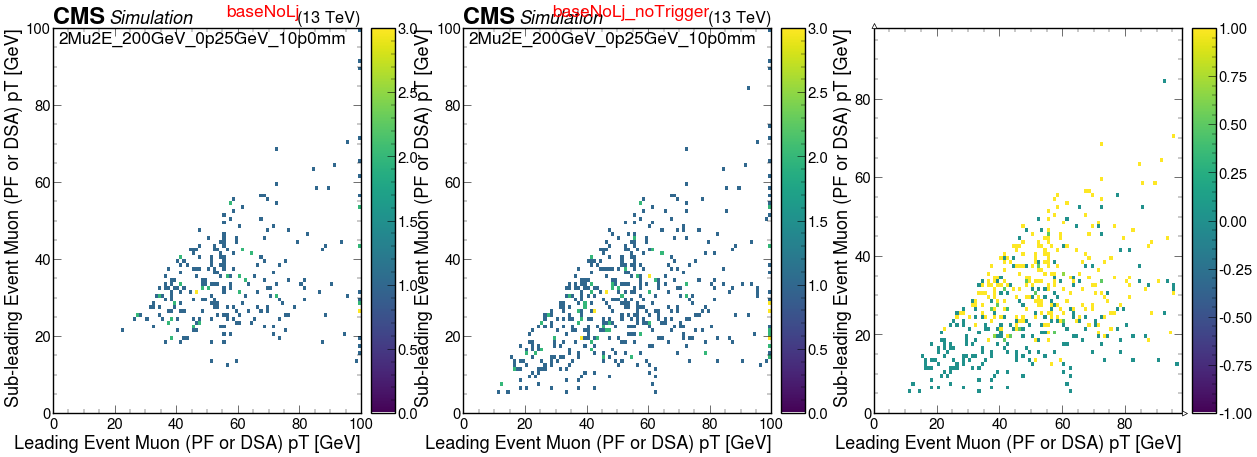

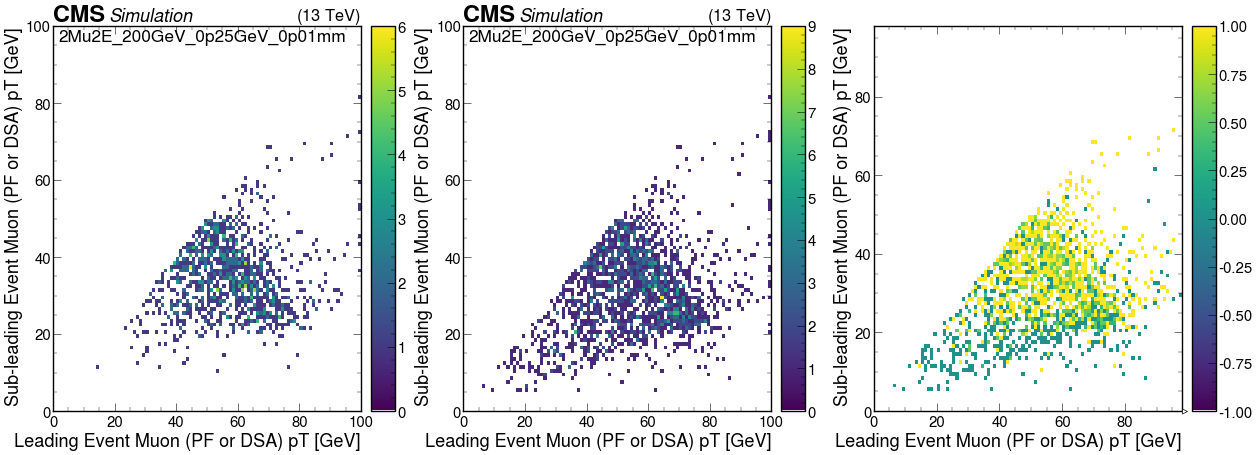

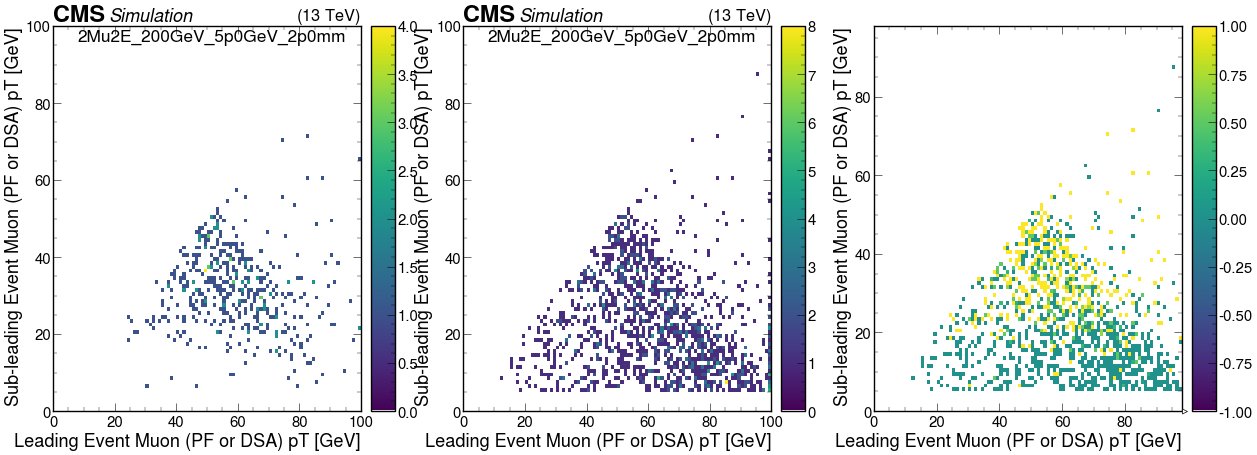

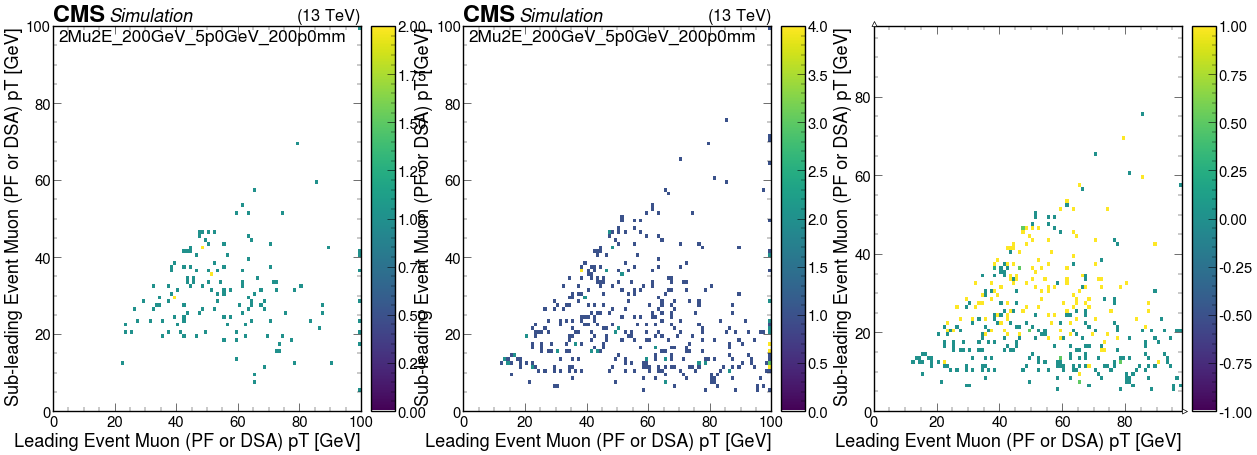

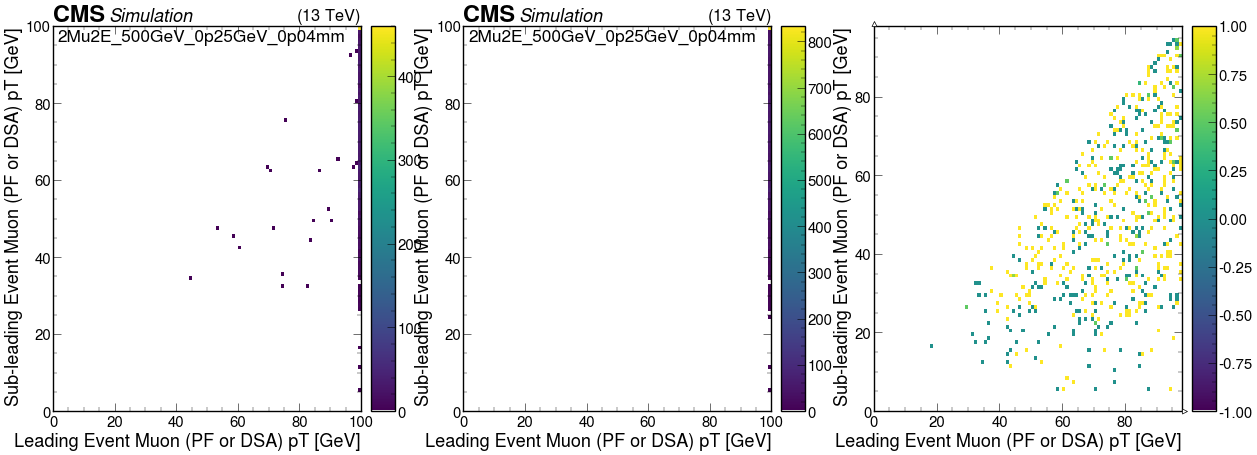

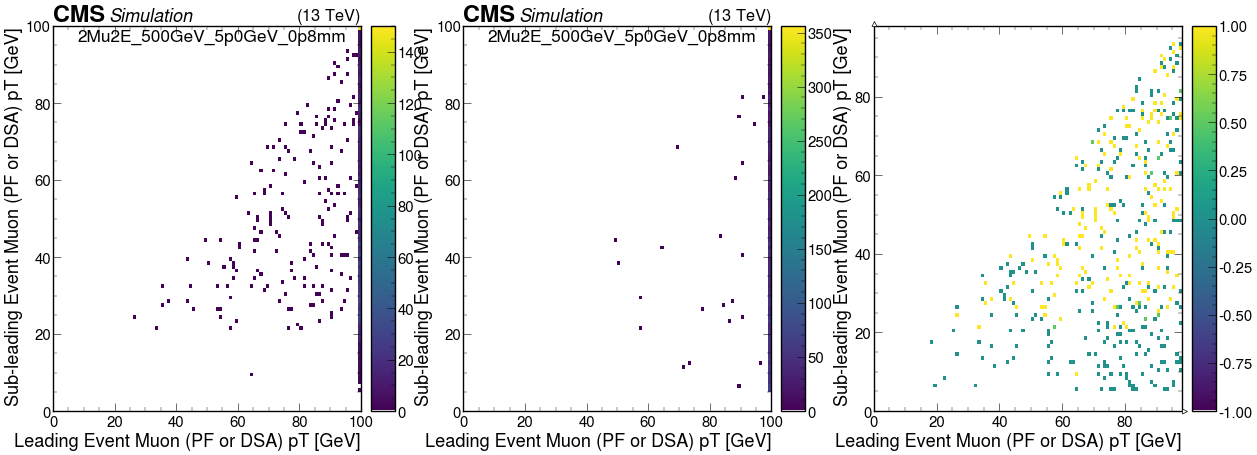

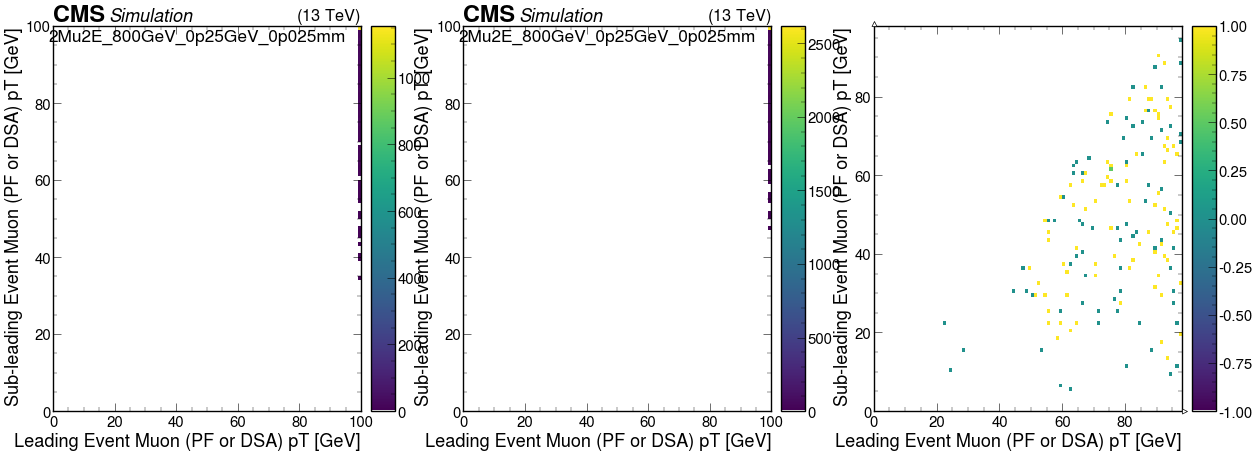

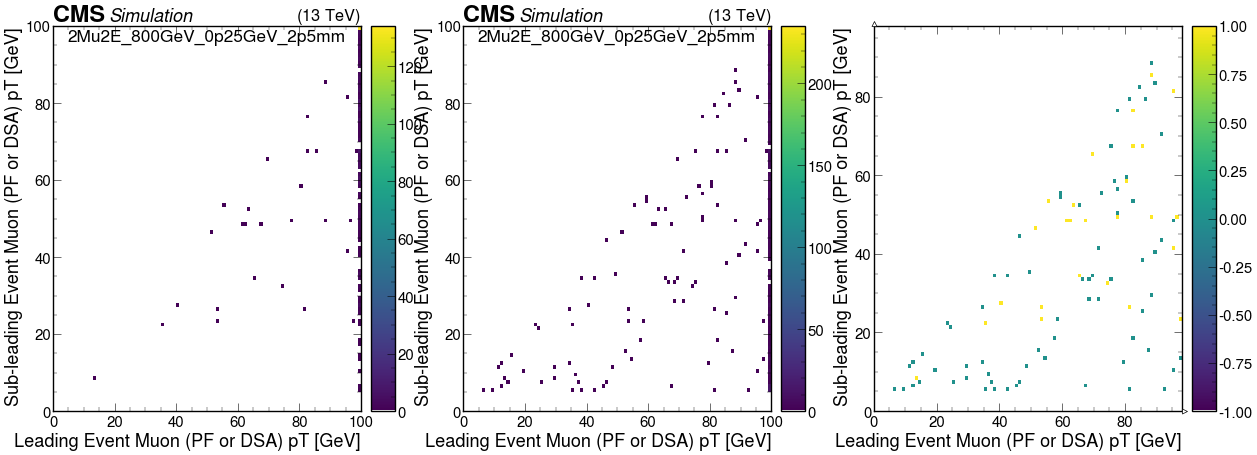

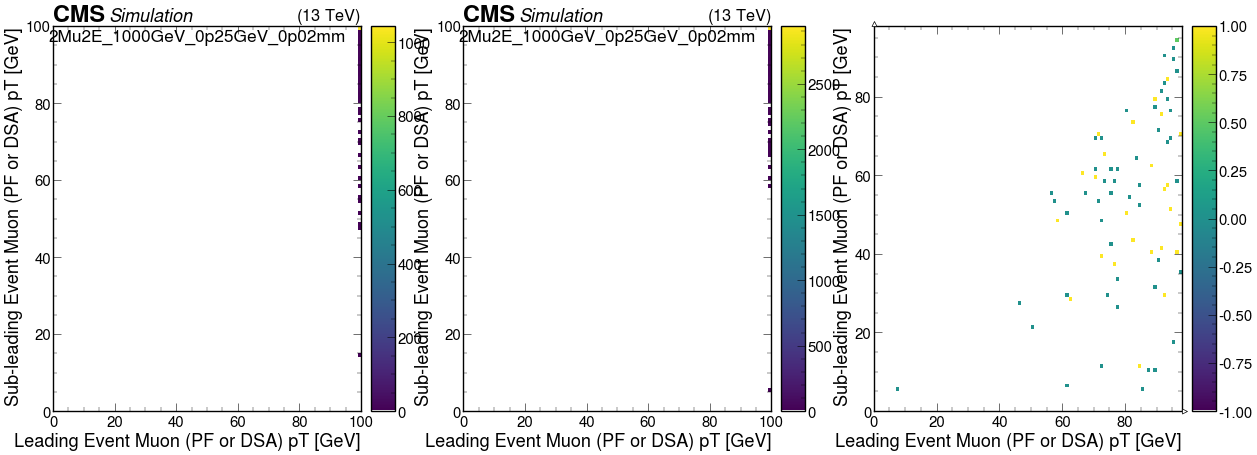

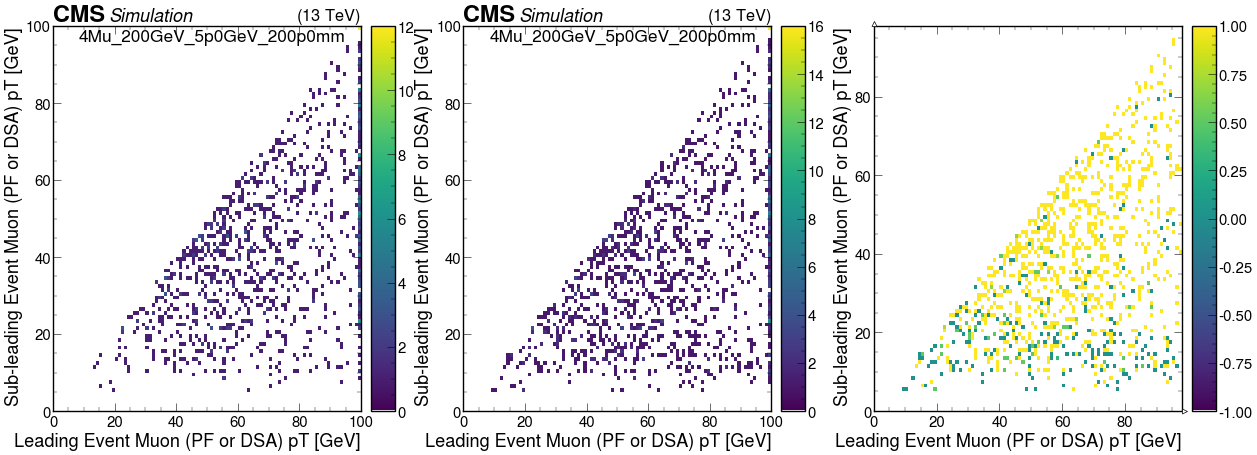

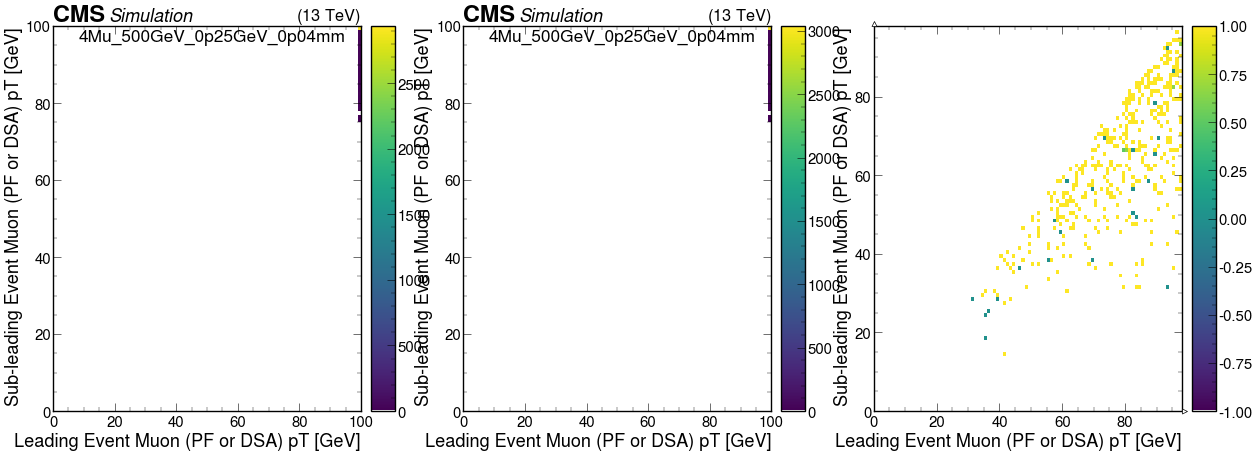

In [5]:
#Define custom color map
base_cmap = plt.get_cmap("viridis")
cmap_colors = base_cmap(np.linspace(0, 1, 256))

# Force the very bottom of the scale to pure white (RGBA)
cmap_colors[0] = [1.0, 1.0, 1.0, 1.0]
custom_cmap = mcolors.ListedColormap(cmap_colors)

#Define grid
ns = len(samples)
nc = 2 #len(channels)

first = True

num_ch = channels[0]
denom_ch = channels[1]

plot_name = "all_muon0_pt_vs_all_muon1_pt"

#Plot one row at a time (to avoid weird scaling effects)
for sample in samples:
    fig, axes = plt.subplots(1, nc+1, figsize=(nc * 15, 10)) 

    for i, ch in enumerate(channels):
        if i < nc:
        #plt.subplot(1, nc+1, i+1)
        
        #utilities.plot(out[sample]["hists"][plot_name][ch, :,:],cmap=custom_cmap)

        #ax = axes[i]

            ax = axes[i]
            utilities.plot(out[sample]["hists"][plot_name][ch, :,:], cmap=custom_cmap, ax=ax)
    
            ax.text(0.95, 0.95, sample, 
                    transform=ax.transAxes, 
                    fontsize=25, 
                    color='black',
                    ha='right', 
                    va='bottom')
            if first:
                ax.text(0.8, 1.02, ch, 
                    transform=ax.transAxes, 
                    fontsize=25, 
                    color='red',
                    ha='right', 
                    va='bottom')
    #i=i+1
    #plt.subplot(1, nc+1, i+1)
    ax_ratio = axes[nc]

    num  =  out[sample]["hists"][plot_name][num_ch,   :,:]
    denom = out[sample]["hists"][plot_name][denom_ch, :,:]

    ratio = num.copy()
    ratio.view().value = np.divide(num.values(), denom.values(), out=-1*np.ones_like(num.values()), where=denom.values()!=0)
    ratio.view().value[ratio.values() > 1.0] = np.nan

    ratio.plot2d(cmap=custom_cmap, ax=ax_ratio)
    
    #ratio.plot2d(cmap=custom_cmap)
    #utilities.plot(ratio,cmap=custom_cmap)
    #ax = plt.gca()
    ax_ratio.set_xlim([0,98])
    ax_ratio.set_ylim([0,98])

    first = False
        
    plt.show()

Okay... so far, these plots are telling me that we hit the plateau of the trigger efficiency when the sub-leading muon pt is about 25 GeV. It doesn't seem to depend too heavily on the leading event muon pt. I should run these again to zoom in on the 20-30 GeV region to make a more specific pt threshold recommendation. 

## 1D plots

Now let's look at the 1D efficiency vs leading or sub-leading muon pt. 

In [6]:
#Define a function to plot a row of ratio plots
def plot_ratio_row(nums, dens, sample,**kwargs):
    """
    Plots n ratio plots in a single row.
    nums: list of numerators (each can be a hist or a list of hists)
    dens: list of denominators (hists)
    """
    n = len(dens)
    
    # Lower-panel label/limits default to the efficiency convention but can be
    # overridden for a generic ratio; popped so they do not reach hep.histplot.
    ratio_ylabel = kwargs.pop("ratio_ylabel", "Efficiency")
    ratio_ylim = kwargs.pop("ratio_ylim", (0, 1.2))
    
    # squeeze=False guarantees axes is always shape (2, n)
    # sharex='col' shares the x-axis vertically but not horizontally
    fig, axes = plt.subplots(
        2, n, figsize=(12 * n, 18), sharex='col',
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0},
        squeeze=False
    )

    for i in range(n):
        ax1 = axes[0, i]
        ax2 = axes[1, i]
        
        den = dens[i]
        num = nums[i]
        
        plt.sca(ax1)
        sam = sample
        
        # Handle kwargs that might be passed as lists (one for each column)
        label = None
        if "legend" in kwargs:
            label = kwargs["legend"][i] if isinstance(kwargs["legend"], list) else kwargs["legend"][0]

        utilities.plot(den, flow='none', color="k", skip_label=True, label=label)

        if not isinstance(num, list):
            num = [num]

        for x in num:
            utilities.plot(x, flow='none', label=label)

        if "legend" in kwargs:
            title = kwargs["text"][i] if "text" in kwargs and isinstance(kwargs["text"], list) else kwargs.get("text")
            ax1.legend(title=title, alignment="left")

        if "ylim" in kwargs:
            ax1.set_ylim(kwargs["ylim"])

        if i ==0:
            ax1.text(95, 25, sam, 
#                transform=ax.transAxes, 
                fontsize=25, 
                color='black',
                ha='right', 
                va='bottom')
            
        # Only draw the y-axis label on the leftmost plot to keep the row clean
        if "ylabel" in kwargs and i == 0:
            ax1.set_ylabel(kwargs["ylabel"])


        plt.sca(ax2)
        for x in num:
            try:
                eff, errors = utilities.get_eff_hist(x, den)
            except ValueError:
                # num is not a subset of den (a shape ratio, not an efficiency): the
                # binomial Clopper-Pearson interval is invalid and ratio_uncertainty
                # raises -- fall back to a Gaussian-propagated ratio.
                eff, errors = _gaussian_ratio(x, den)
            utilities.plot(eff, histtype='errorbar', yerr=errors, skip_label=True)

        # Only draw the ratio y-axis label on the leftmost plot
        if i == 0:
            ax2.set_ylabel(ratio_ylabel)
            
        if ratio_ylim is not None:
            ax2.set_ylim(*ratio_ylim)

        if "xlabel" in kwargs:
            # Handle if they pass a list of xlabels (one per column) or just one string
            xlabel = kwargs["xlabel"][i] if isinstance(kwargs["xlabel"], list) else kwargs["xlabel"]
            ax2.set_xlabel(xlabel)

    plt.tight_layout()
    return fig, axes

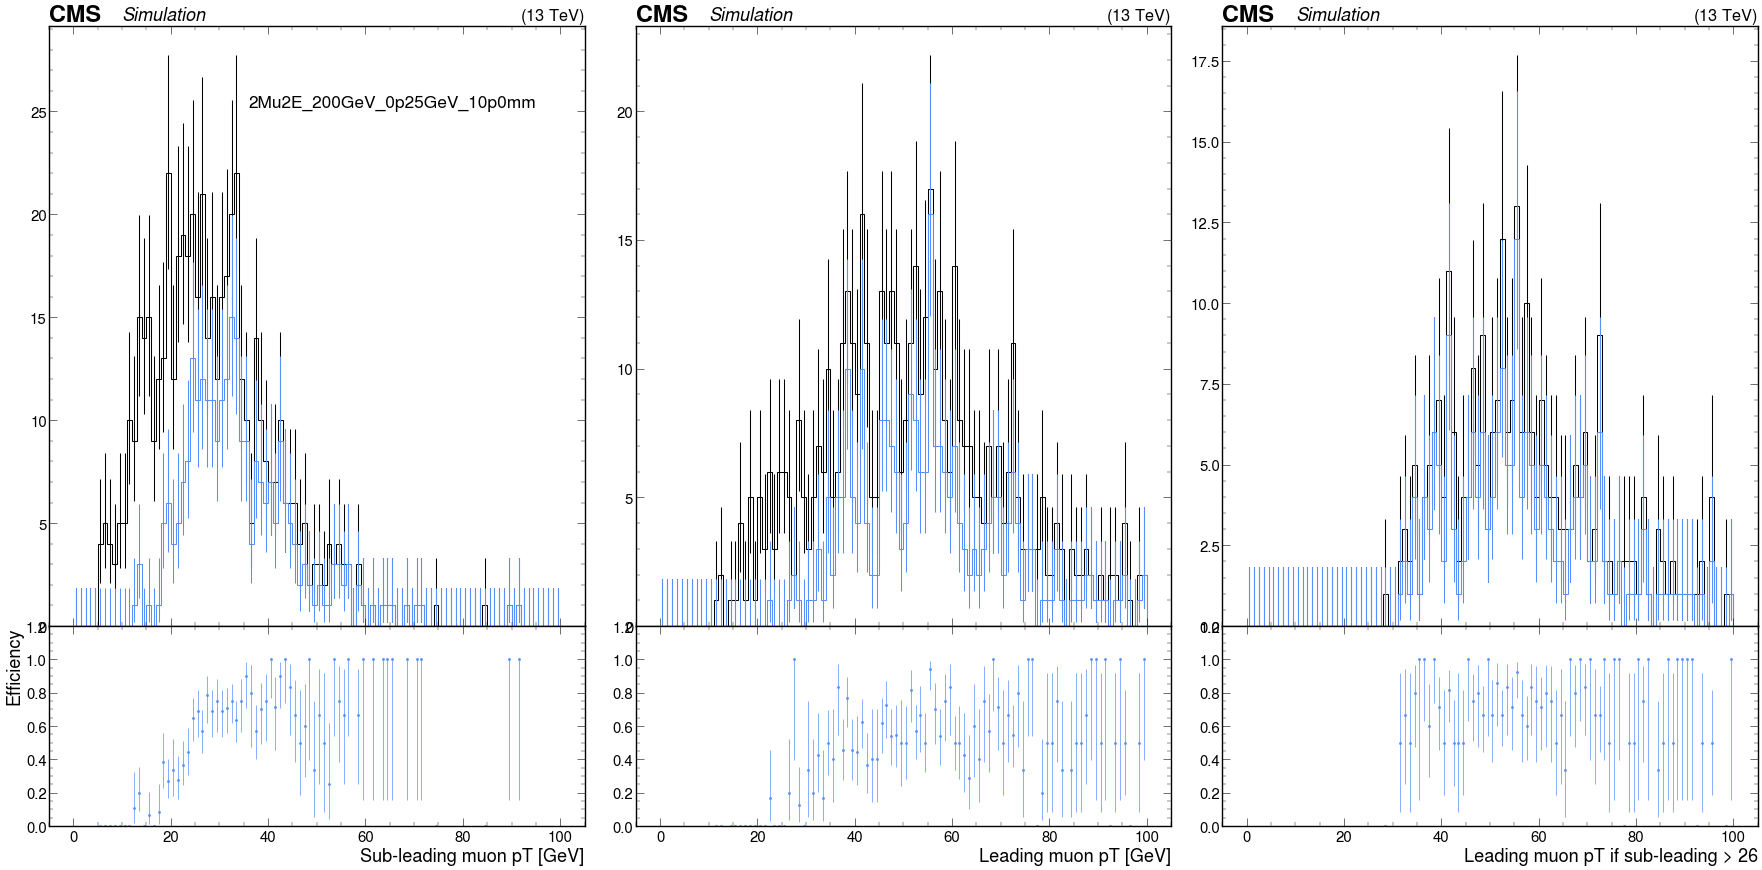

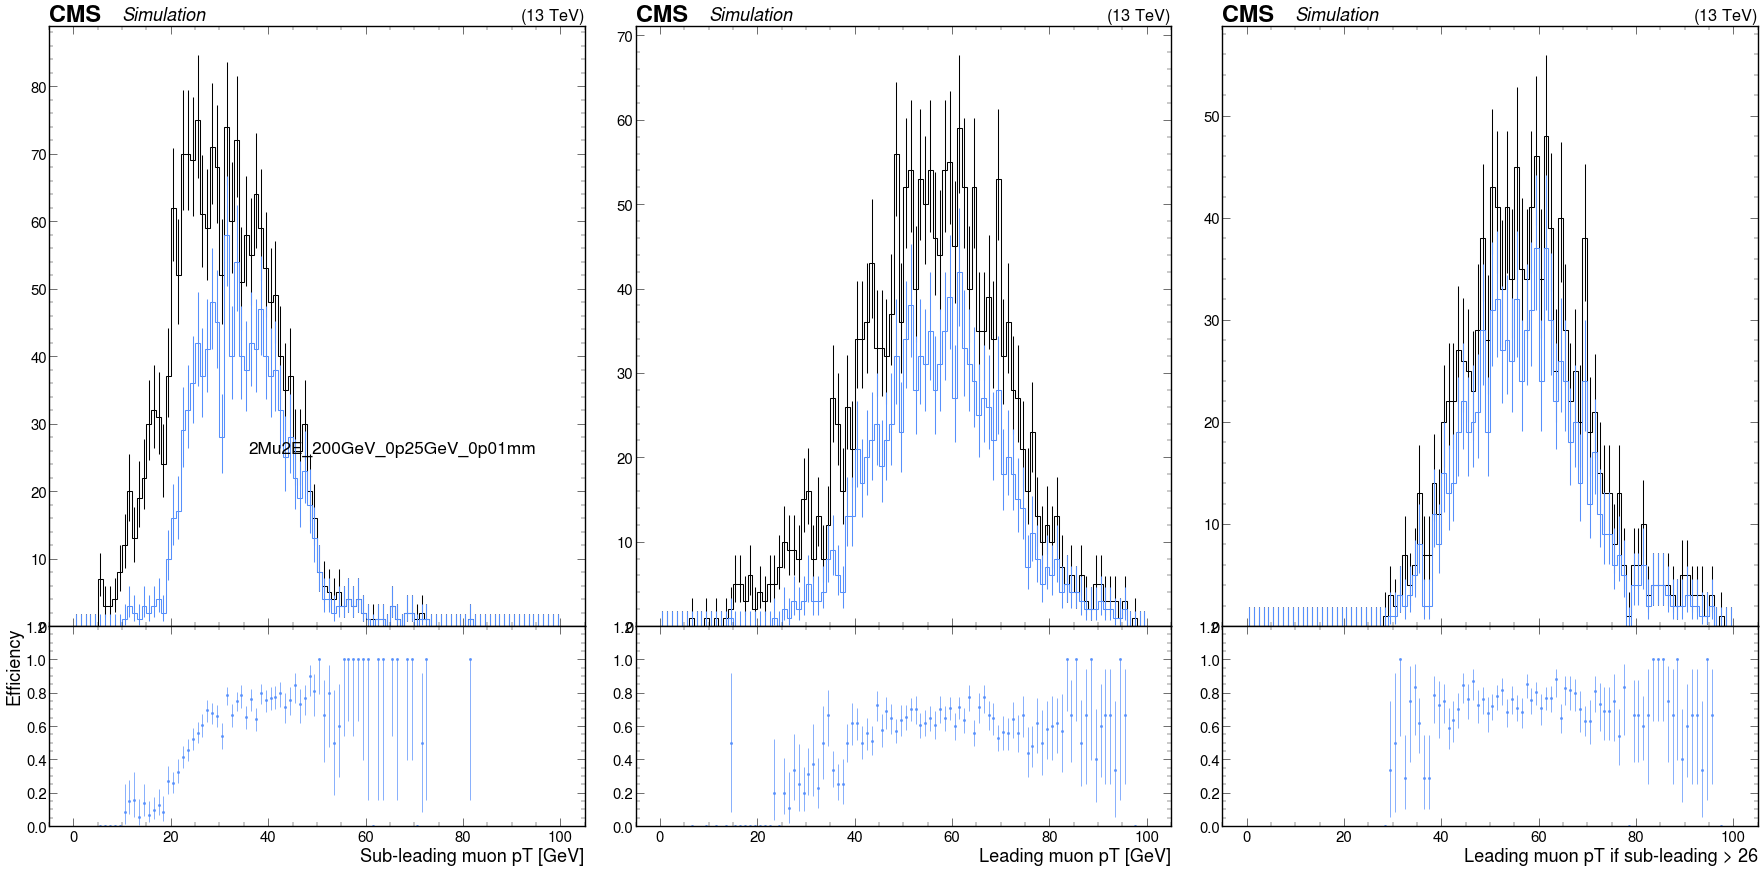

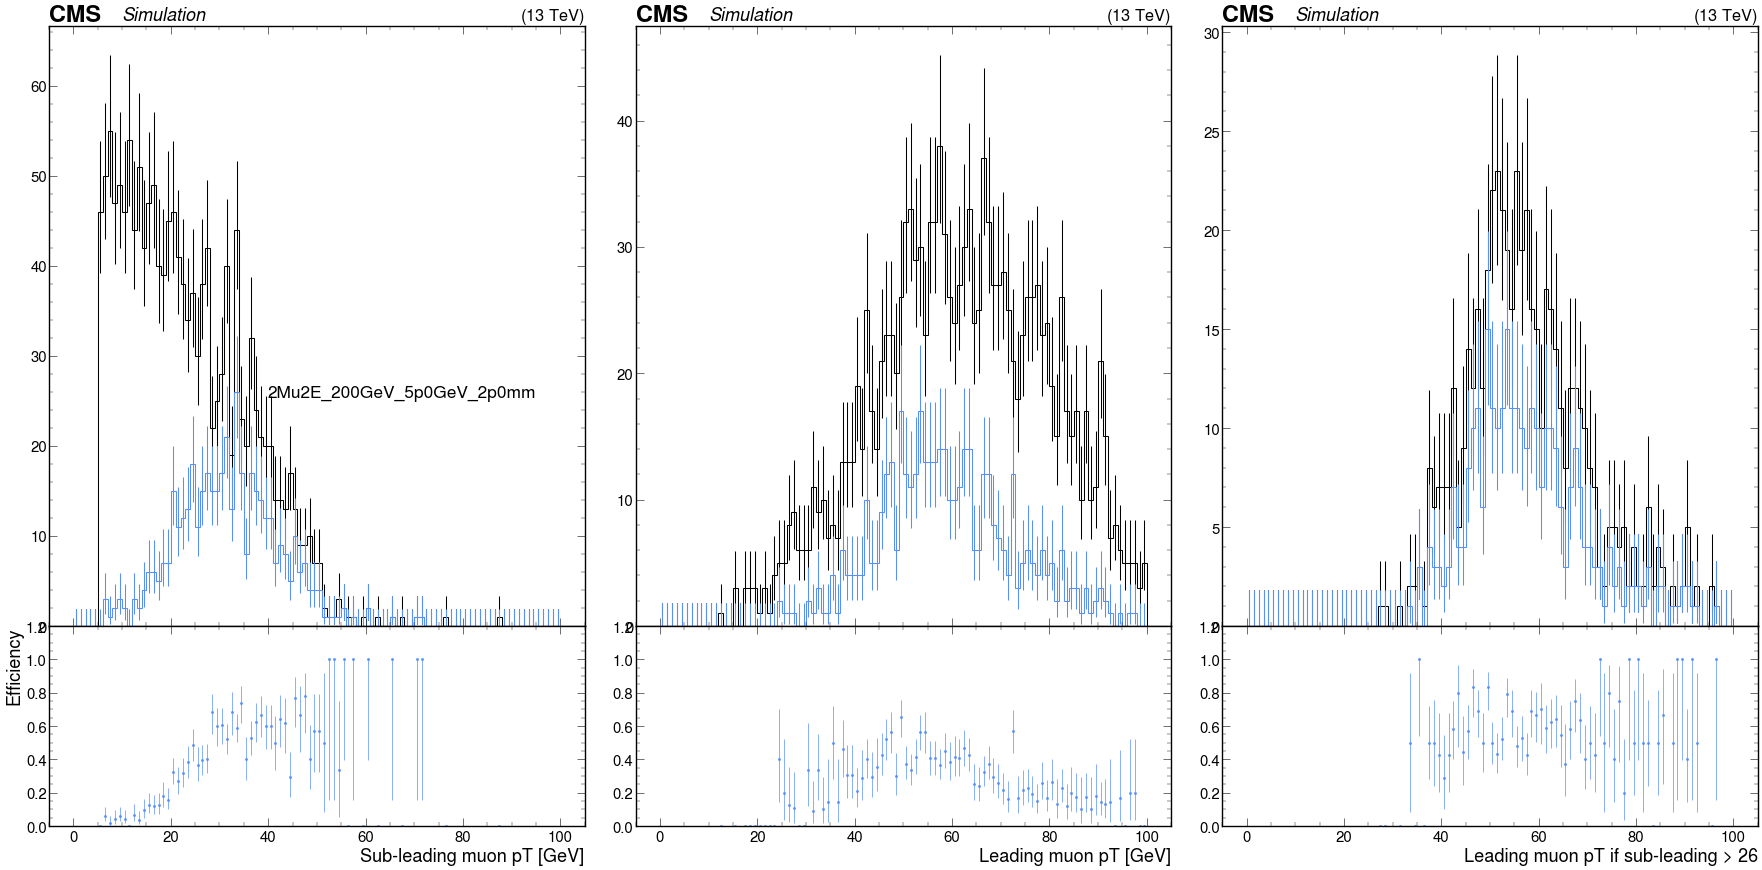

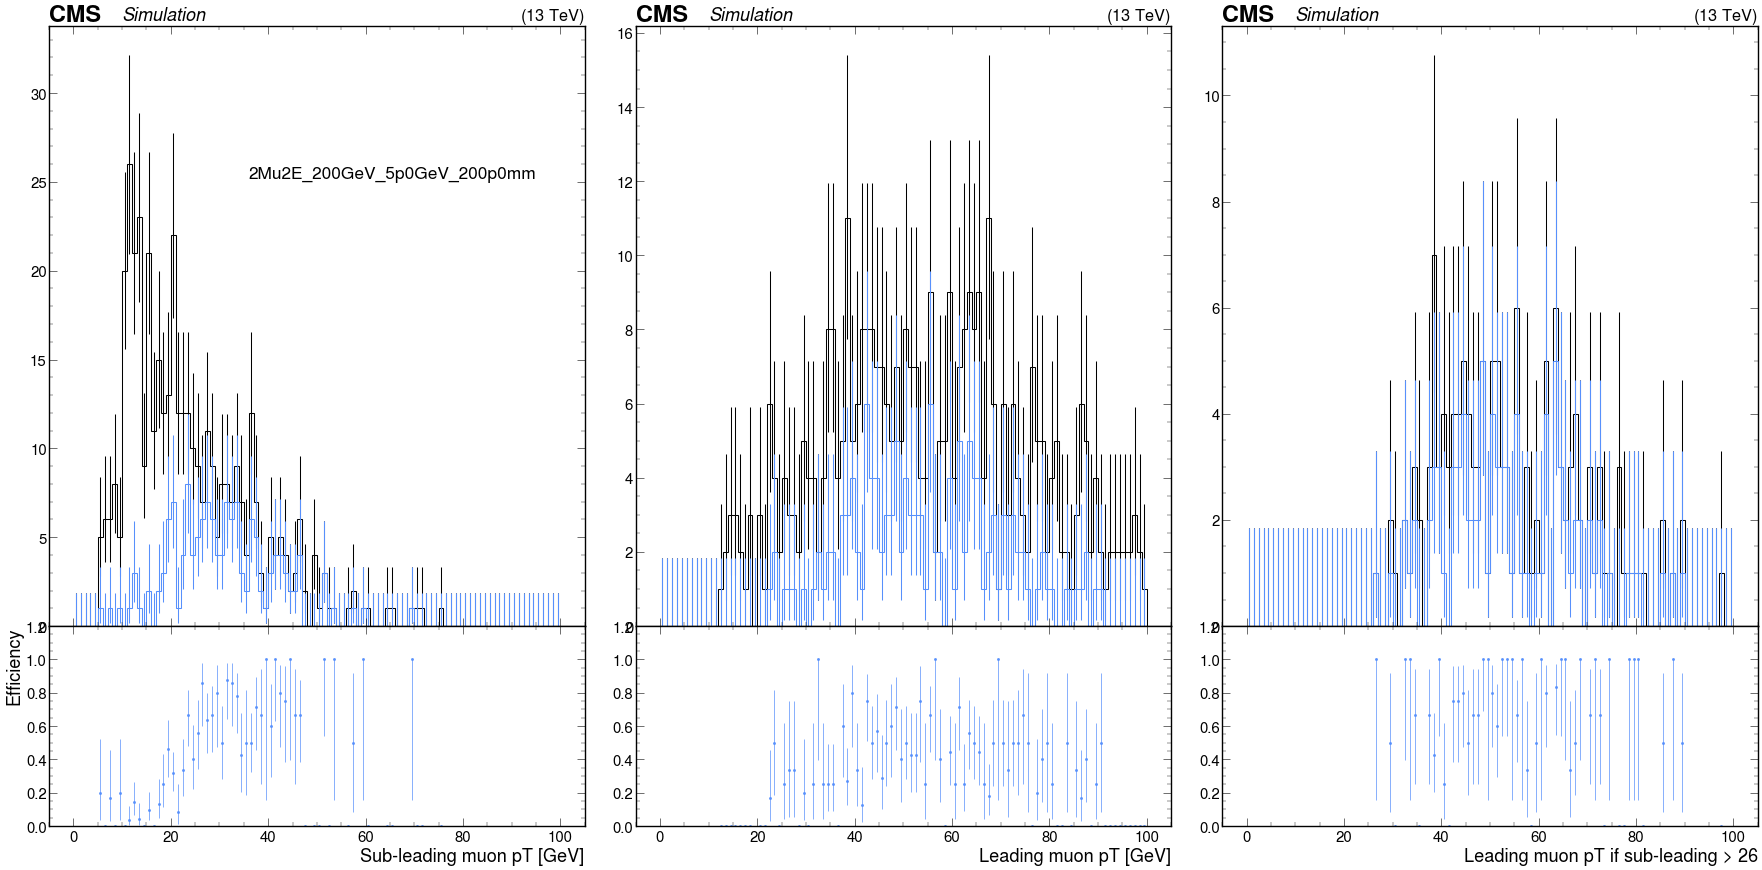

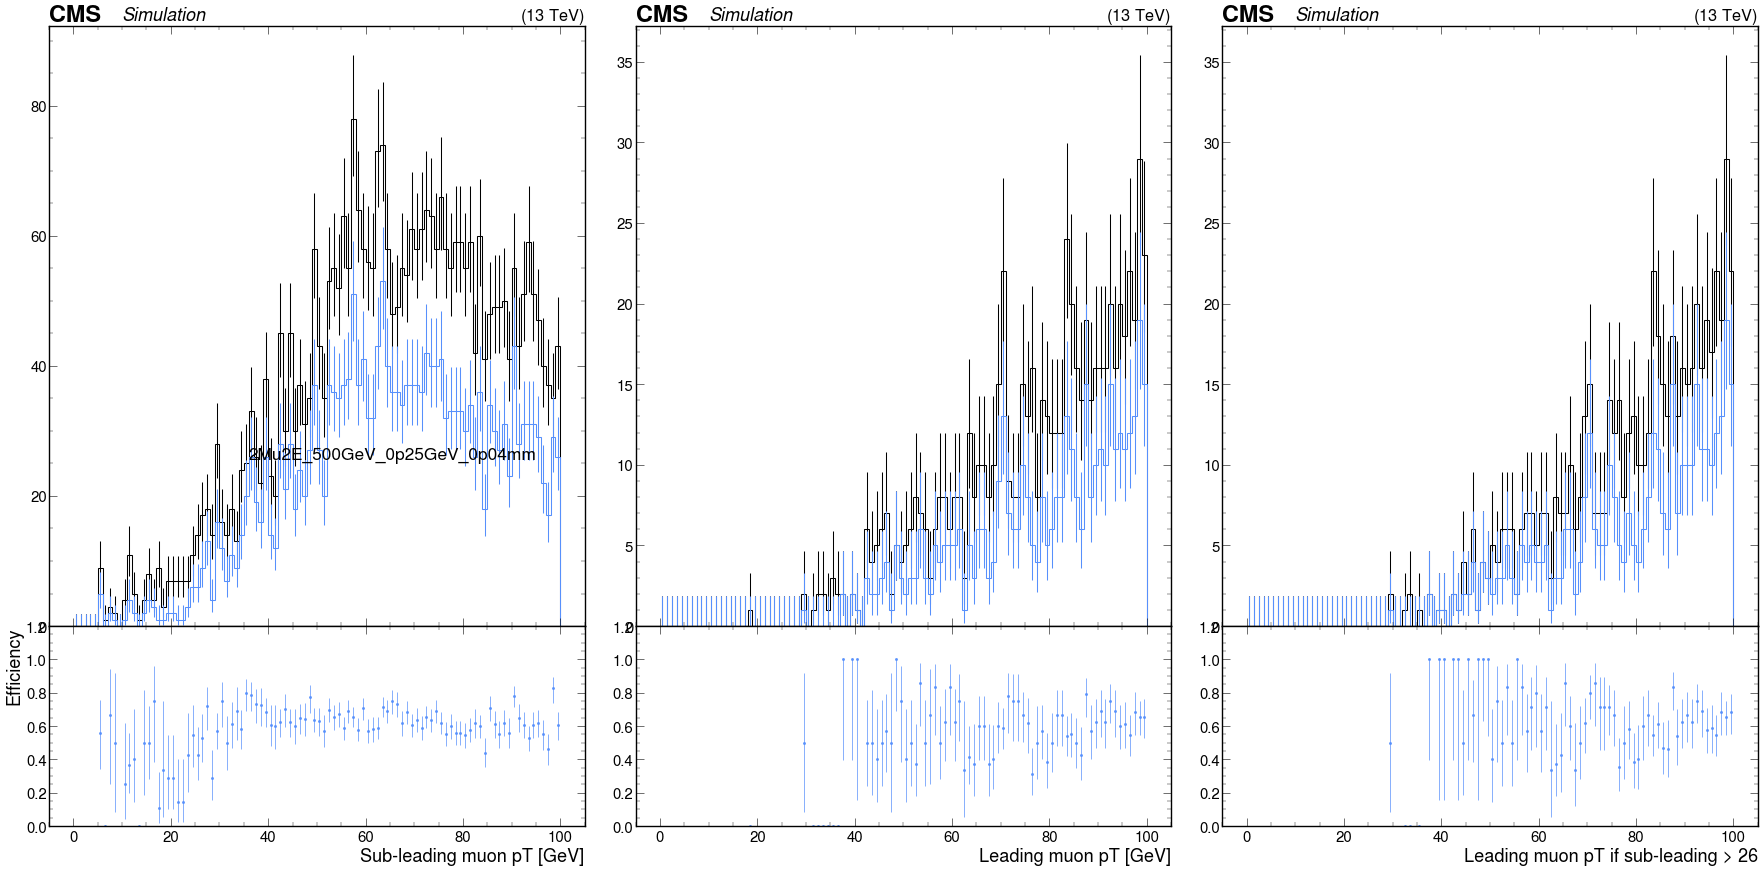

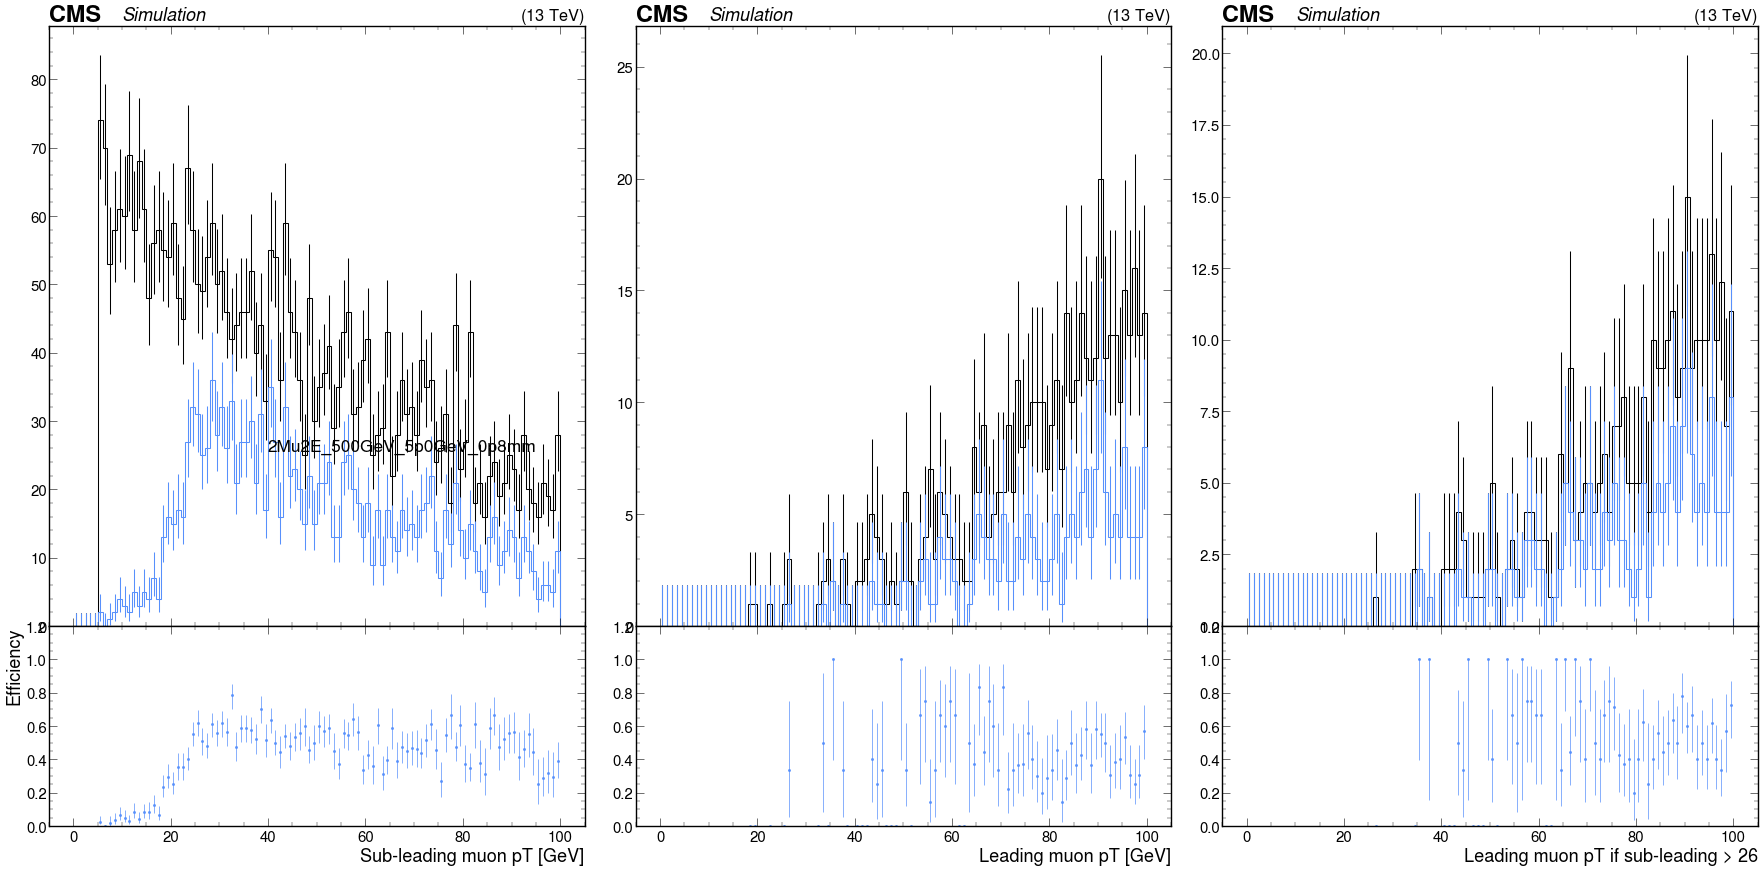

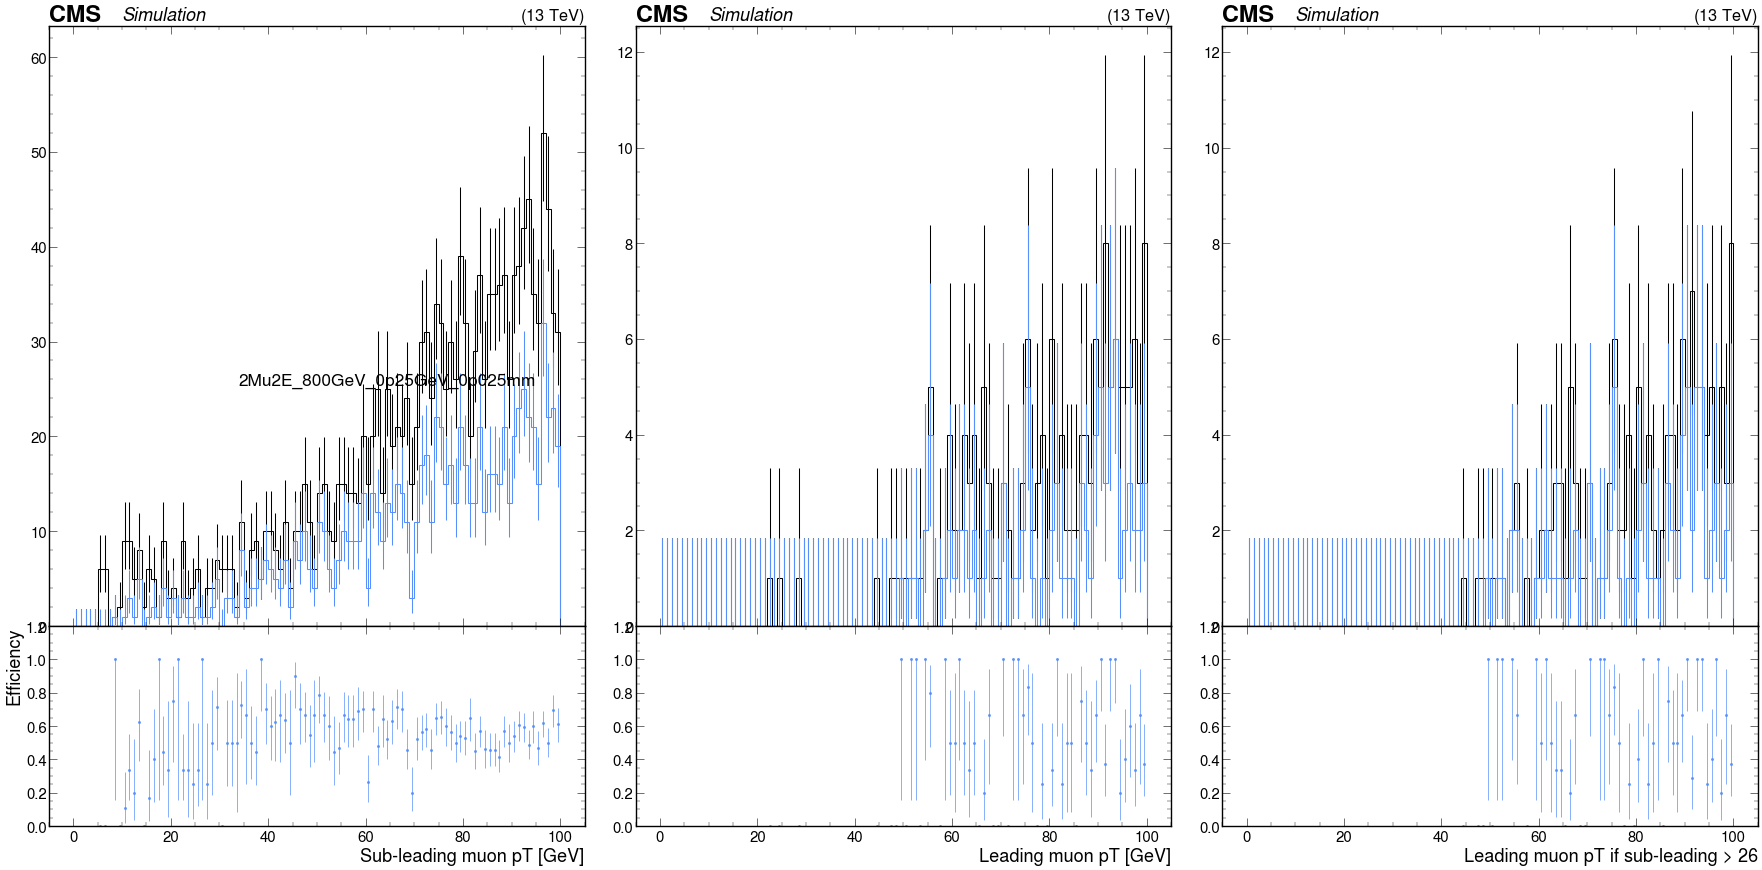

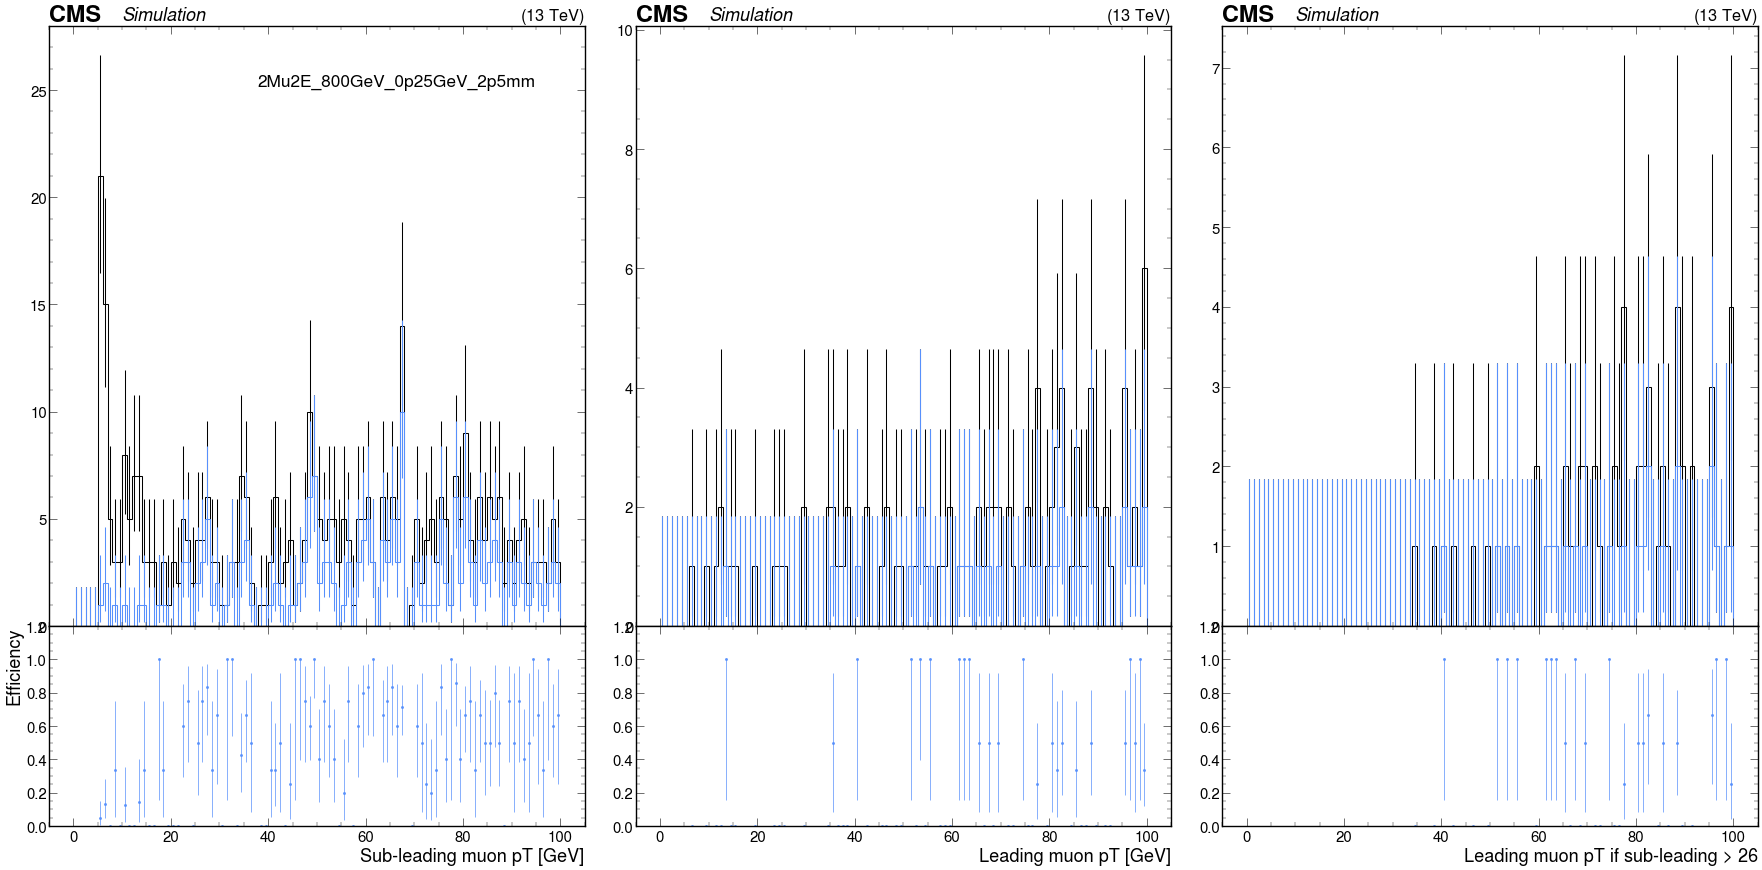

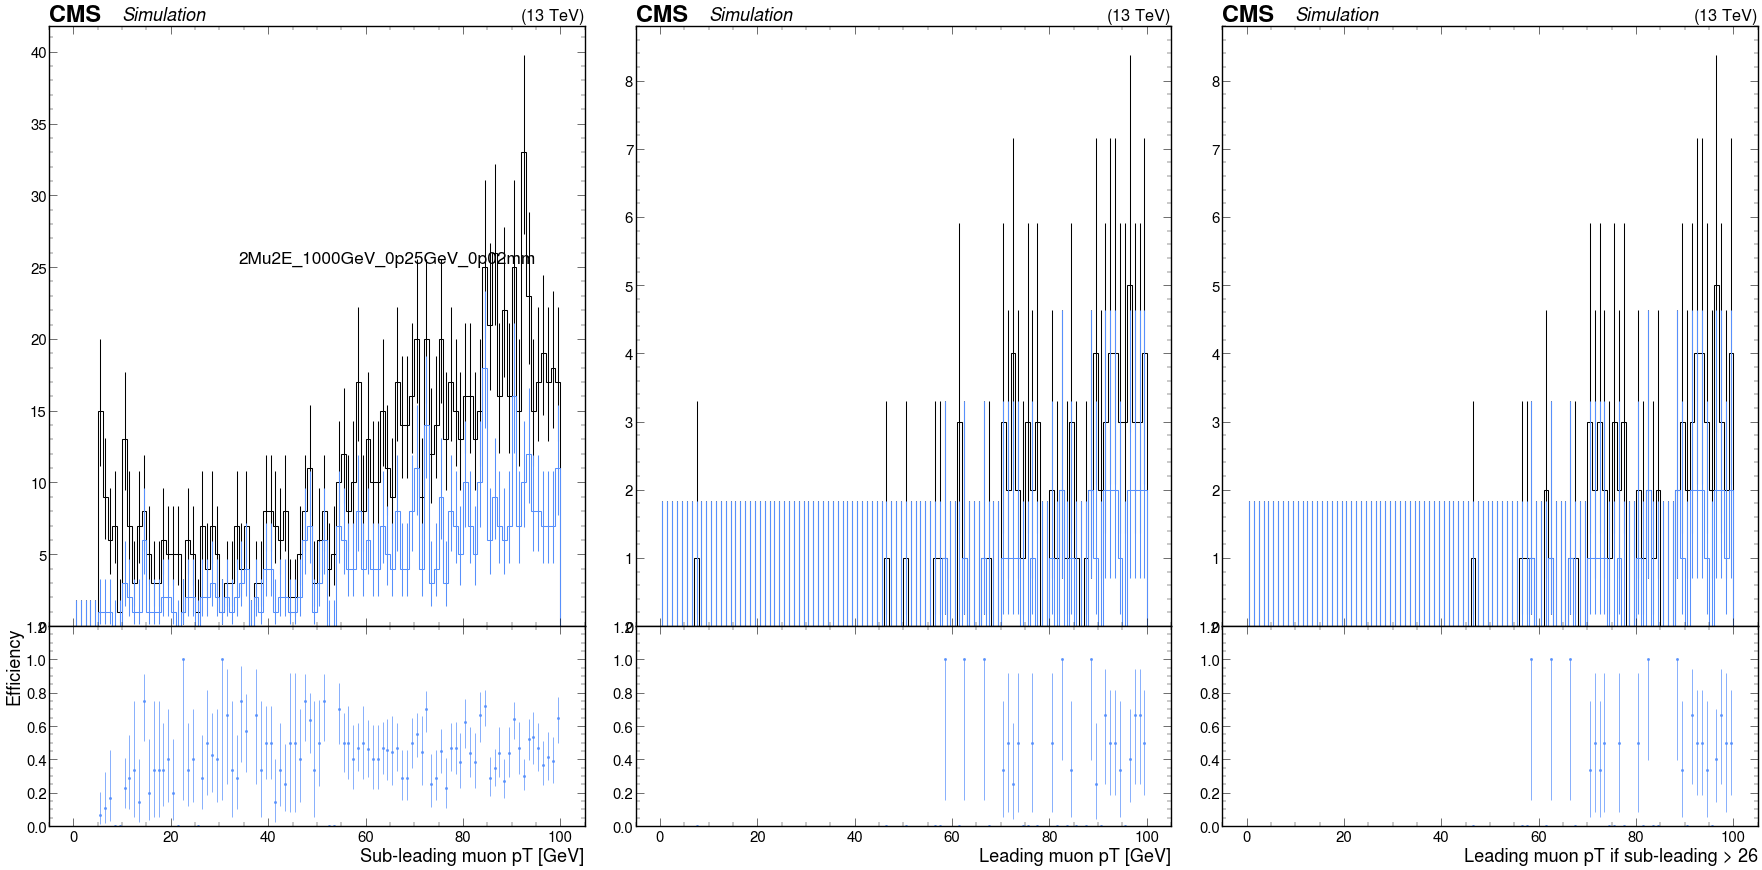

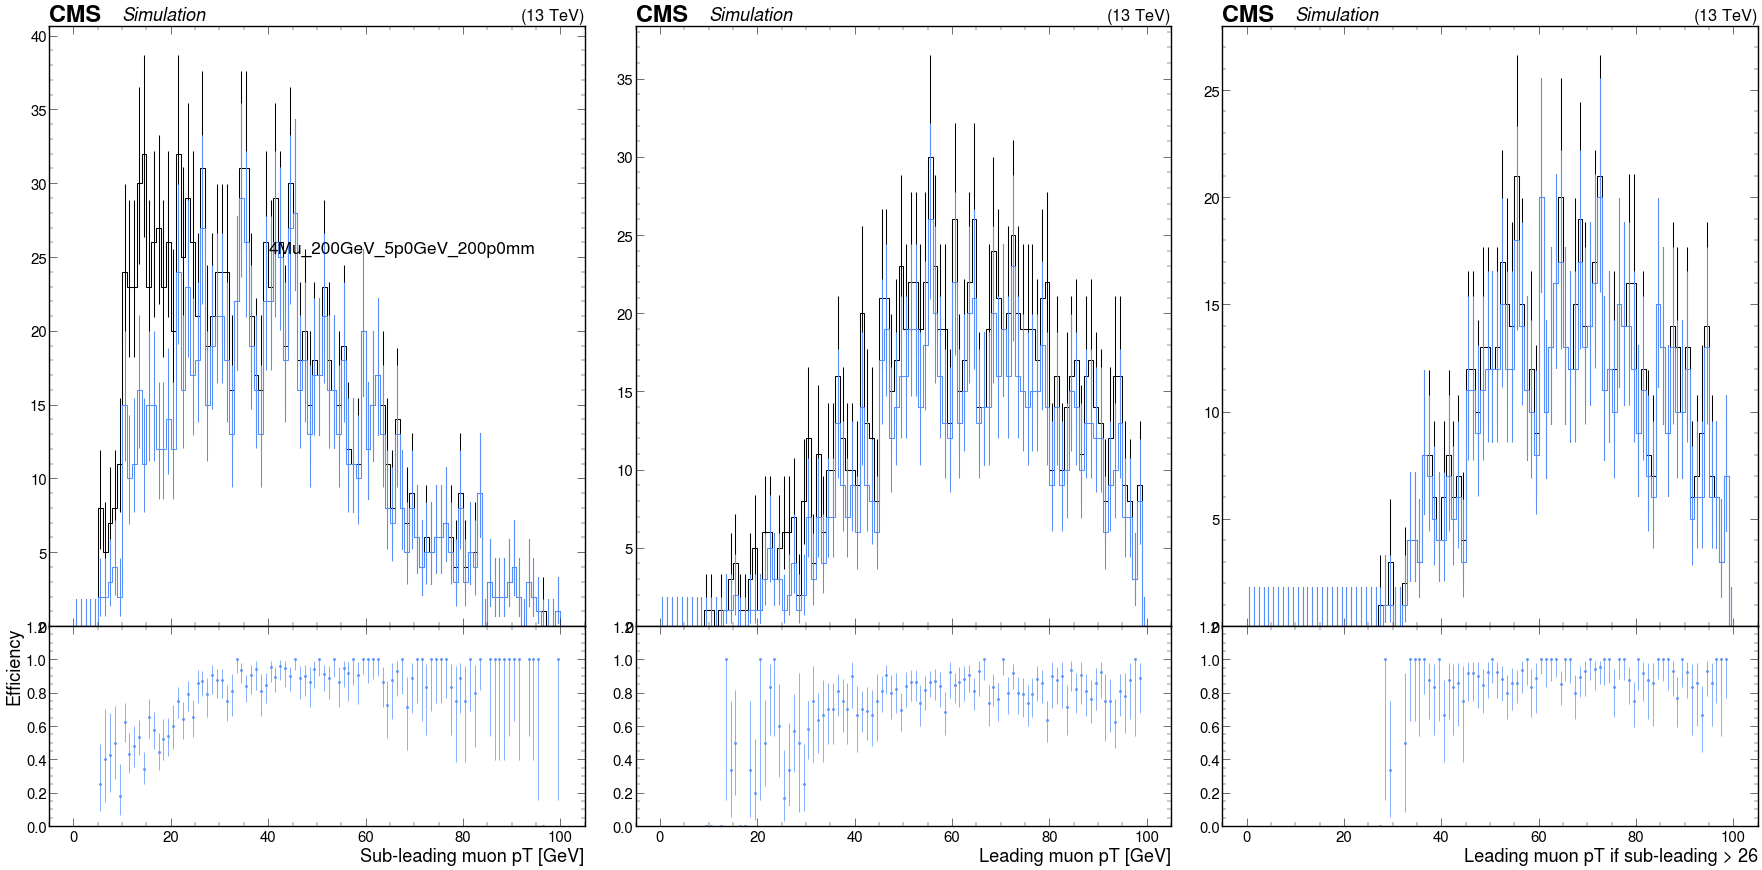

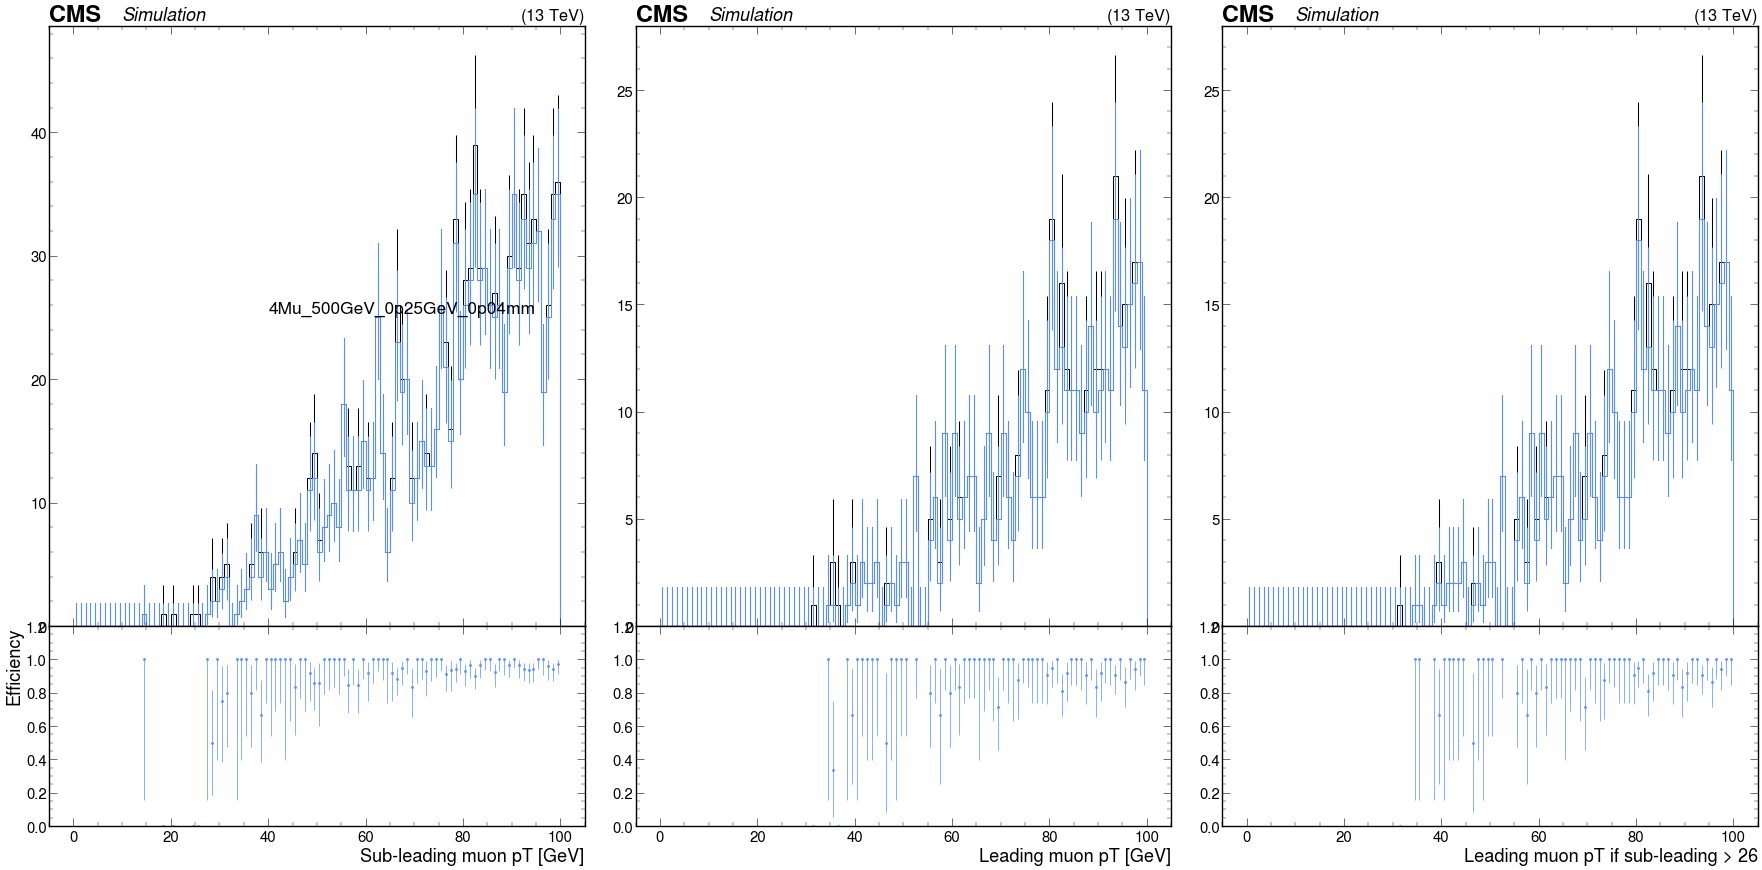

In [7]:
pt_cut = 26
maxpt=40
for sample in samples:
    nums = [out[sample]["hists"][plot_name][ num_ch, sum,:],
            #out[sample]["hists"][plot_name][ num_ch, sum,:hist.loc(maxpt)]
            out[sample]["hists"][plot_name][ num_ch, :,sum], 
            out[sample]["hists"][plot_name][ num_ch, :,hist.loc(pt_cut)::sum]]
    denoms = [out[sample]["hists"][plot_name][denom_ch, sum,:],
              #out[sample]["hists"][plot_name][denom_ch, sum,:hist.loc(maxpt)]
              out[sample]["hists"][plot_name][denom_ch, :,sum],
              out[sample]["hists"][plot_name][ denom_ch, :,hist.loc(pt_cut)::sum]]
    plot_ratio_row(nums,denoms,sample,xlabel=["Sub-leading muon pT [GeV]","Leading muon pT [GeV]",f"Leading muon pT if sub-leading > {pt_cut}"])


From the first plot: the overall efficiency (plateau value) is different for each sample, but they each seem to hit the plateau when the sub-leading muon is approximately 25 GeV. 

From the second plot: these plots are inclusive of sub-leading muon pt. There's not a clean turn on curve or an obvious cut-off for leading muon pt here

From the third plot: Now I am plotting the trigger efficiency vs leading muon pt only in events where the sub-leading muon pt passes our pt cut (26 GeV). By my eye, those distributions are pretty flat. I think just a cut on the sub-leading muon pt is enough to put us in the plateau of the trigger efficiency. I don't think we need an additional cut on the leading muon pt (which by definition will be higher than 26 or whatever anyway)

This will have a different effect on the two samples... for the 2mu2e sample, we are requiring that *both* of the muons from a single dark photon are above 26 GeV. For the 4Mu sample, we are requiring that either A) *both* of the muons from a single dark photon are above 26 GeV or B) each dark photon produces at least one muon with pt > 26 GeV. The next step will be to figure out how to apply this event-level cut in our framework.

Or... if there aren't many cases of scenario A, then the cut could be
- For 2mu2e, require two muons in one LJ with pt > 26
- For 4mu, require each LJ to have at least one muon with pt > 26

That brings it to a LJ level requirement instead.

I'm also curious how this effects the separate LJ pt > 30 GeV cut that we have. That might not be needed at all for muon LJs now

### Zoomed in 1D to make official pt decision

2Mu2E_200GeV_0p25GeV_10p0mm
2Mu2E_200GeV_0p25GeV_0p01mm
2Mu2E_200GeV_5p0GeV_2p0mm
2Mu2E_200GeV_5p0GeV_200p0mm
2Mu2E_500GeV_0p25GeV_0p04mm
2Mu2E_500GeV_5p0GeV_0p8mm
2Mu2E_800GeV_0p25GeV_0p025mm
2Mu2E_800GeV_0p25GeV_2p5mm
2Mu2E_1000GeV_0p25GeV_0p02mm
4Mu_200GeV_5p0GeV_200p0mm
4Mu_500GeV_0p25GeV_0p04mm


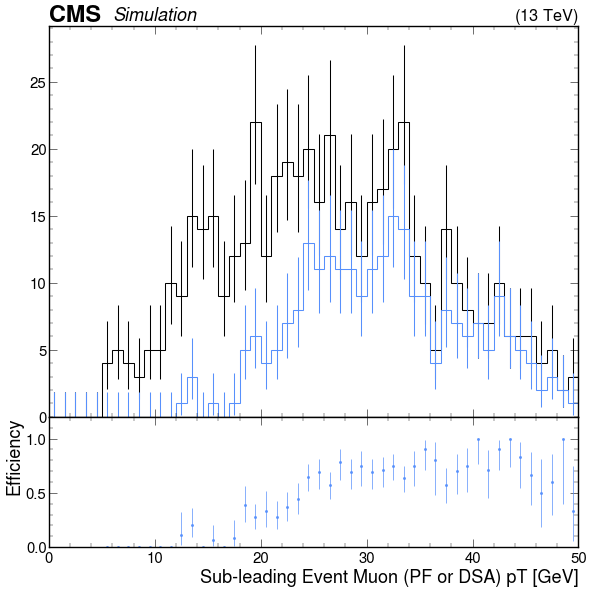

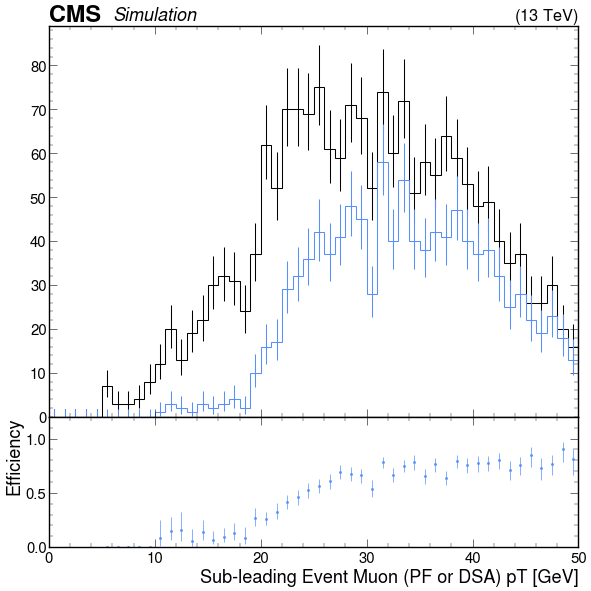

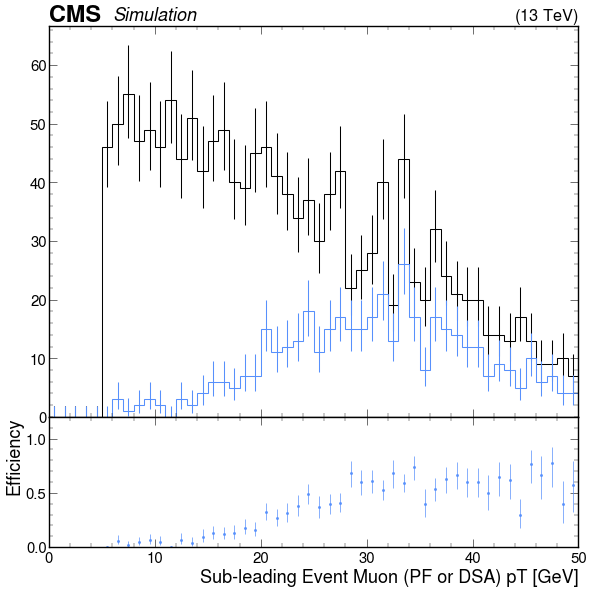

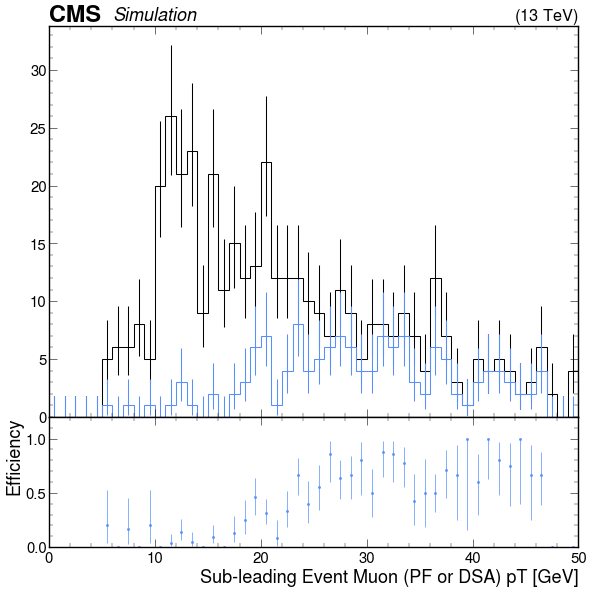

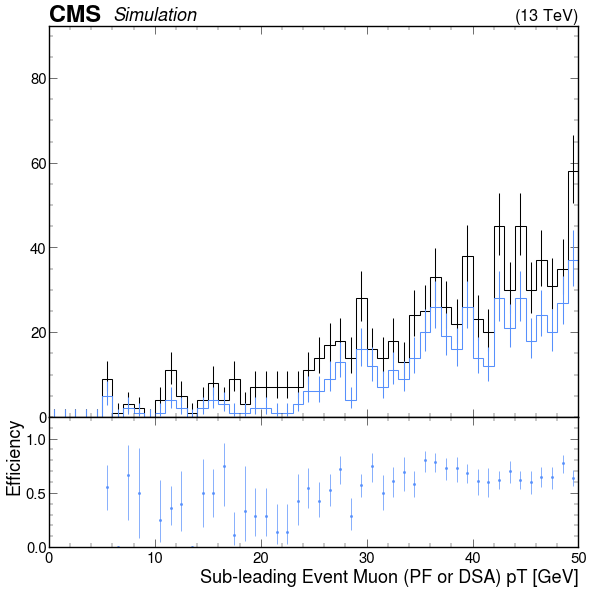

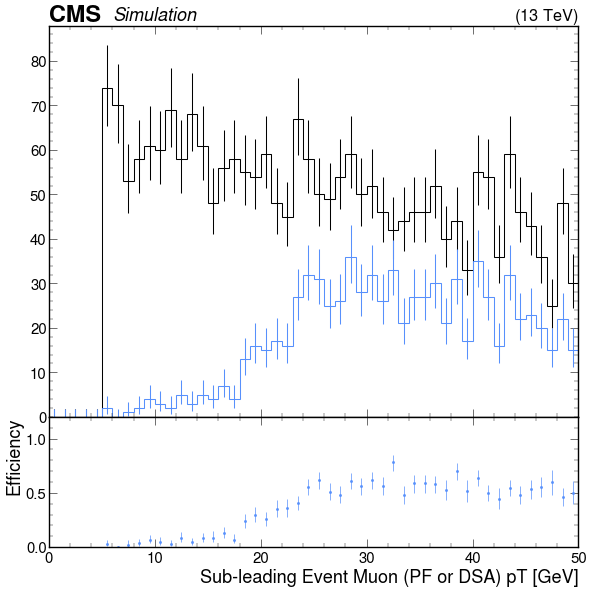

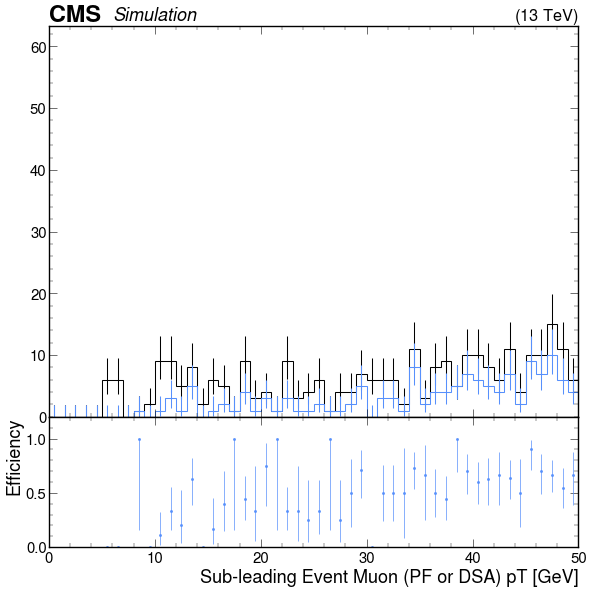

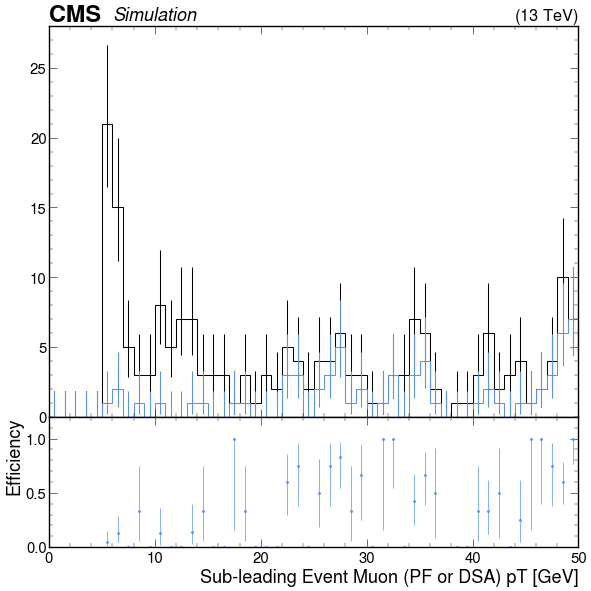

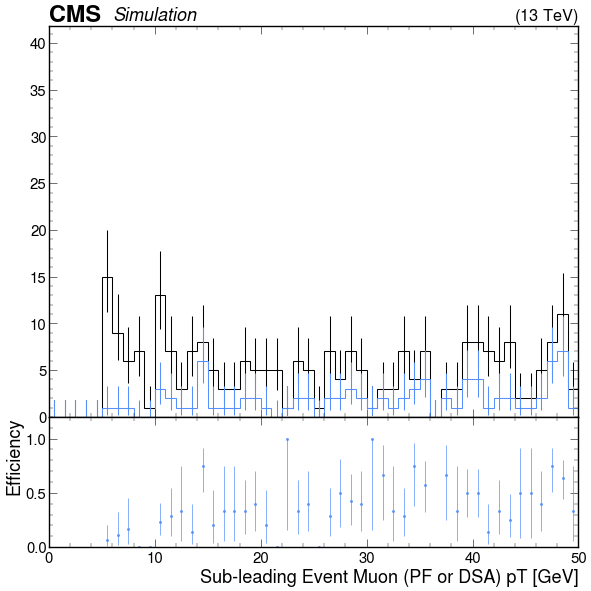

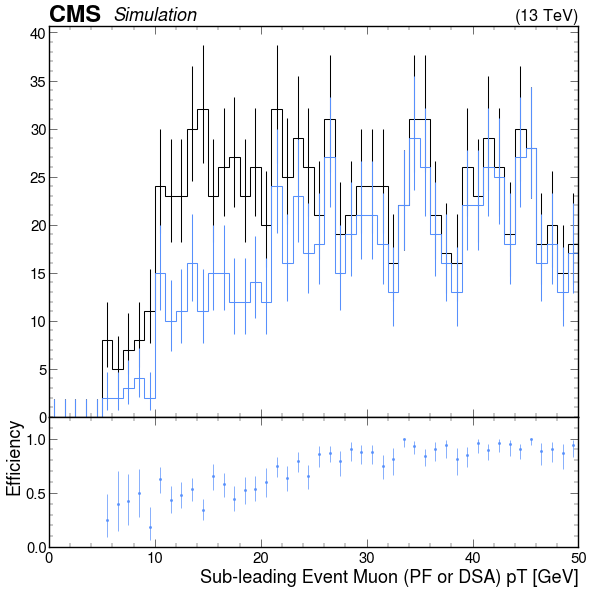

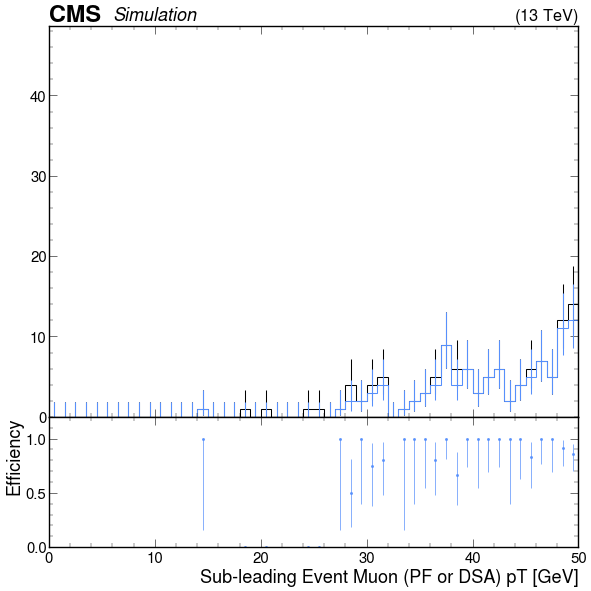

In [8]:
max_pt = 50
num_ch = channels[0]
denom_ch = channels[1]

plot_name = "all_muon0_pt_vs_all_muon1_pt"

for sample in samples:
    print(sample)
    utilities.plot_ratio(out[sample]["hists"][plot_name][ num_ch, sum,:], 
                     out[sample]["hists"][plot_name][denom_ch, sum,:],xlim=(0,max_pt))

Next steps:
- define a selection with an event level cut for two muons with pt > 26 GeV
- quantify scenario A vs scenario B in these samples
- investigate if lepton jet pt cut is needed for muons
  
Completed:
- more samples, particularly those with higher energy and making sure I'm covering a range of delta R and displacement values

Chose not to do:
- redefine these plots using the common muon collection, make sure we get the same results (didn't do this because the joint muon collection only exists within lepton jets, and I'm doing this study without considering LJ reco)

# Sanity checks
After applying the new cut for two muons with pt > 26 Gev. The channel base does not include the cut, but the channel base_muPtcut does. 

First check that the cut was applied and check the effect on lepton jet pt:

/tmp/ipykernel_3113/3524104532.py:89: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_3113/3524104532.py:89: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


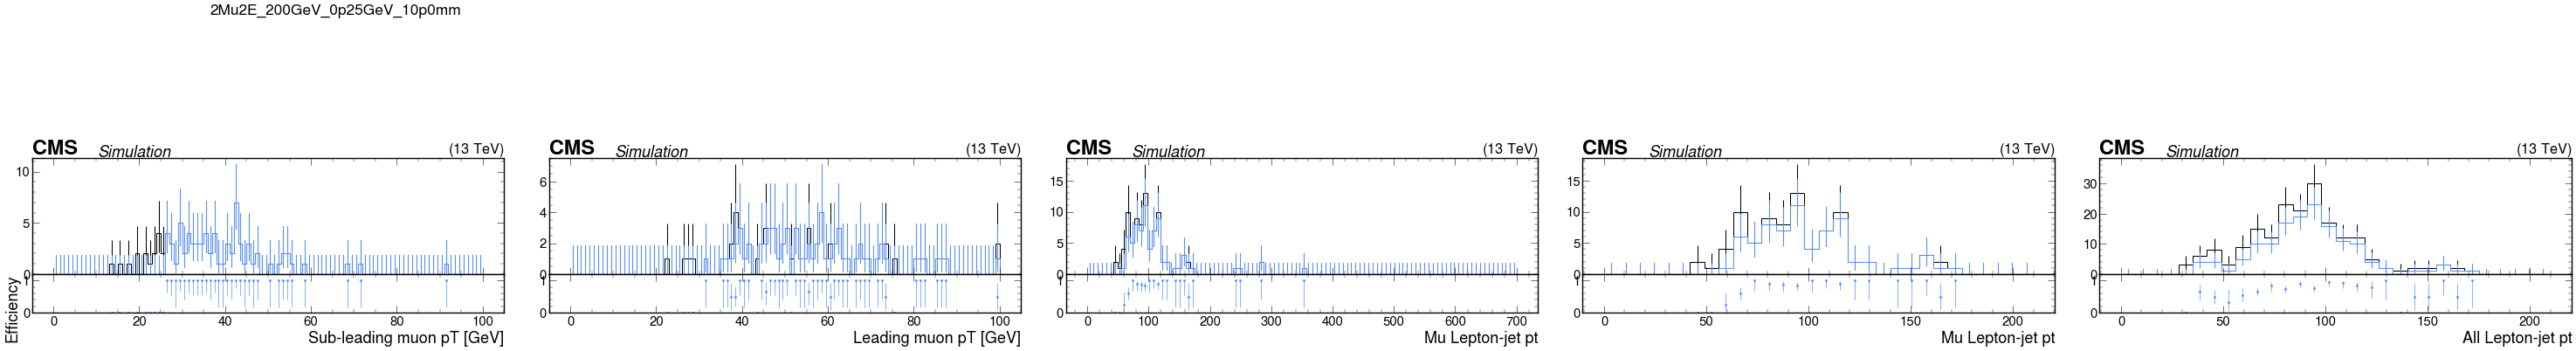

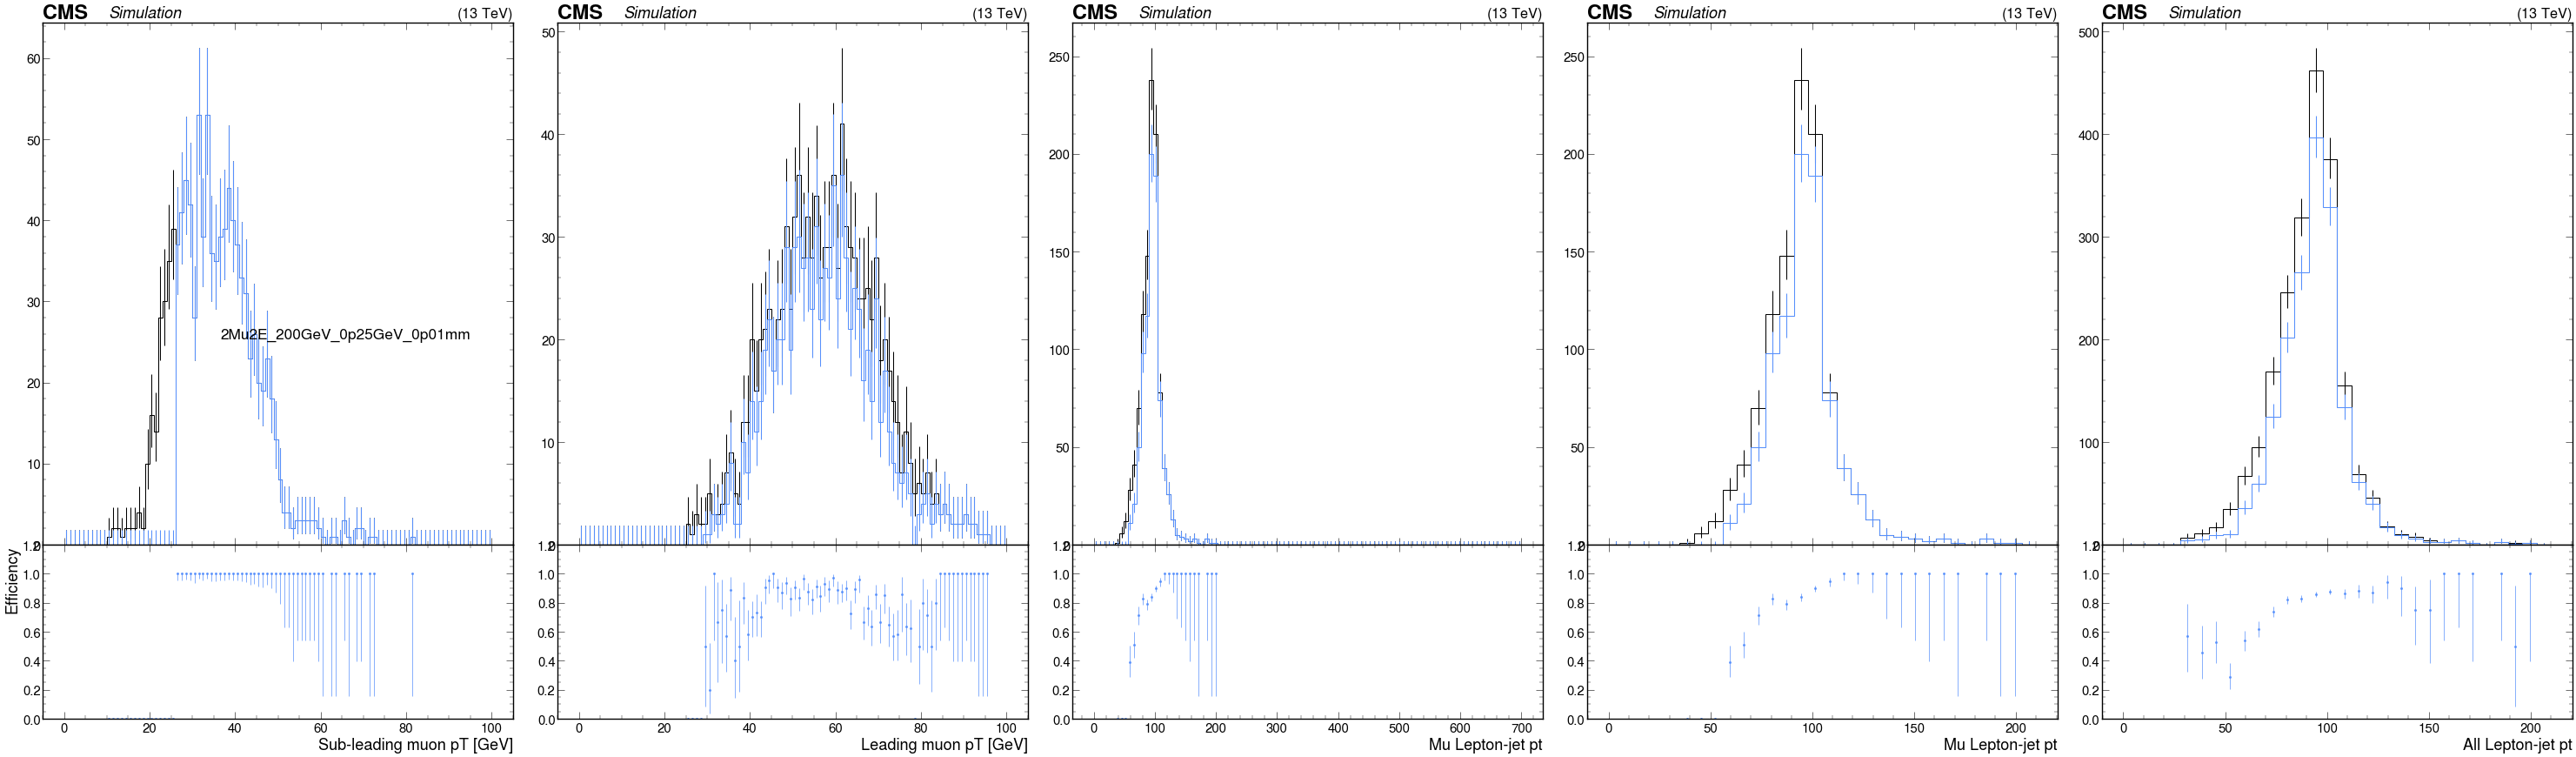

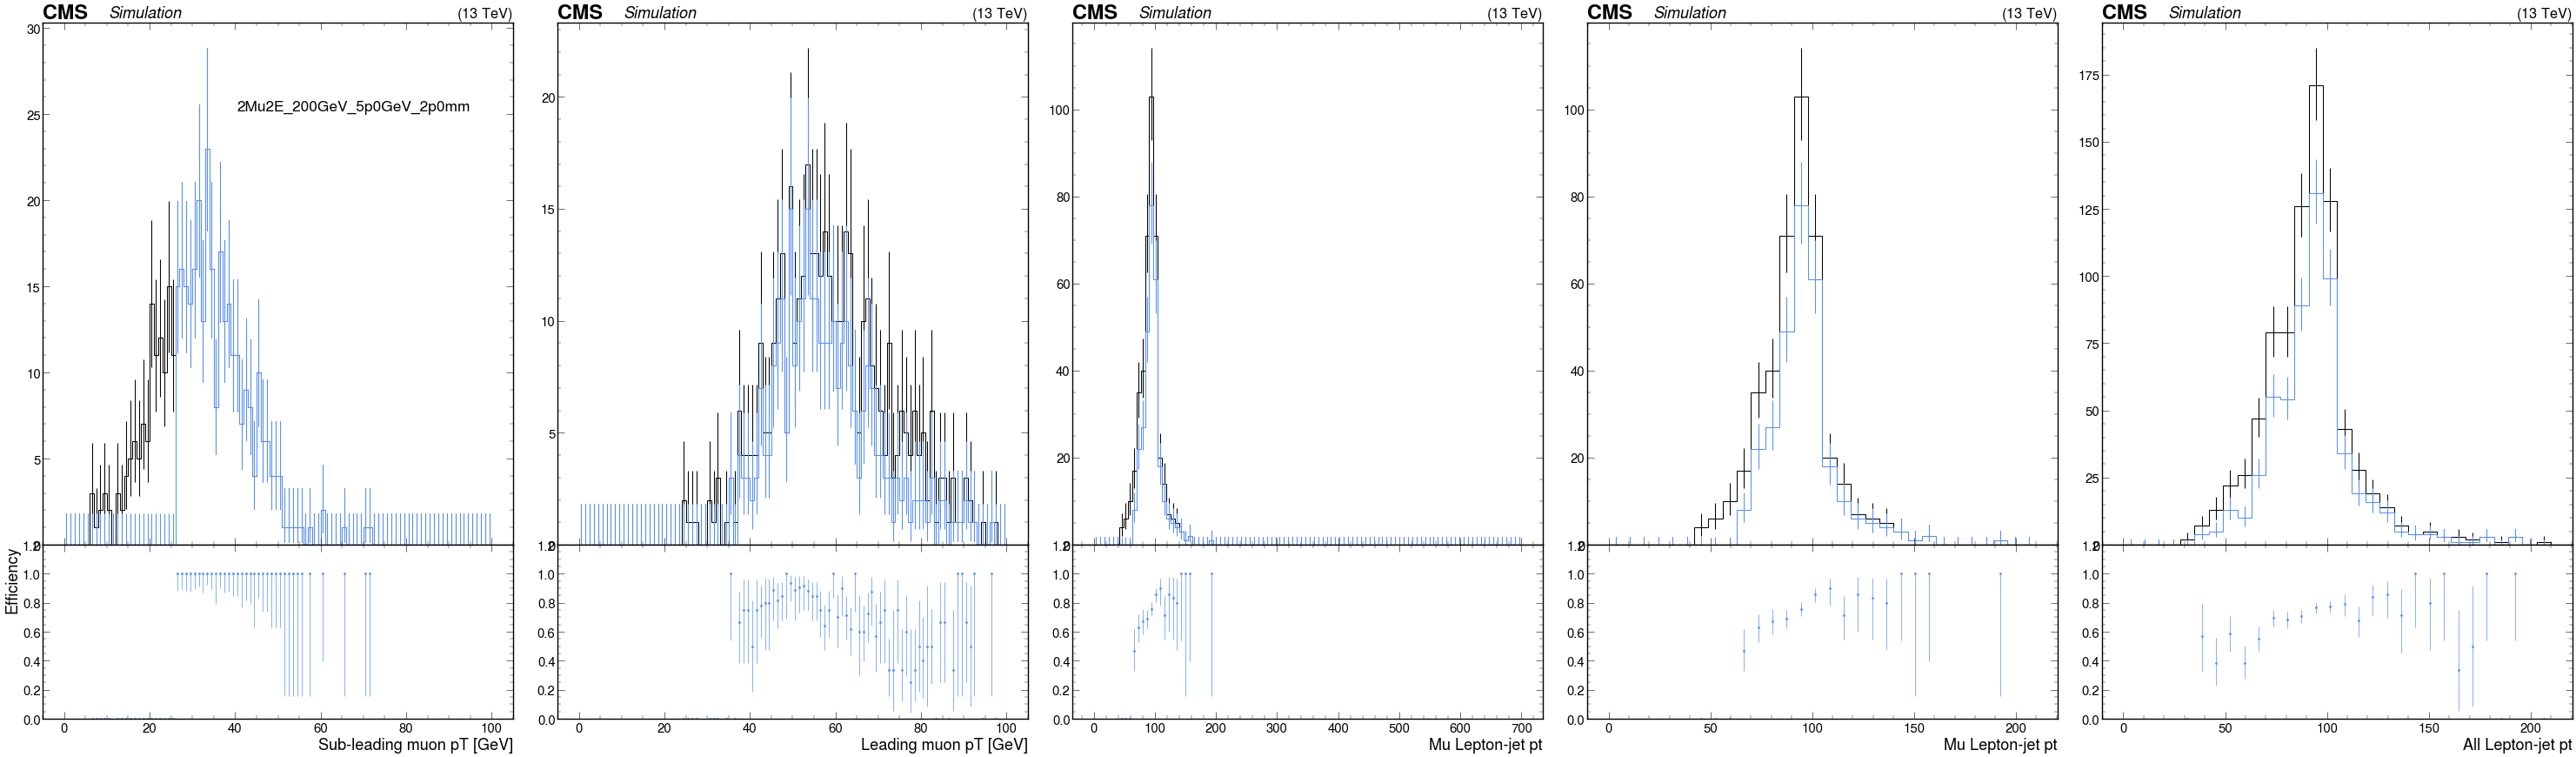

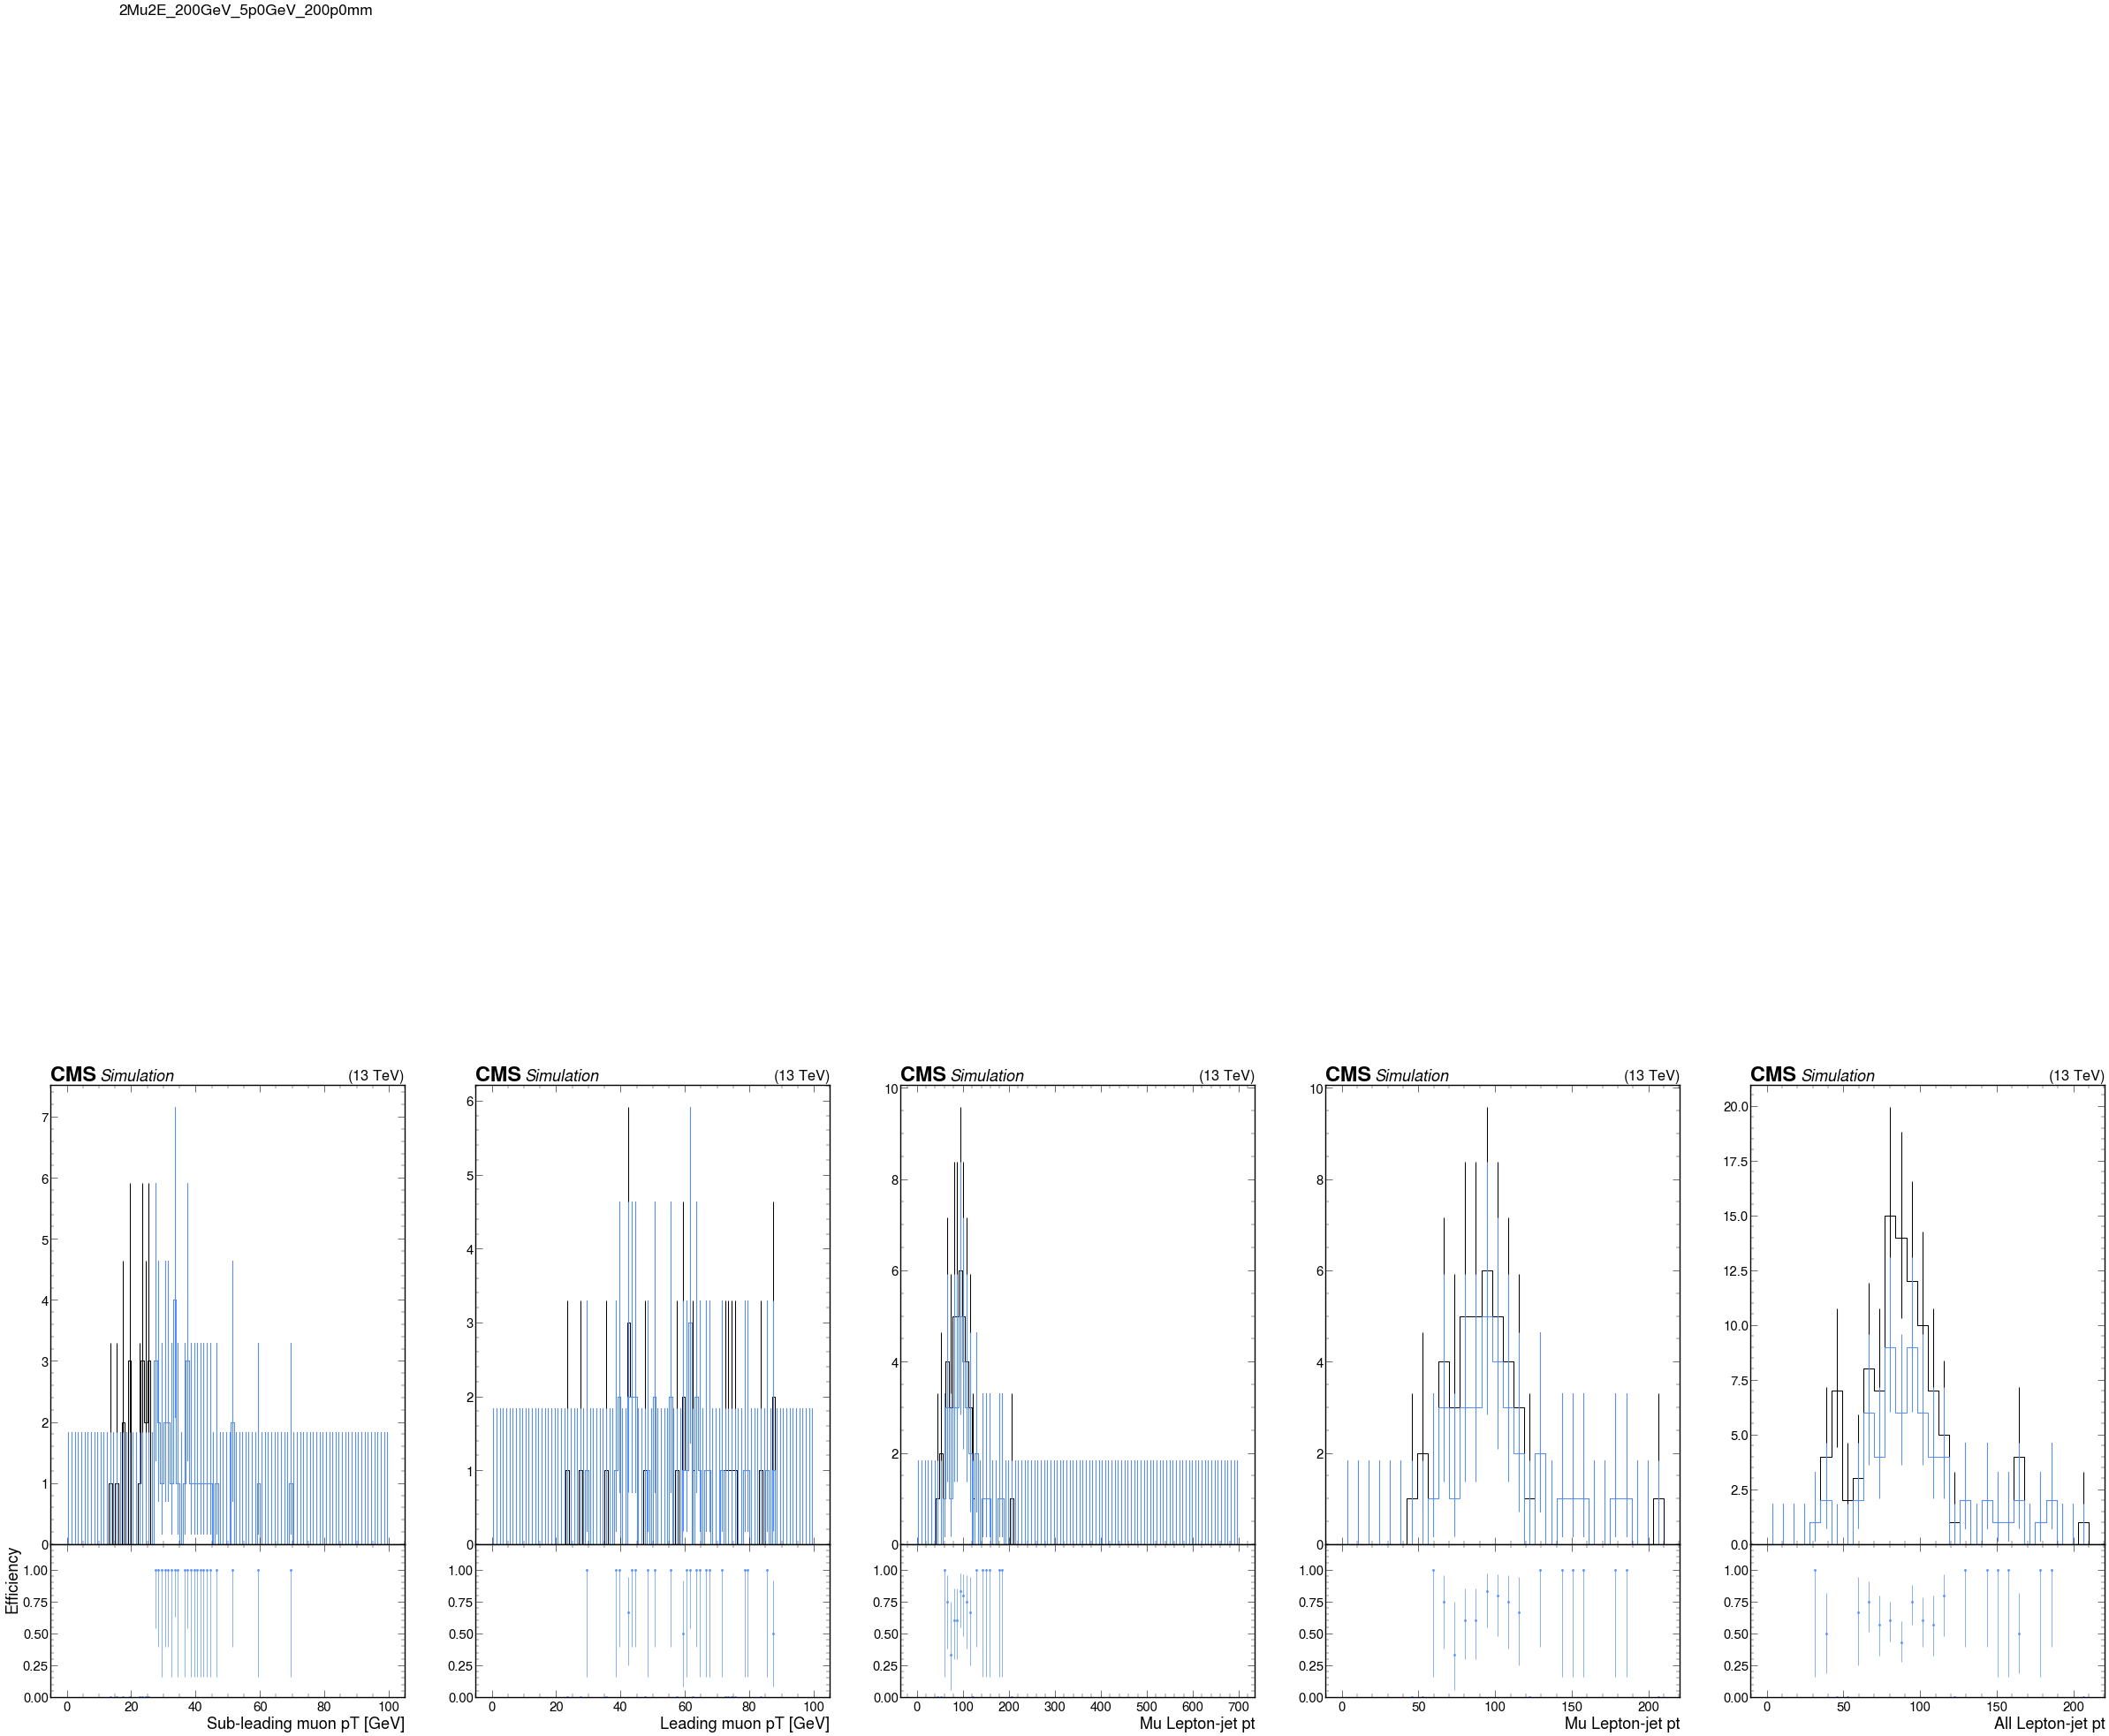

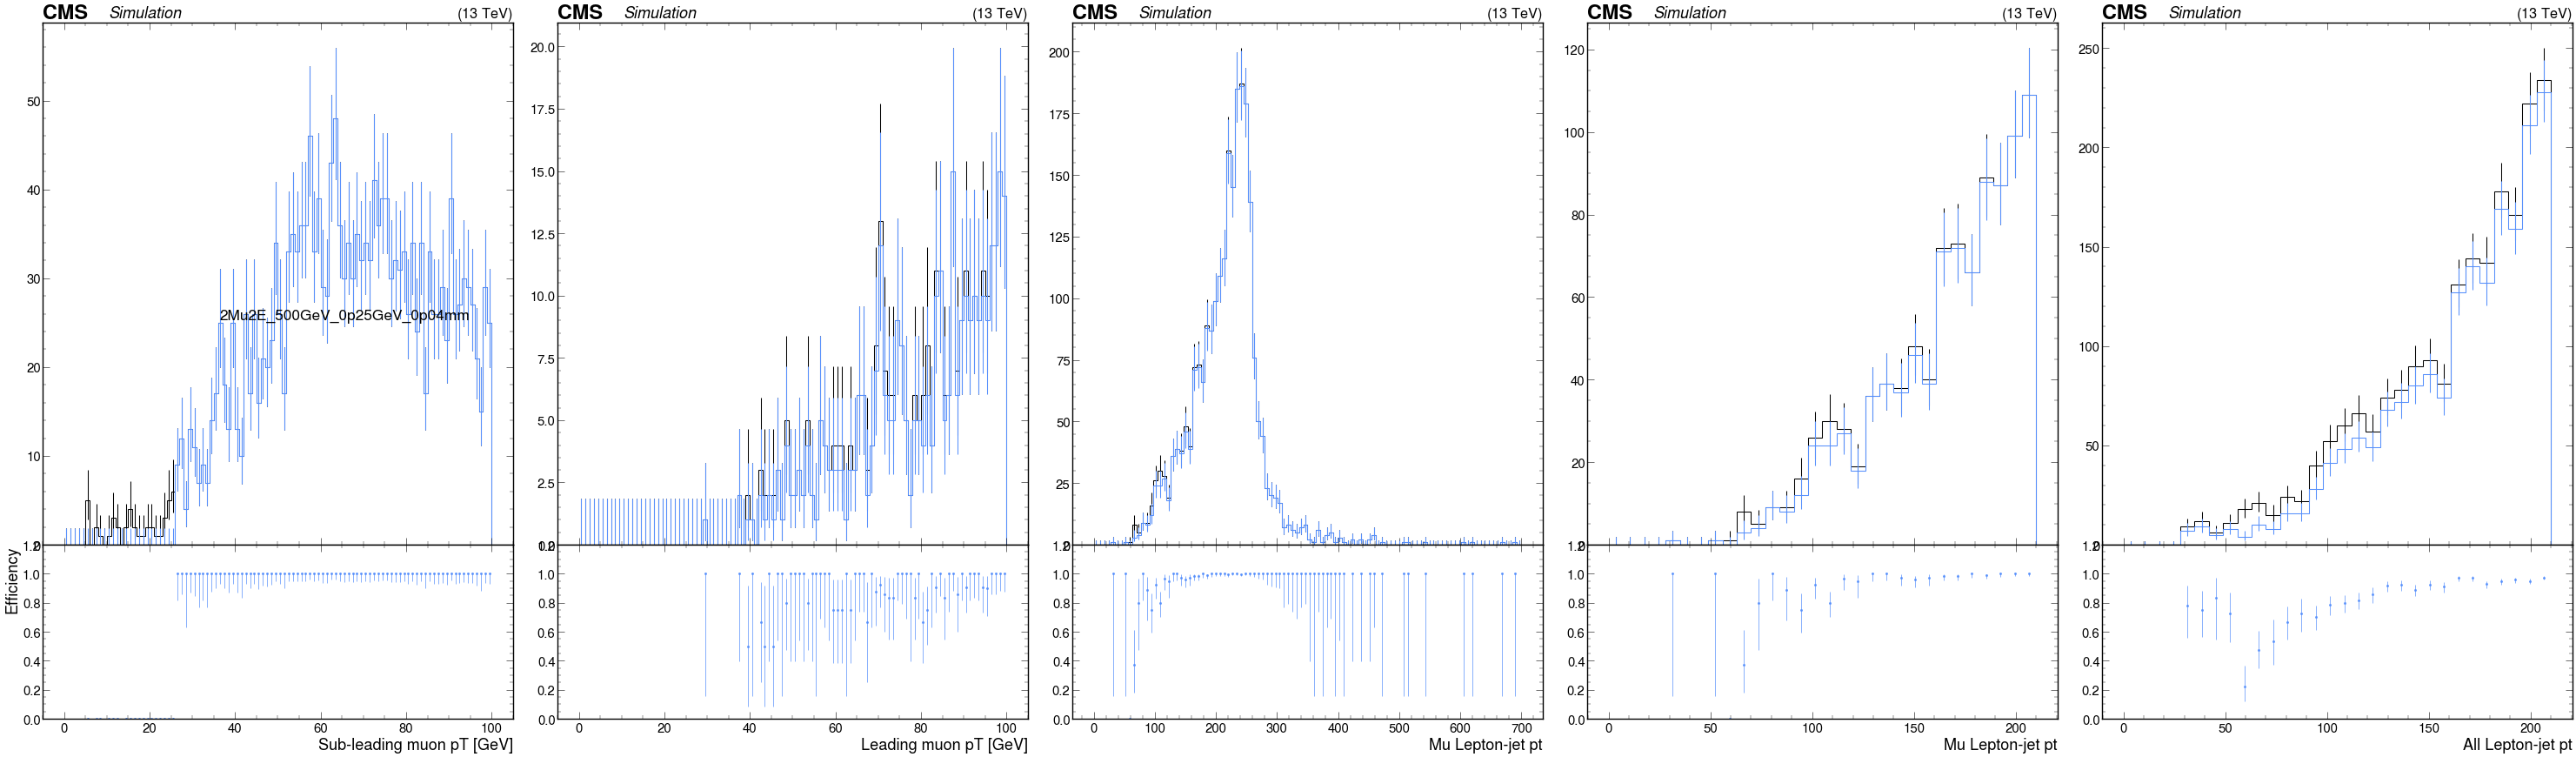

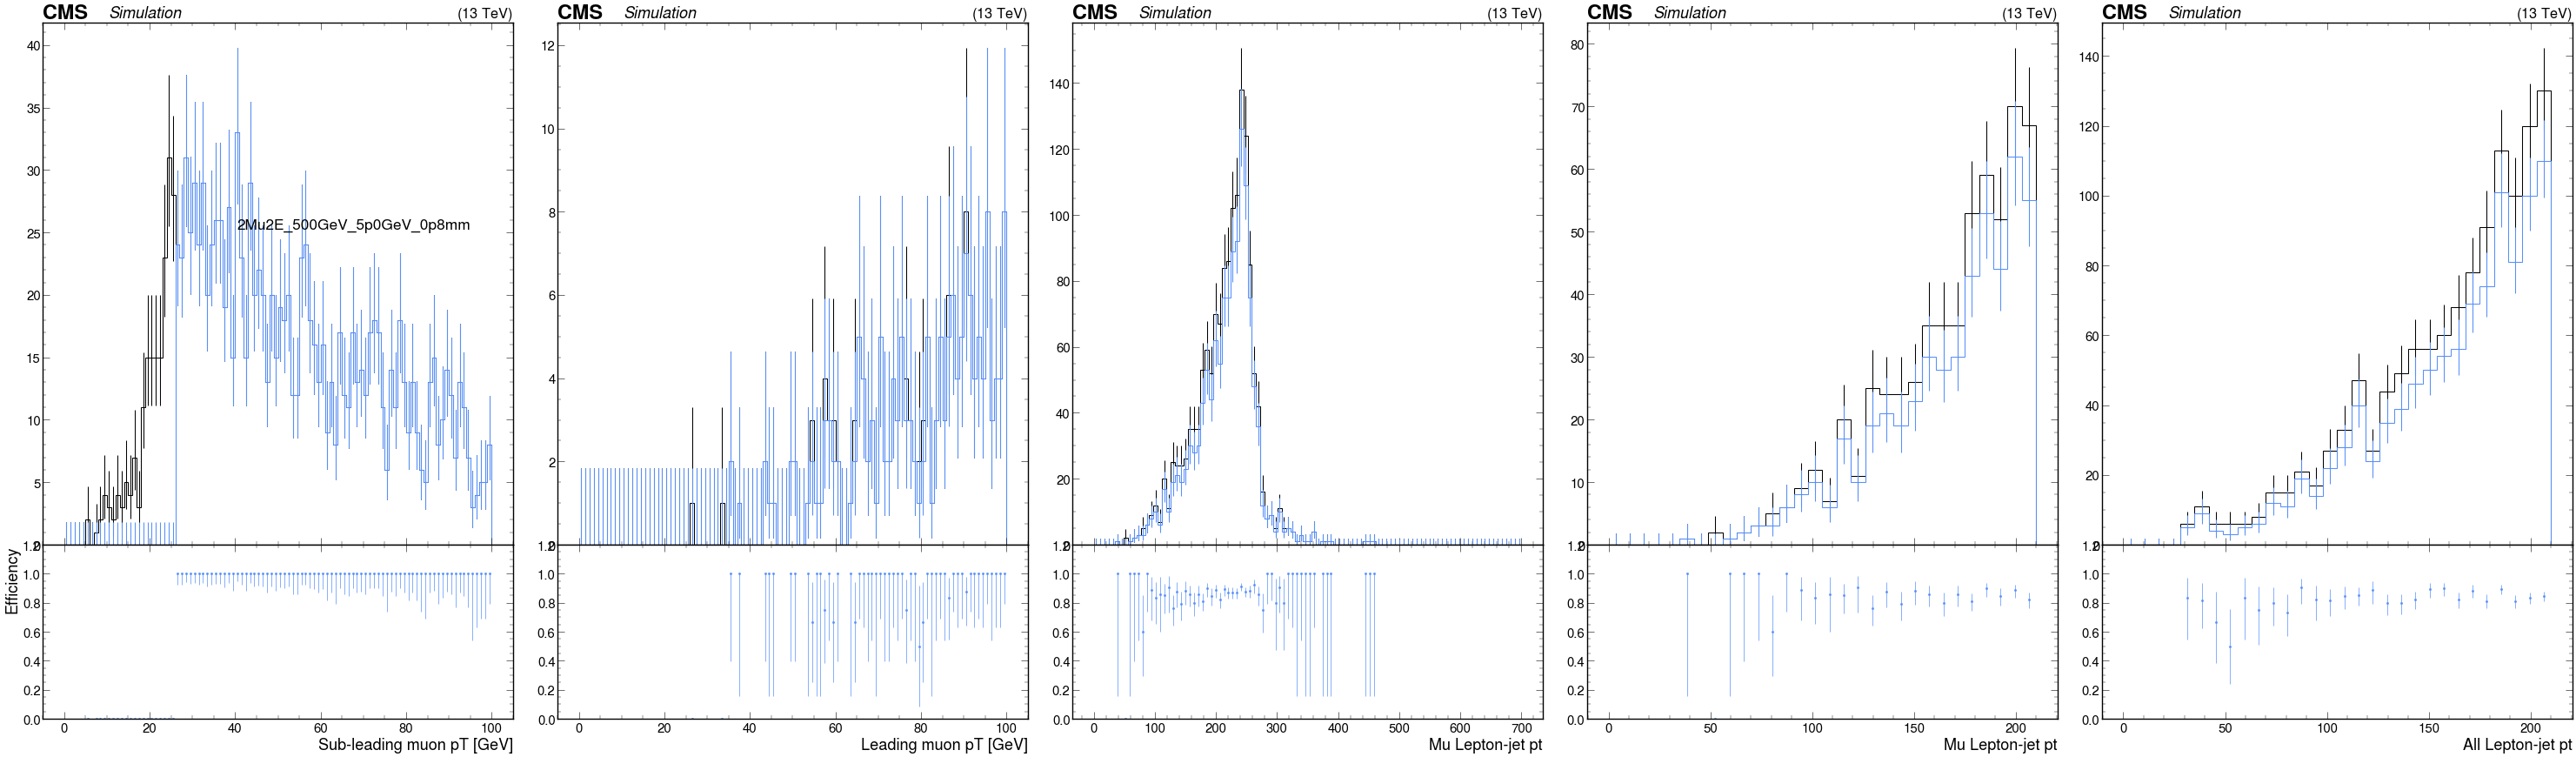

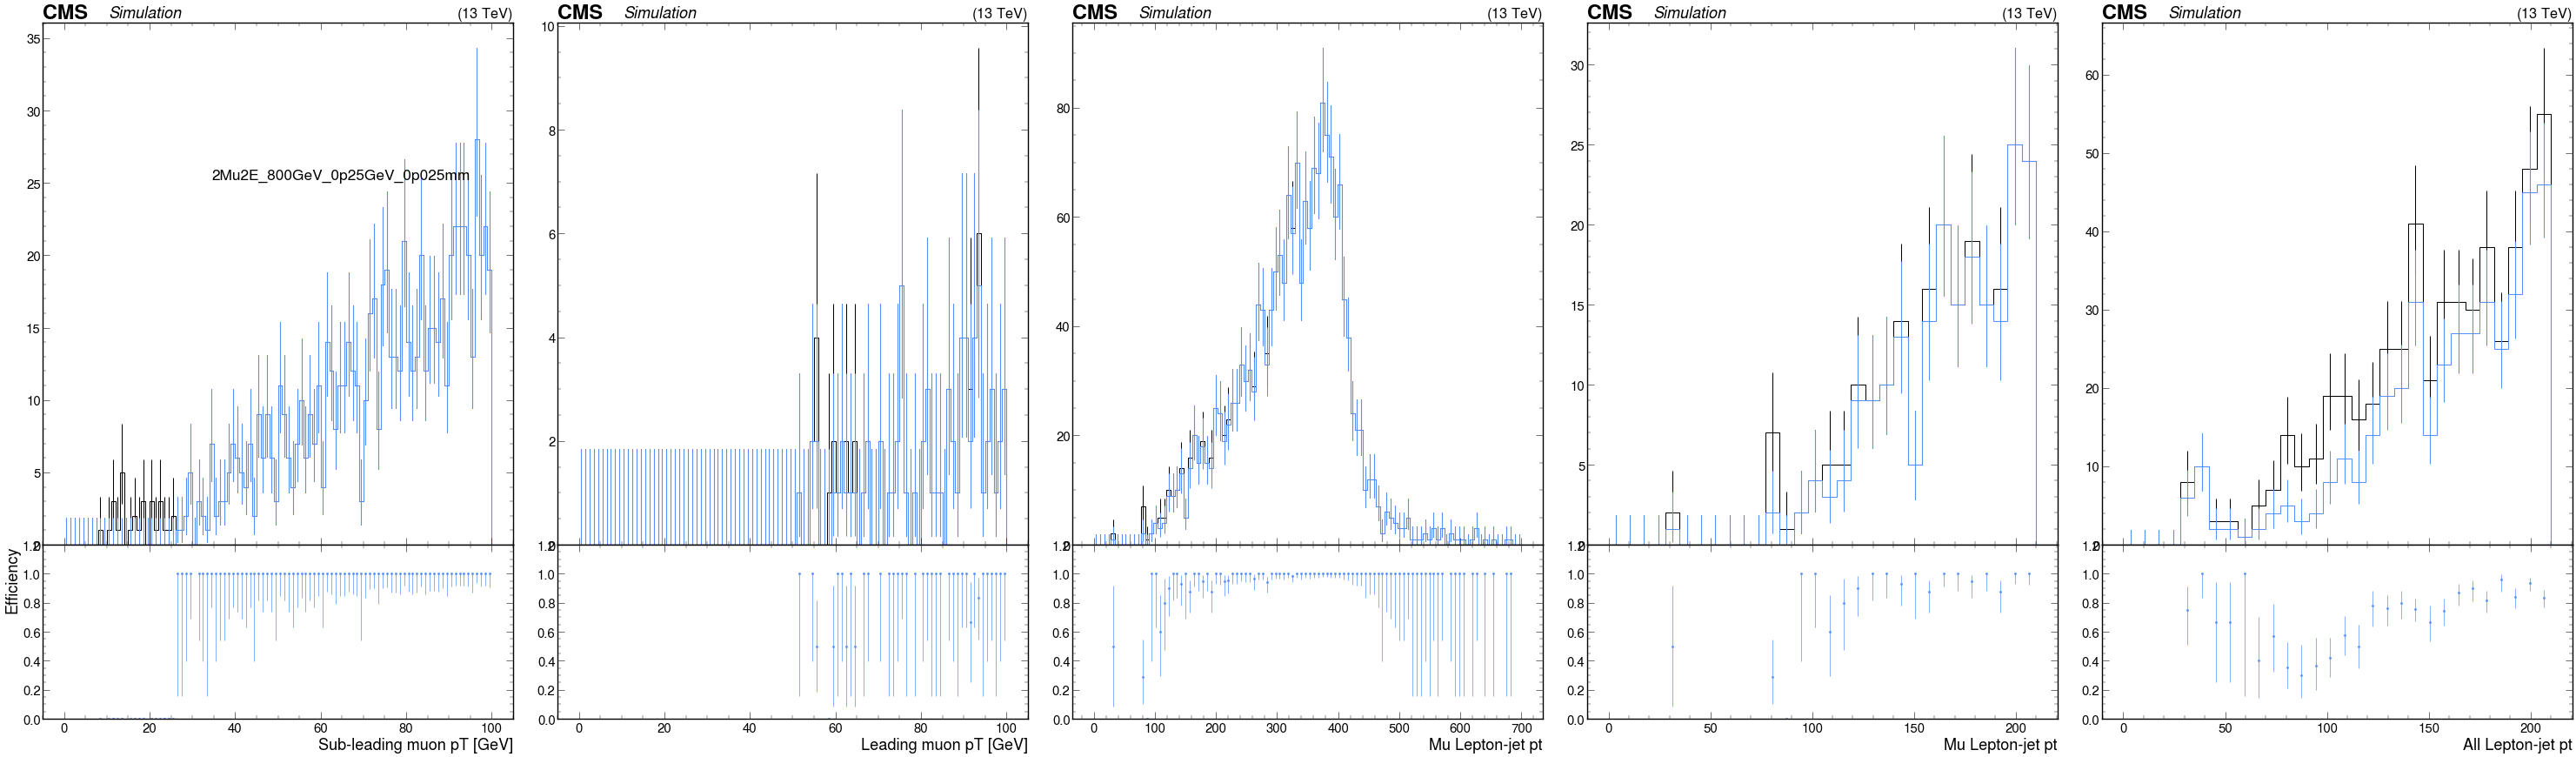

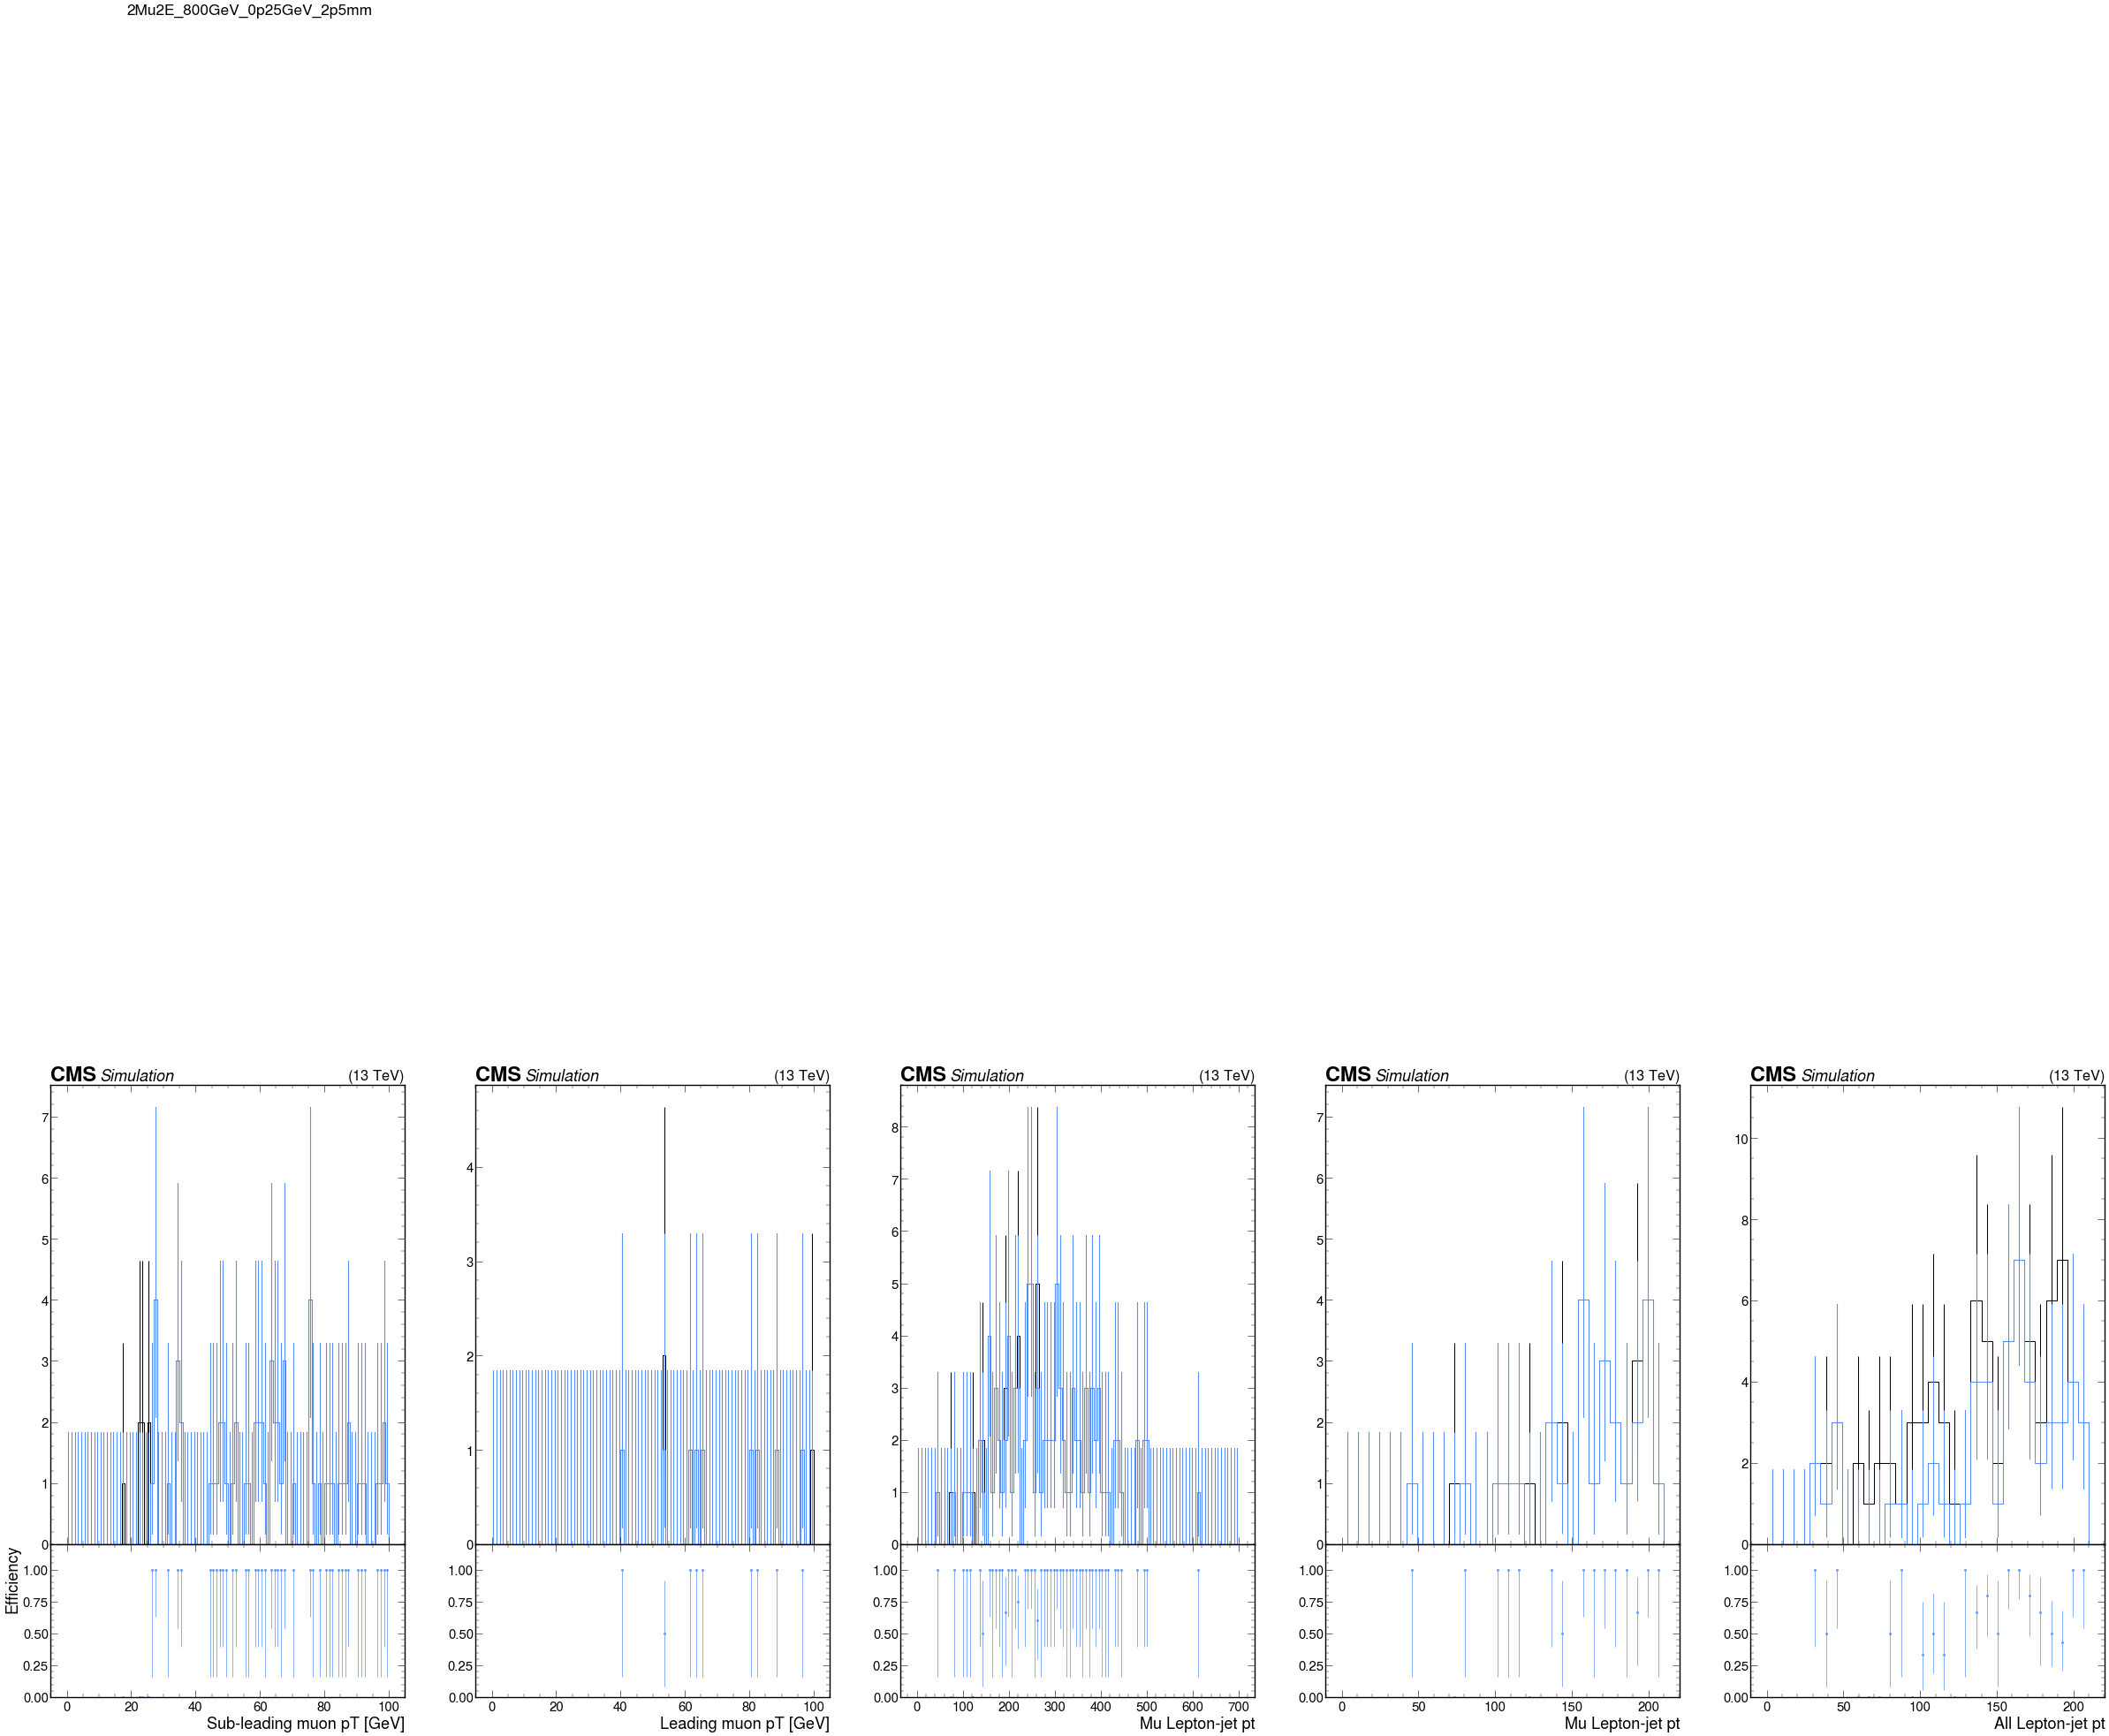

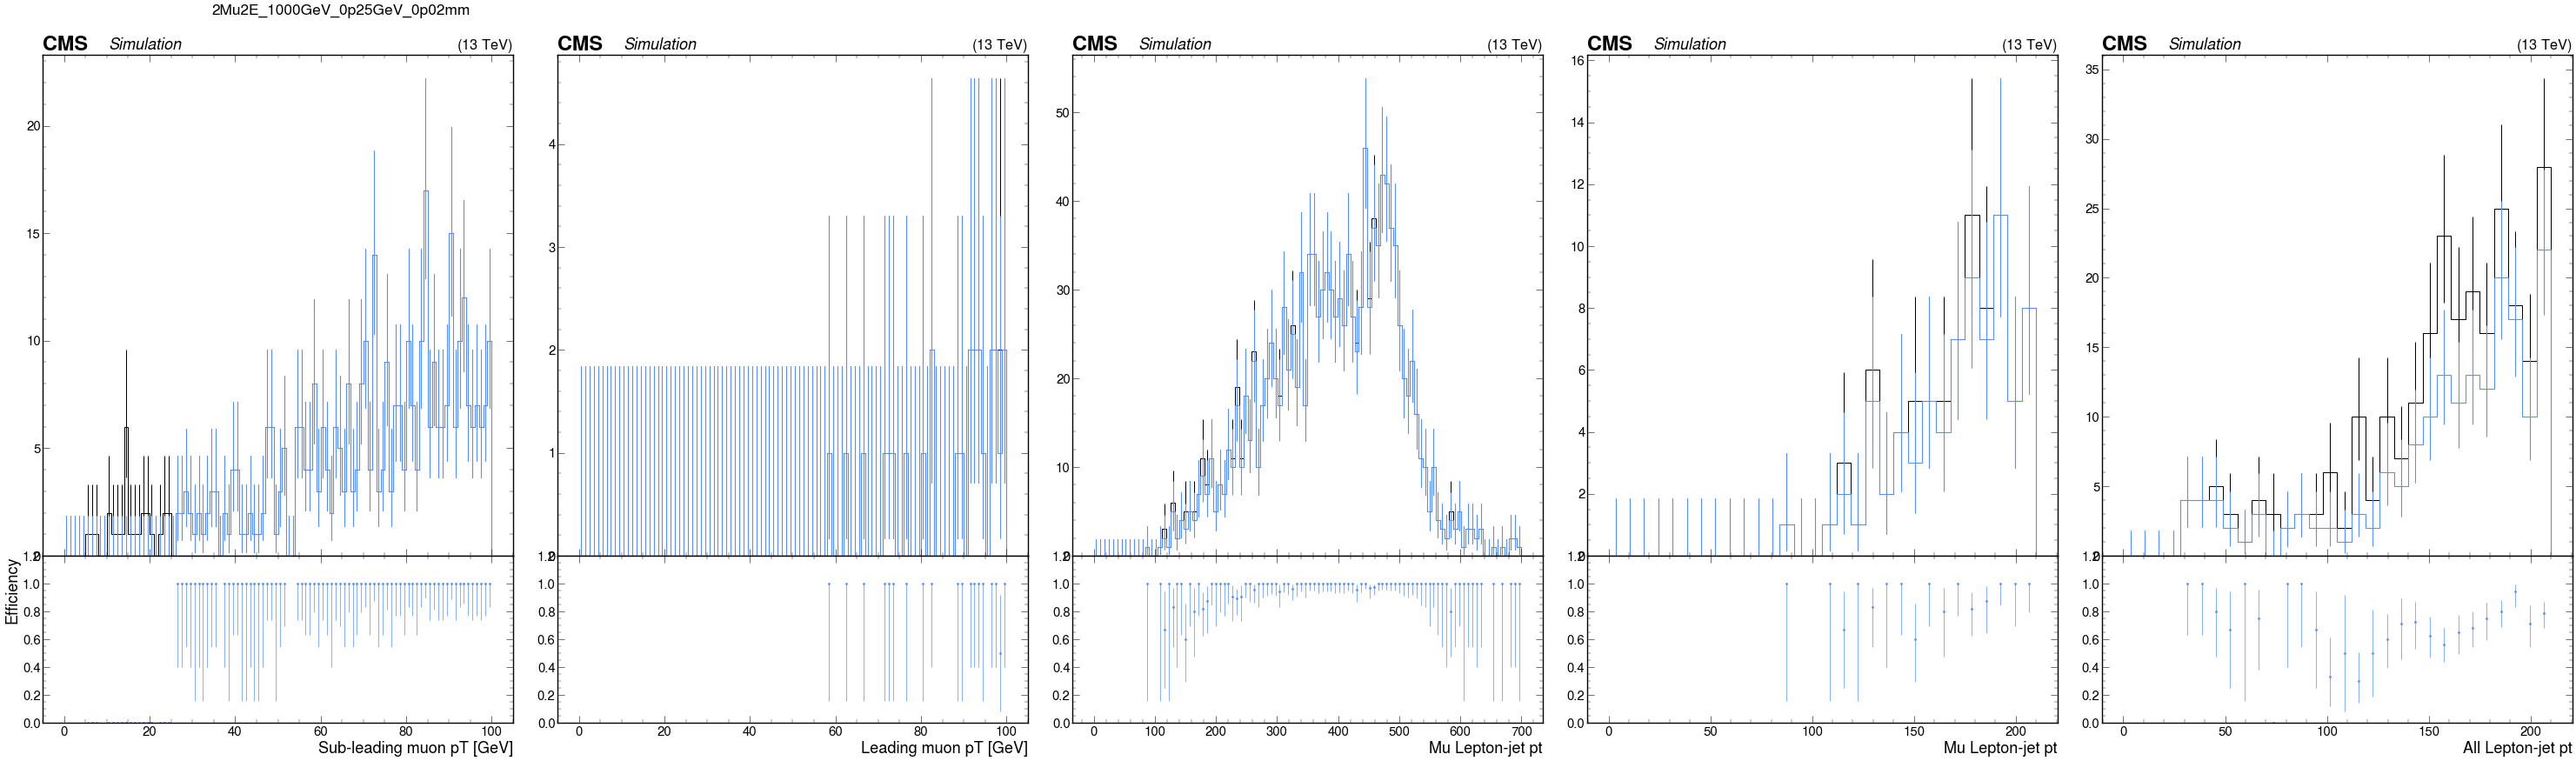

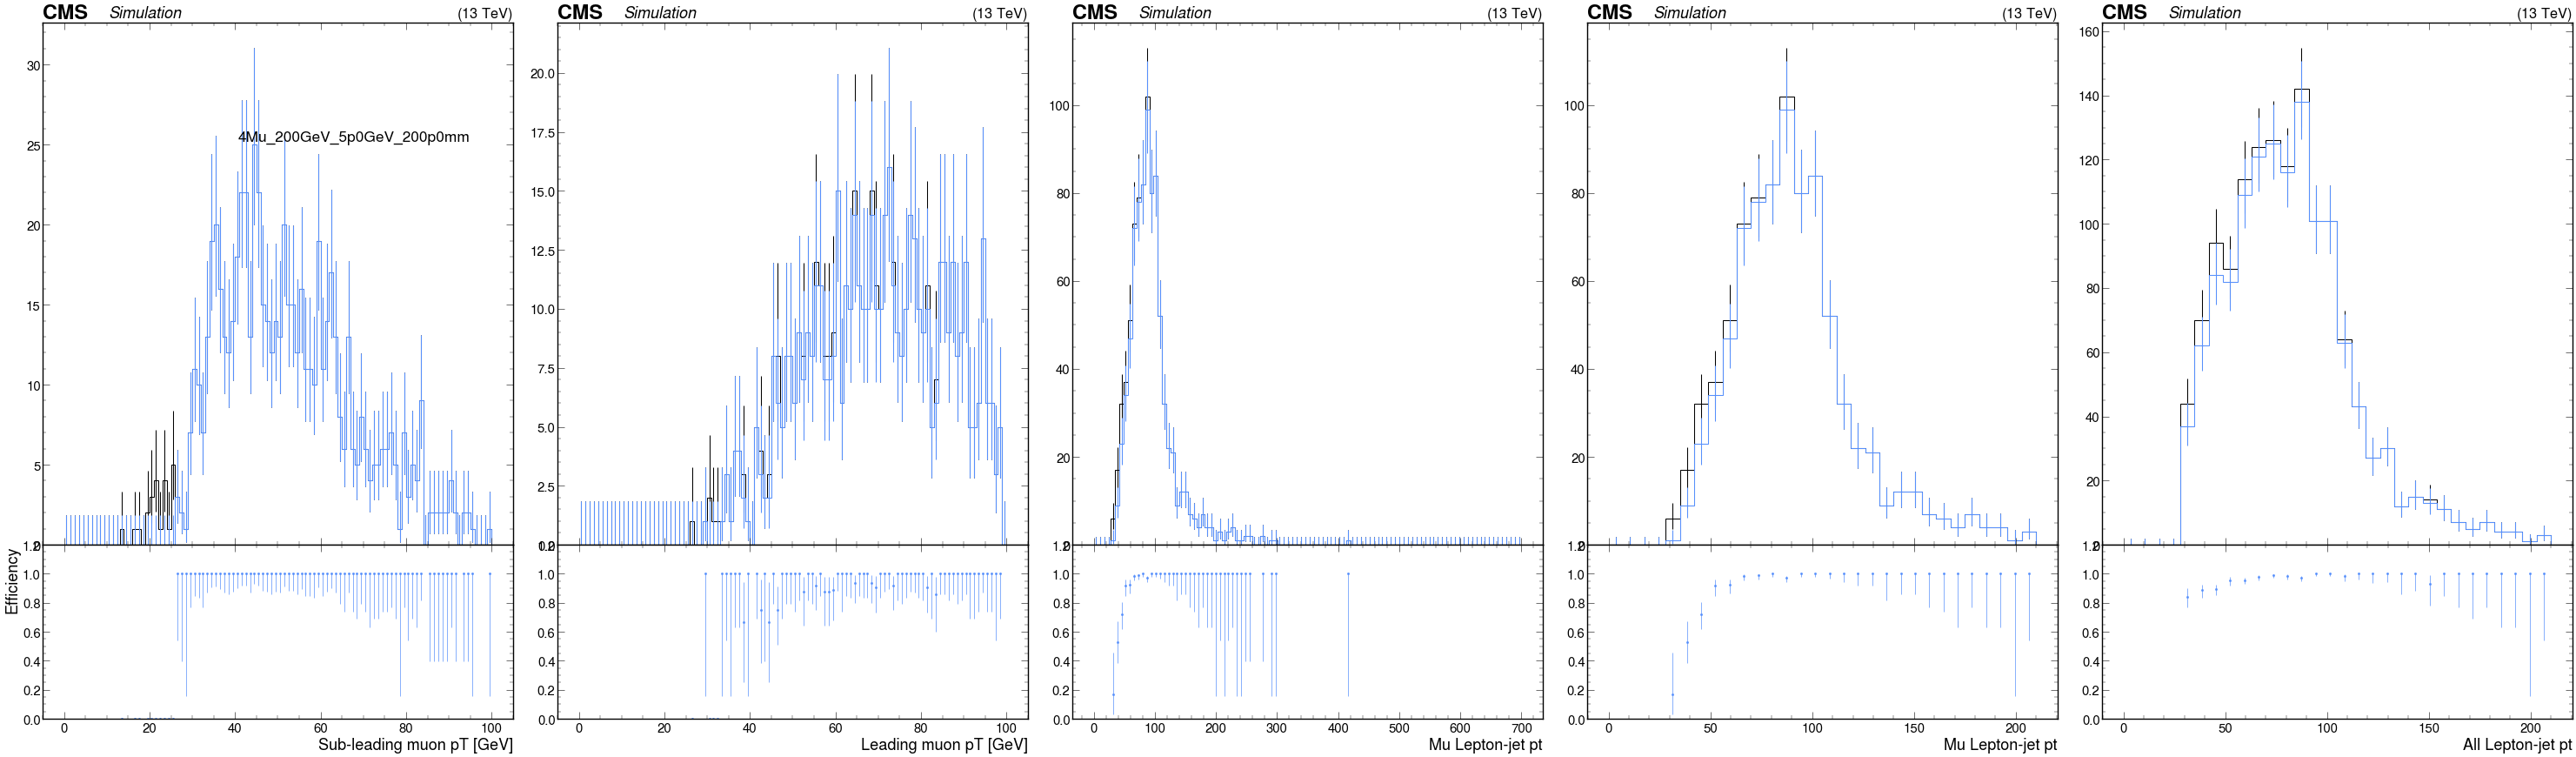

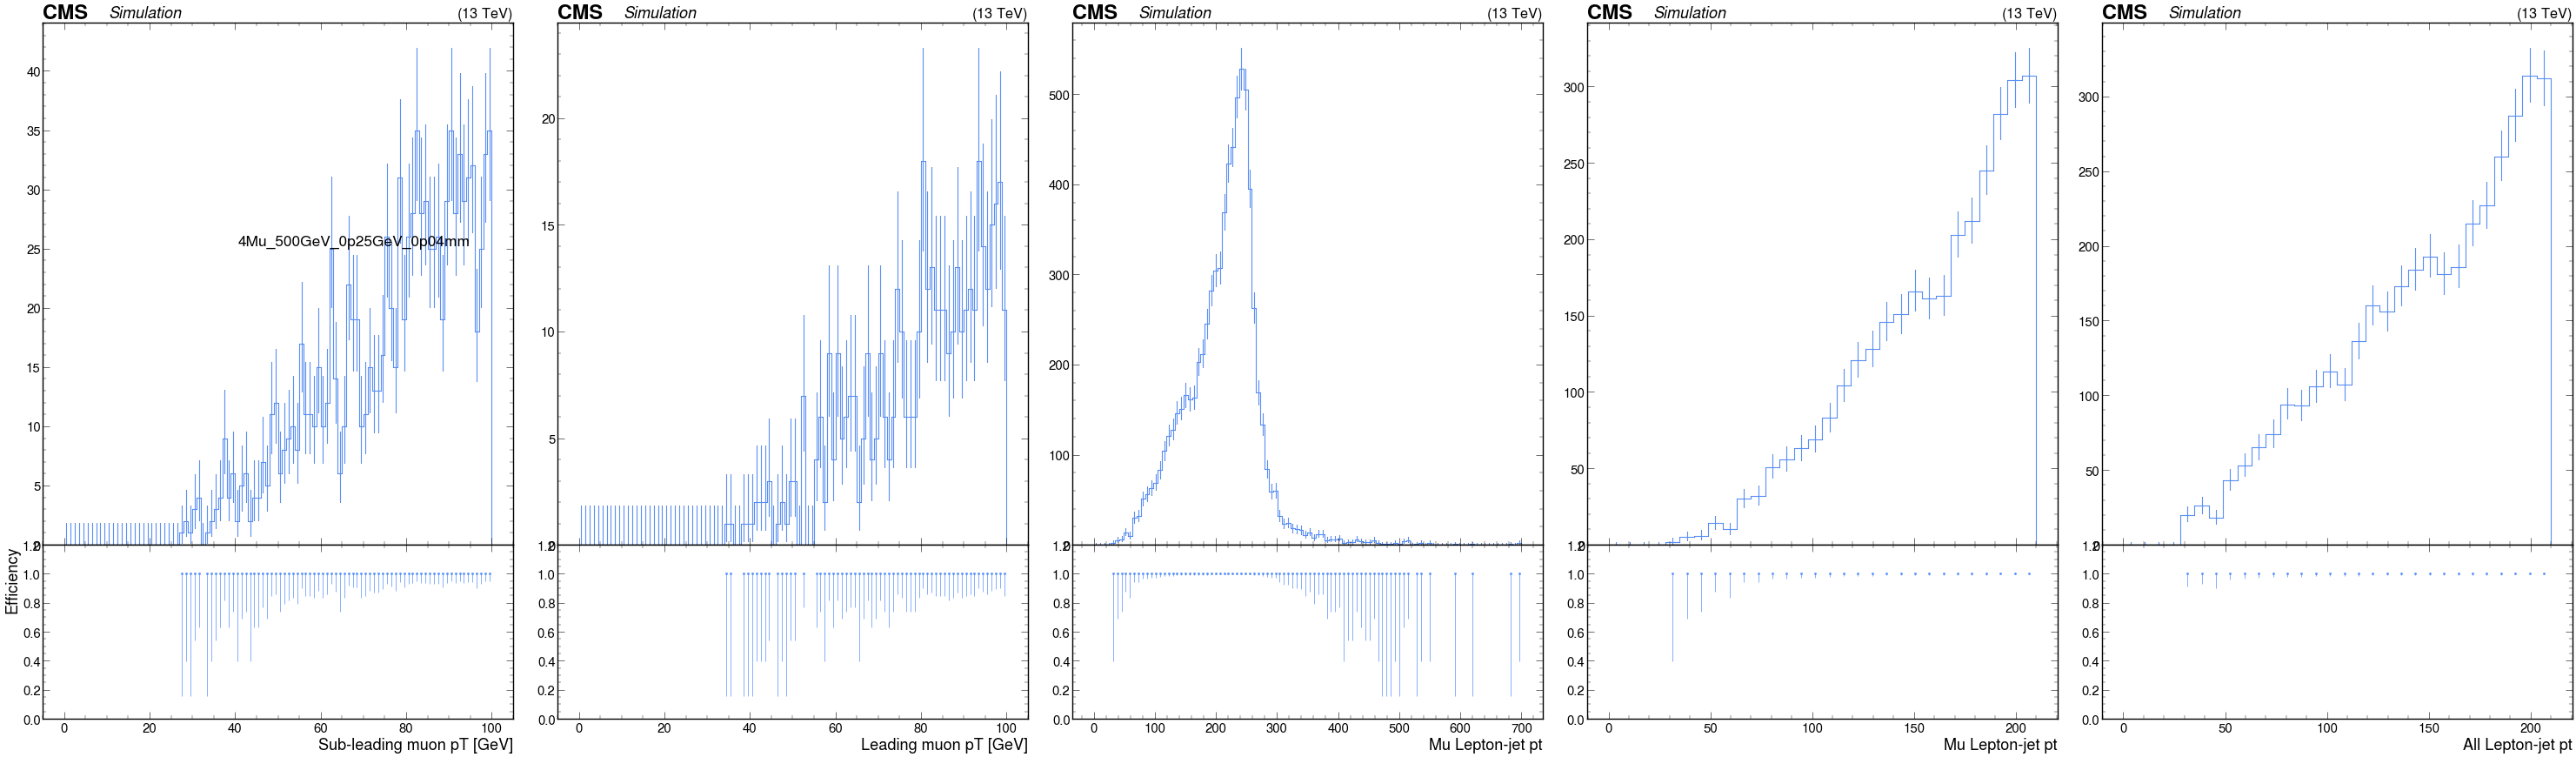

In [9]:
num_ch = "base"
denom_ch = "base_noMuPtCut"
plot_name = "all_muon0_pt_vs_all_muon1_pt"

for sample in samples:
    nums = [out[sample]["hists"][plot_name][ num_ch, sum,:],
            out[sample]["hists"][plot_name][ num_ch, :,sum],
            out[sample]["hists"]["mu_lj_pt"][ num_ch, :],
            out[sample]["hists"]["mu_lj_pt"][ num_ch, :30],
           out[sample]["hists"]["lj_pt"][ num_ch, :30]]
    denoms = [out[sample]["hists"][plot_name][denom_ch, sum,:],
              out[sample]["hists"][plot_name][denom_ch, :,sum],
              out[sample]["hists"]["mu_lj_pt"][ denom_ch, :],
              out[sample]["hists"]["mu_lj_pt"][ denom_ch, :30],
              out[sample]["hists"]["lj_pt"][ denom_ch, :30]]

    plot_ratio_row(nums,denoms,sample,xlabel=["Sub-leading muon pT [GeV]","Leading muon pT [GeV]","Mu Lepton-jet pt","Mu Lepton-jet pt","All Lepton-jet pt"])


The first two plots show that the cut was applied correctly. The lepton jet pt plots look like we expect. For the 2mu2e case, both muons in one LJ have to be higher than 26 GeV, so there's zero efficiency below 52 GeV and the efficiency doesn't plateau until over 100 GeV (because as we know, the leptons are normally pretty asymmetric in terms of pt. Murtaza has proven why before). For the 4mu case, the efficiency plateaus closer to 50 GeV since then we can have one lepton from each dark photon decay satisfy the pt requirement.

Now to check how it affects the number of muons or the dR between muons in the lepton jet. 

/tmp/ipykernel_3113/3524104532.py:89: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
/tmp/ipykernel_3113/3524104532.py:89: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
/tmp/ipykernel_3113/3524104532.py:89: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
/tmp/ipykernel_3113/3524104532.py:89: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
/tmp/ipykernel_3113/3524104532.py:89: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
/tmp/ipykernel_3113/3524104532.py:89: UserWarning: Tight layout not applied. tight_la

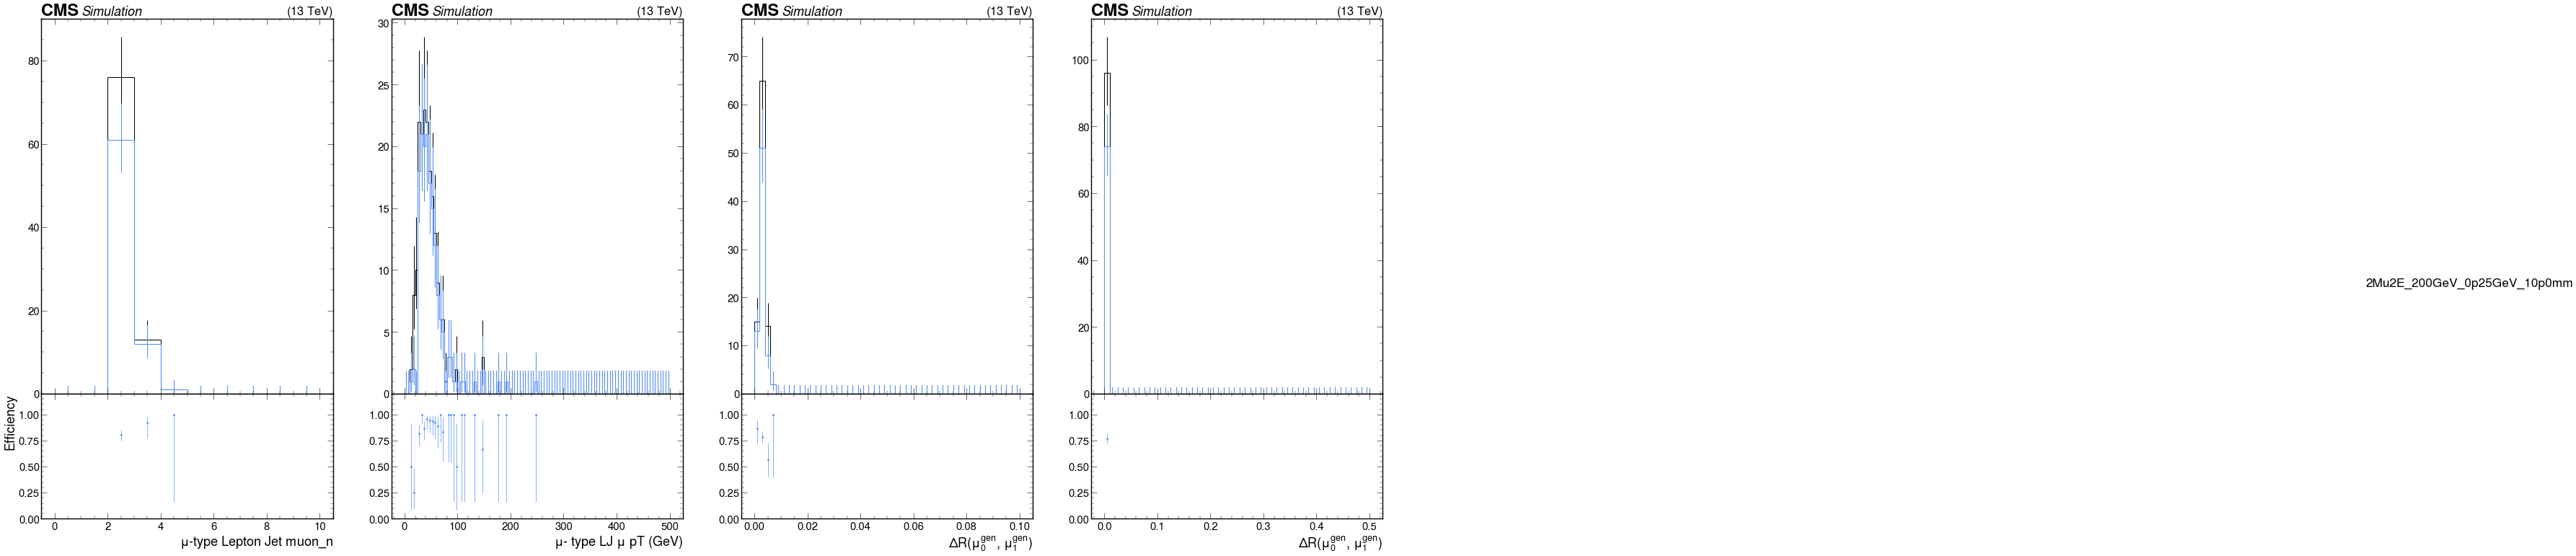

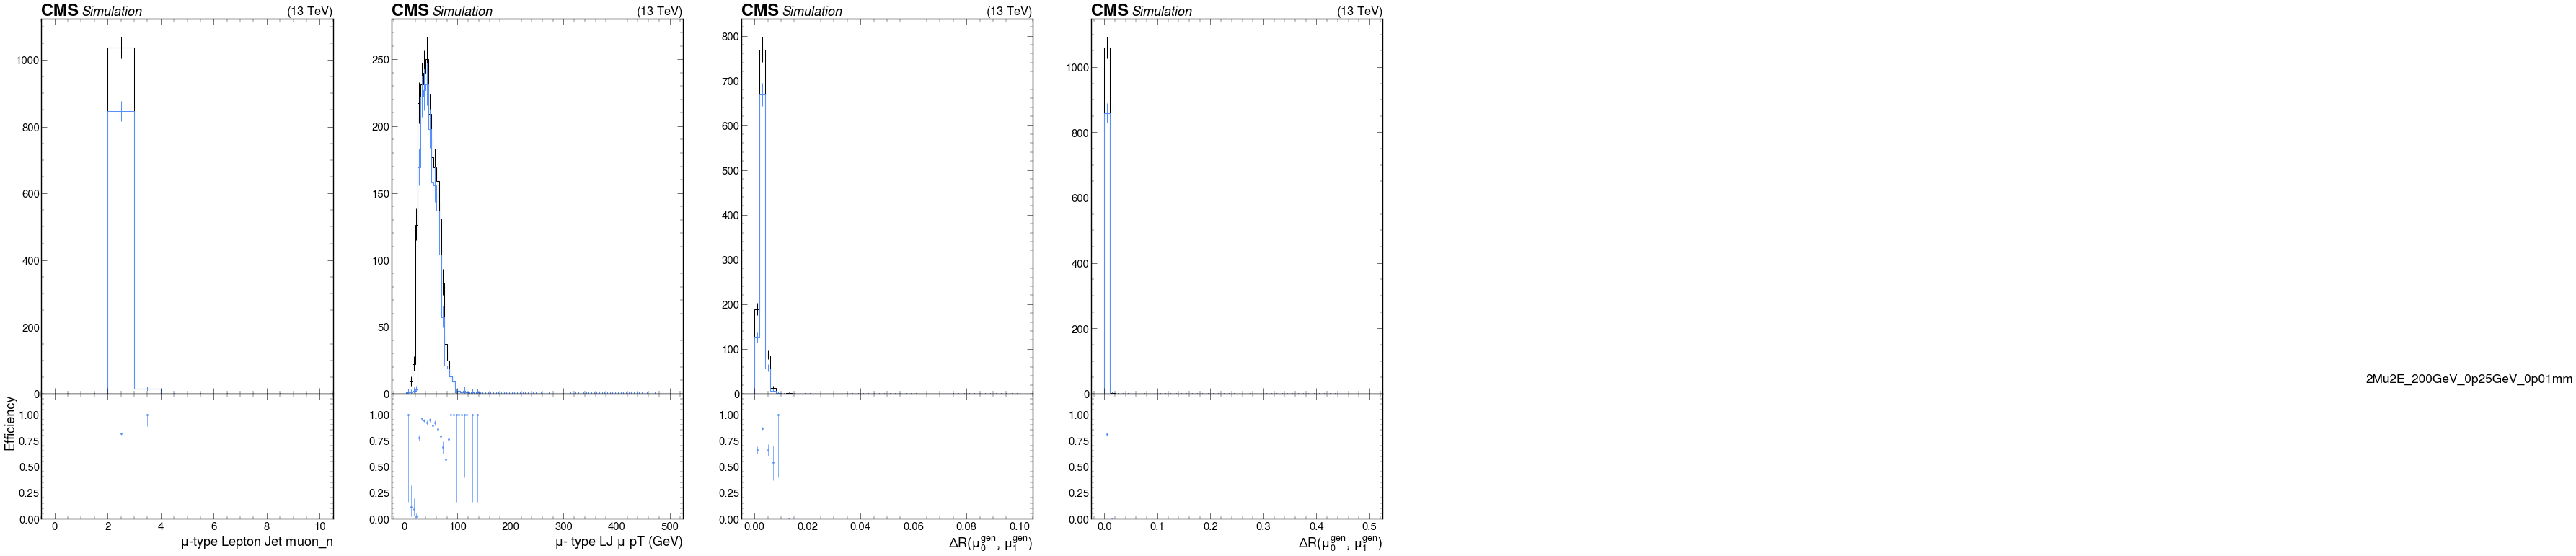

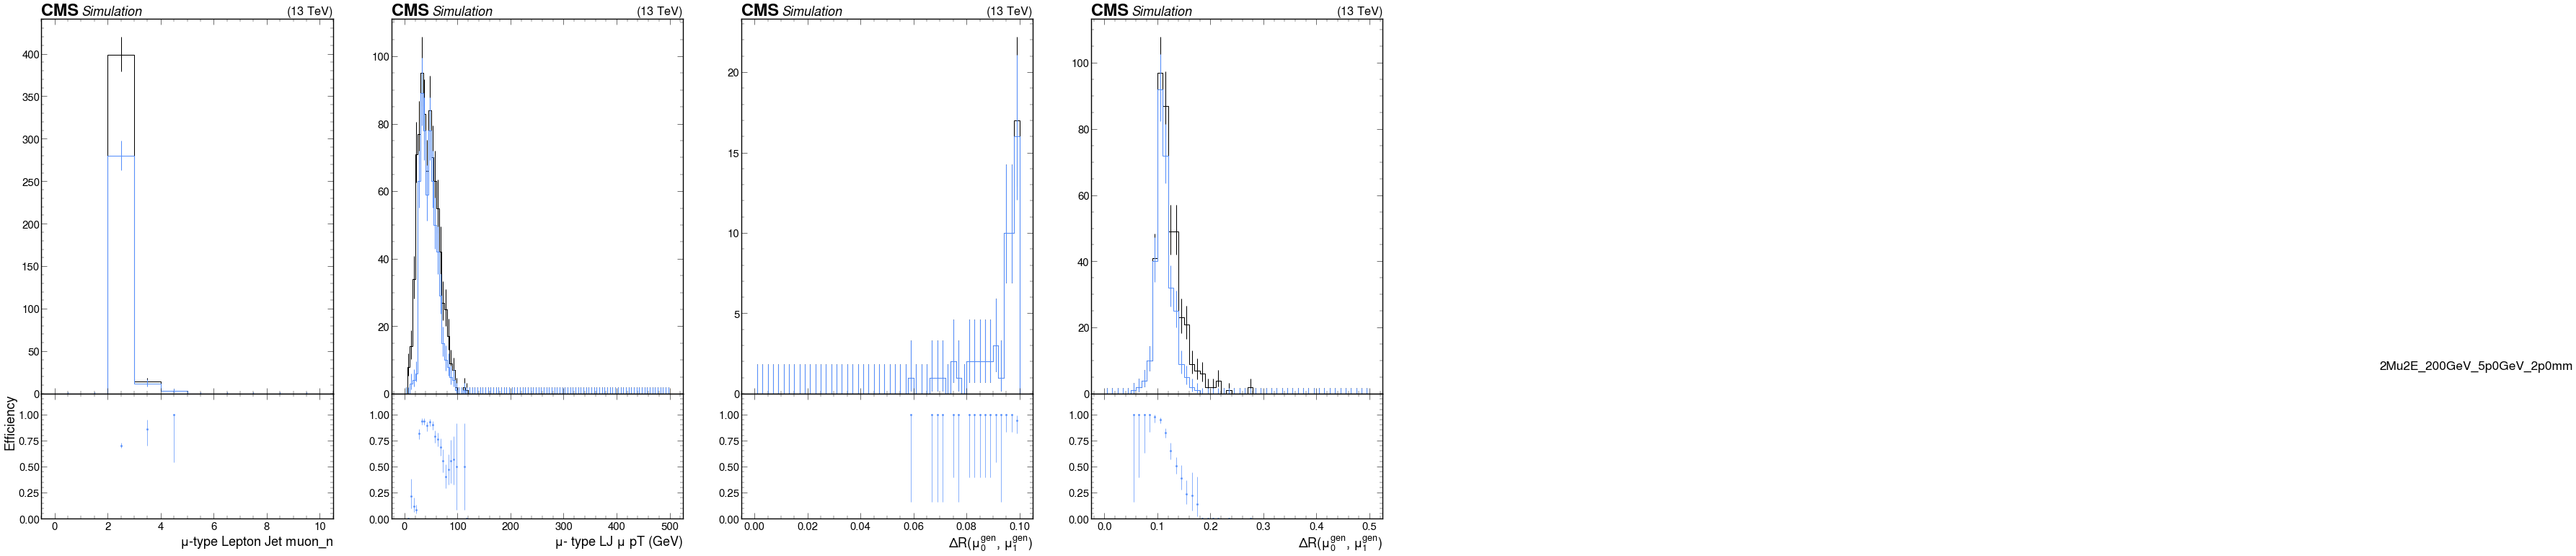

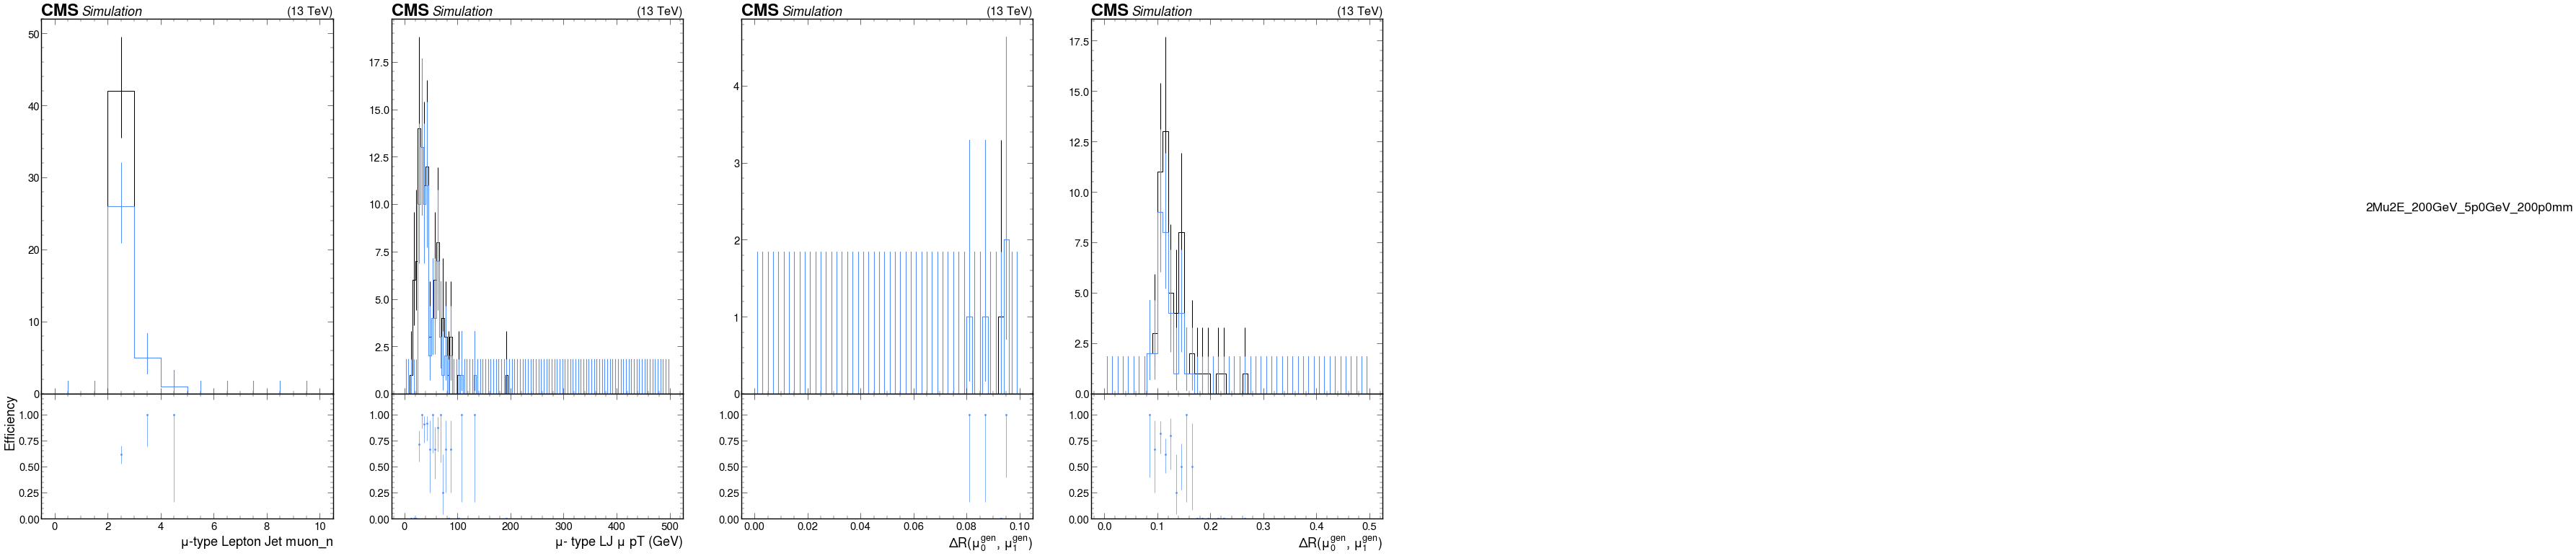

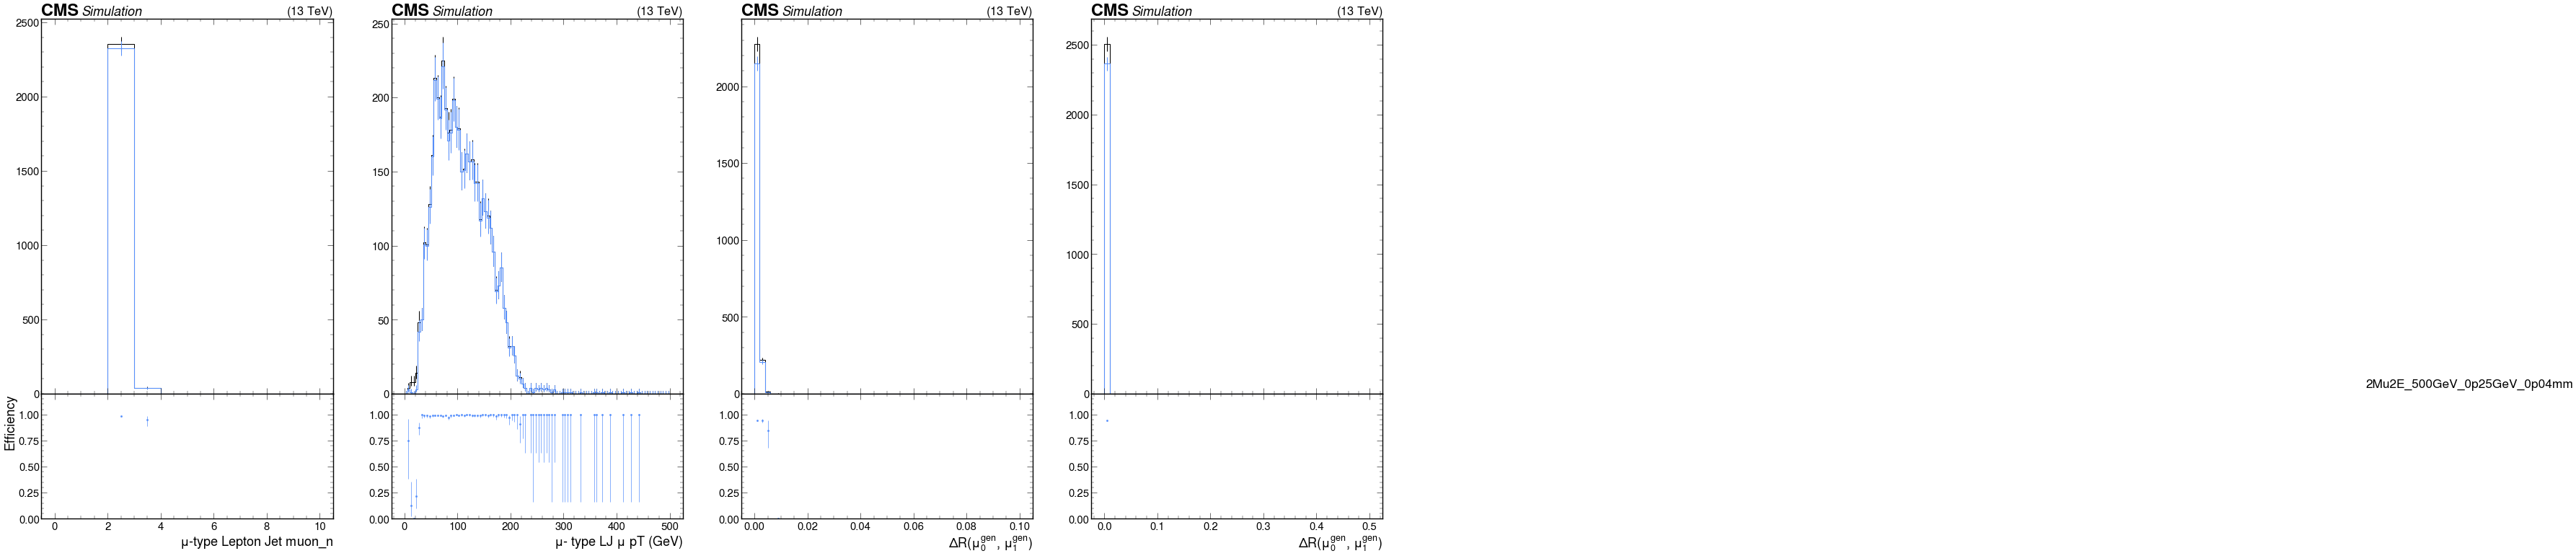

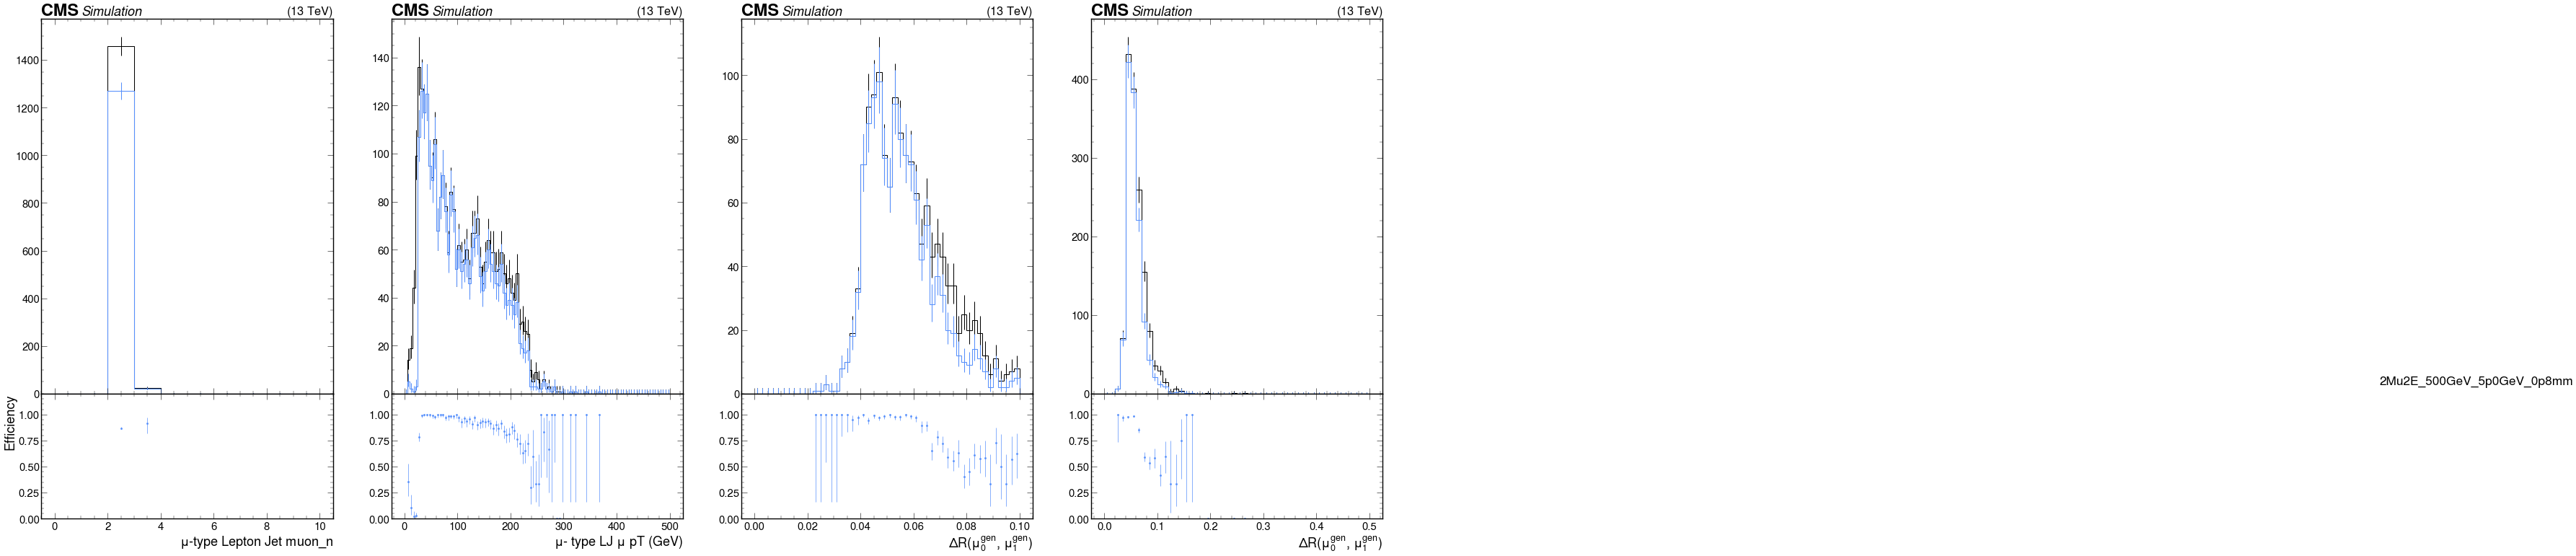

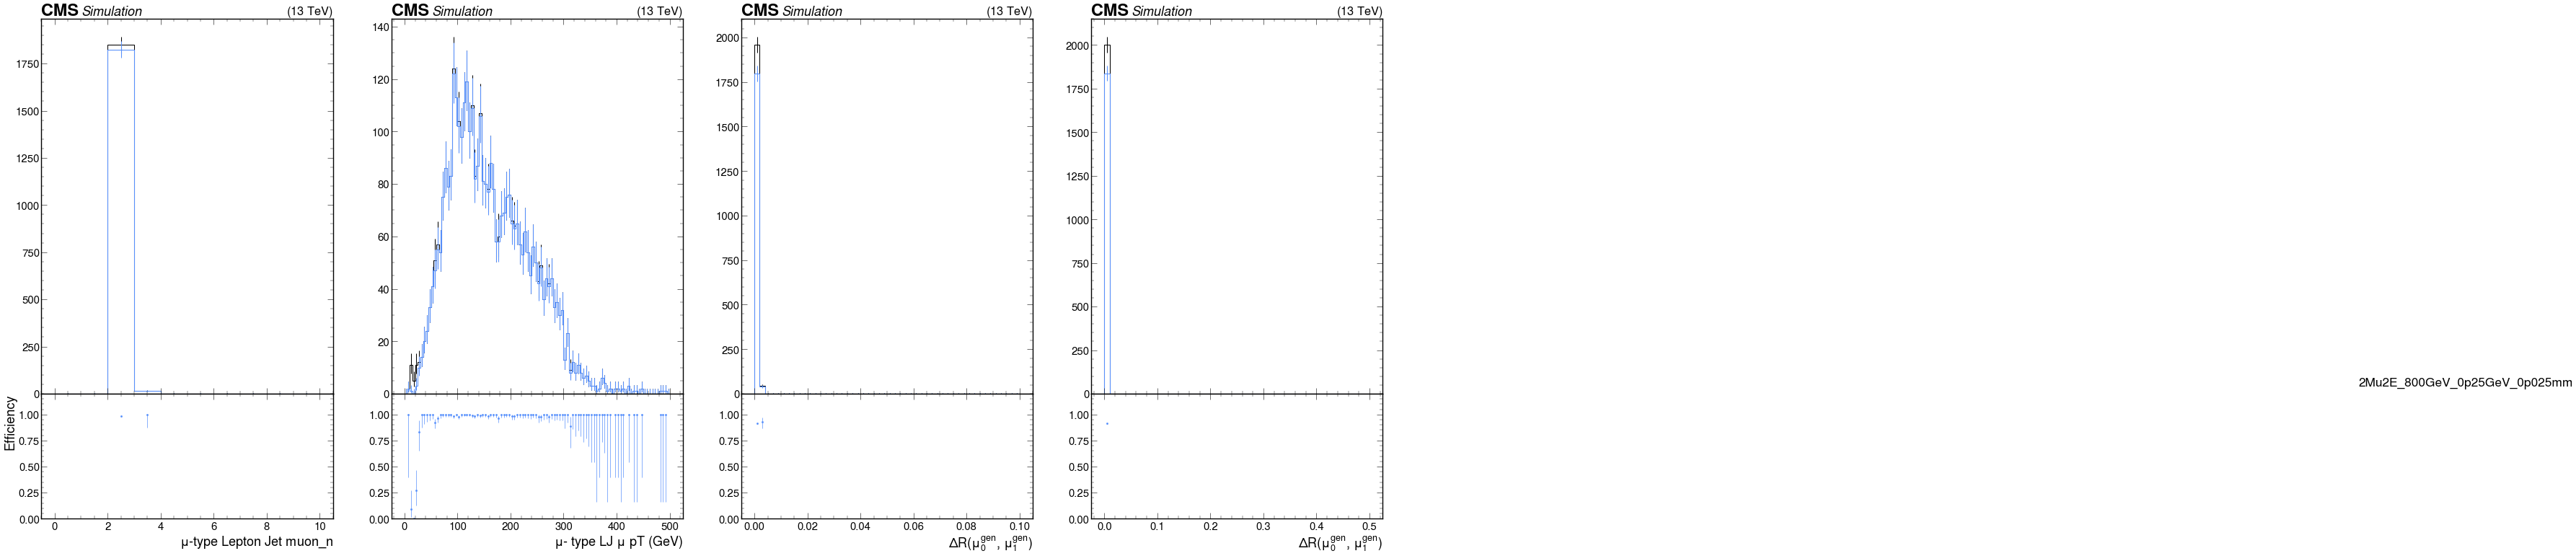

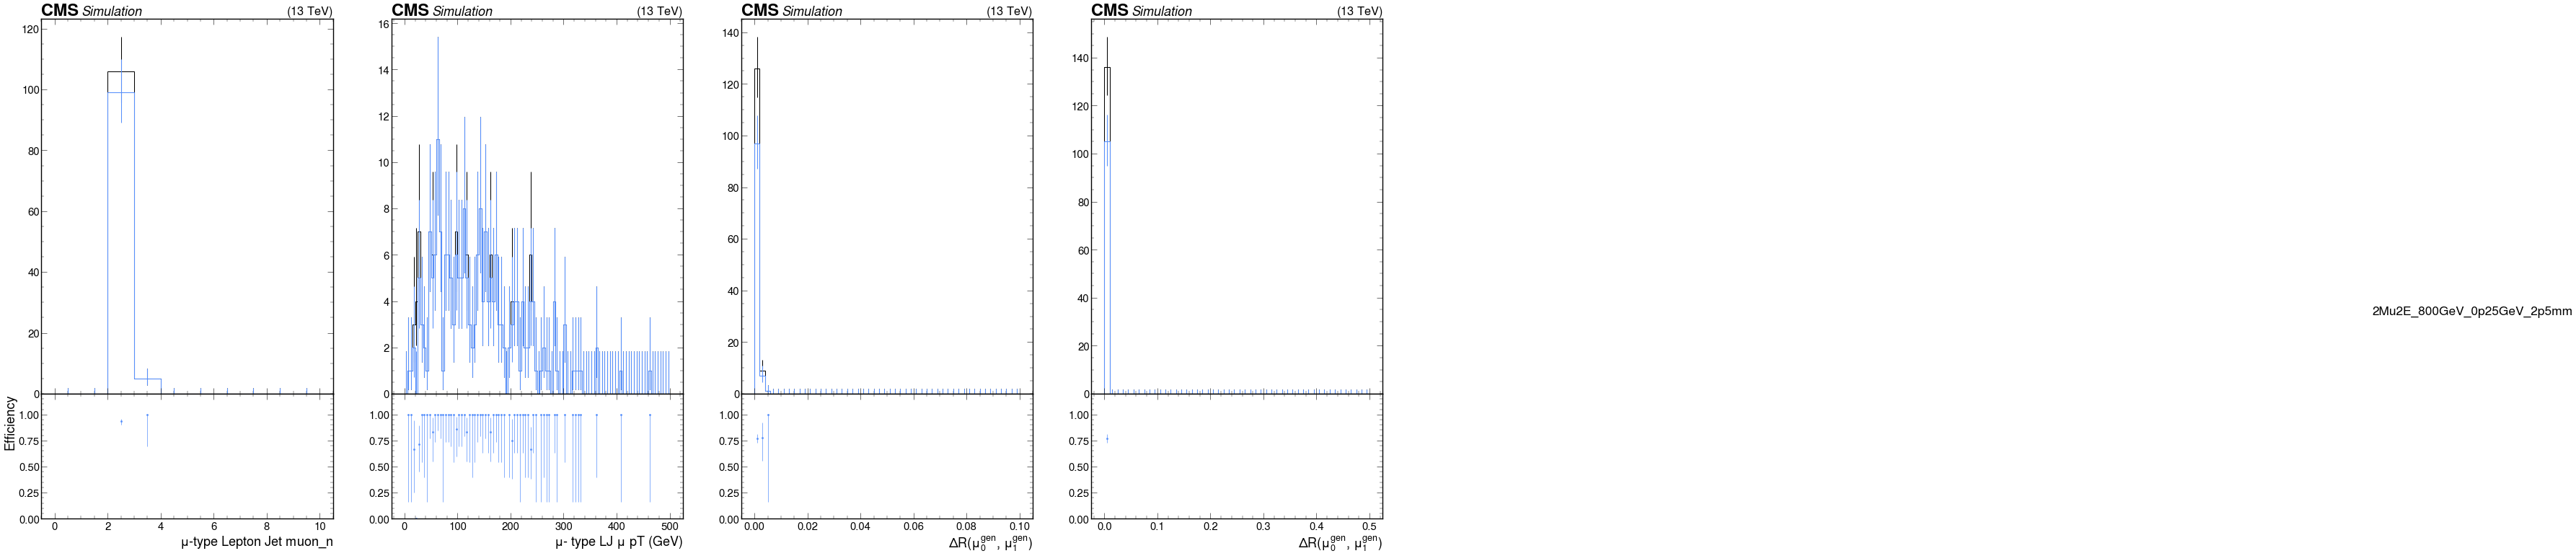

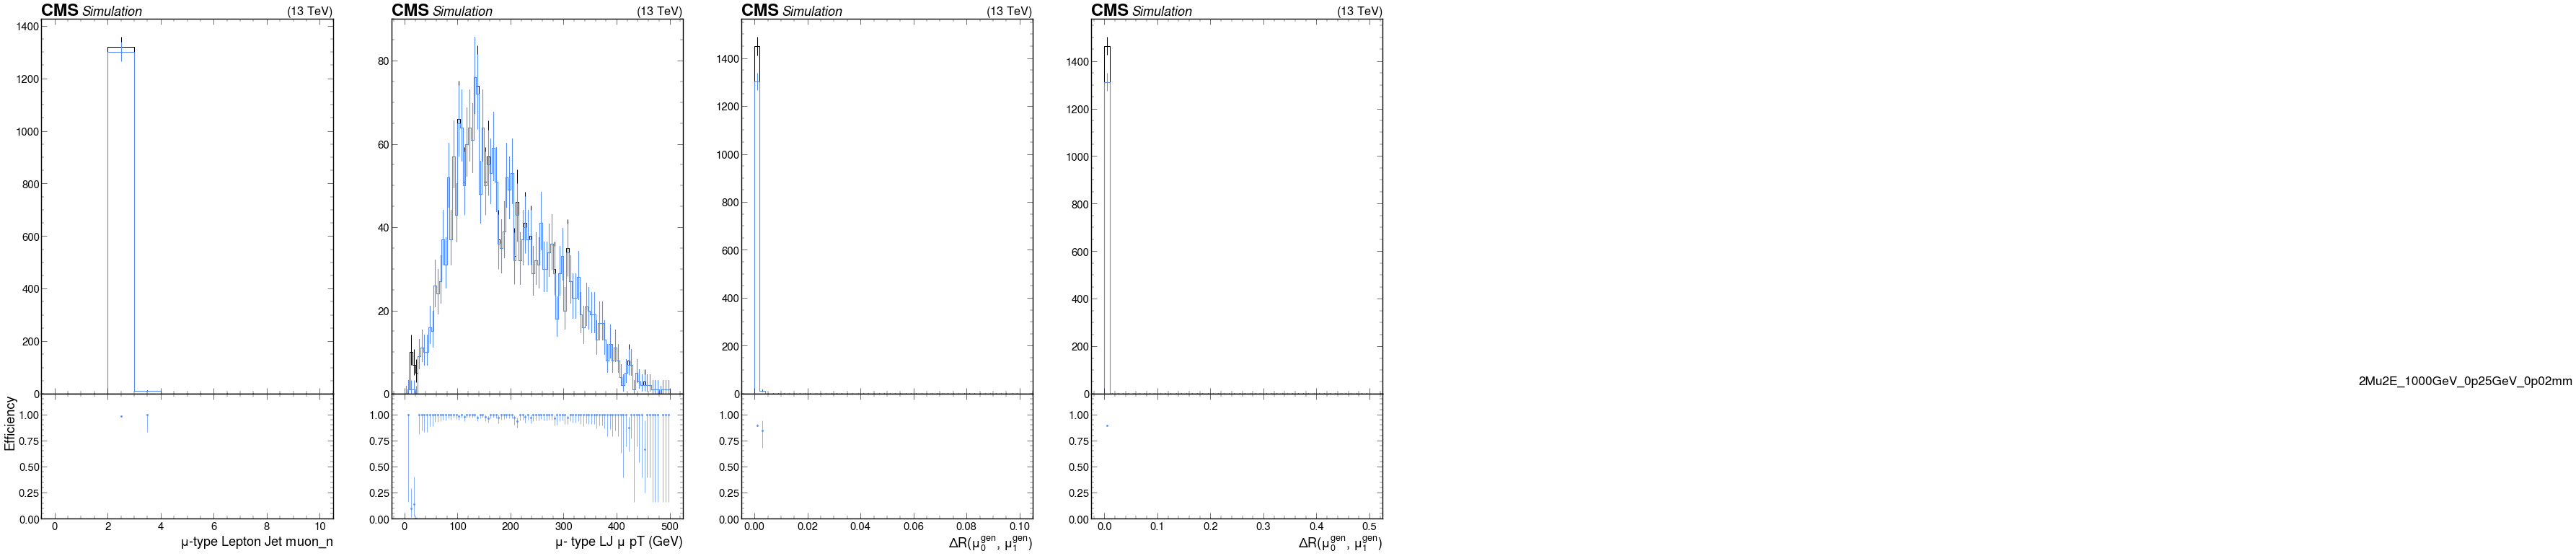

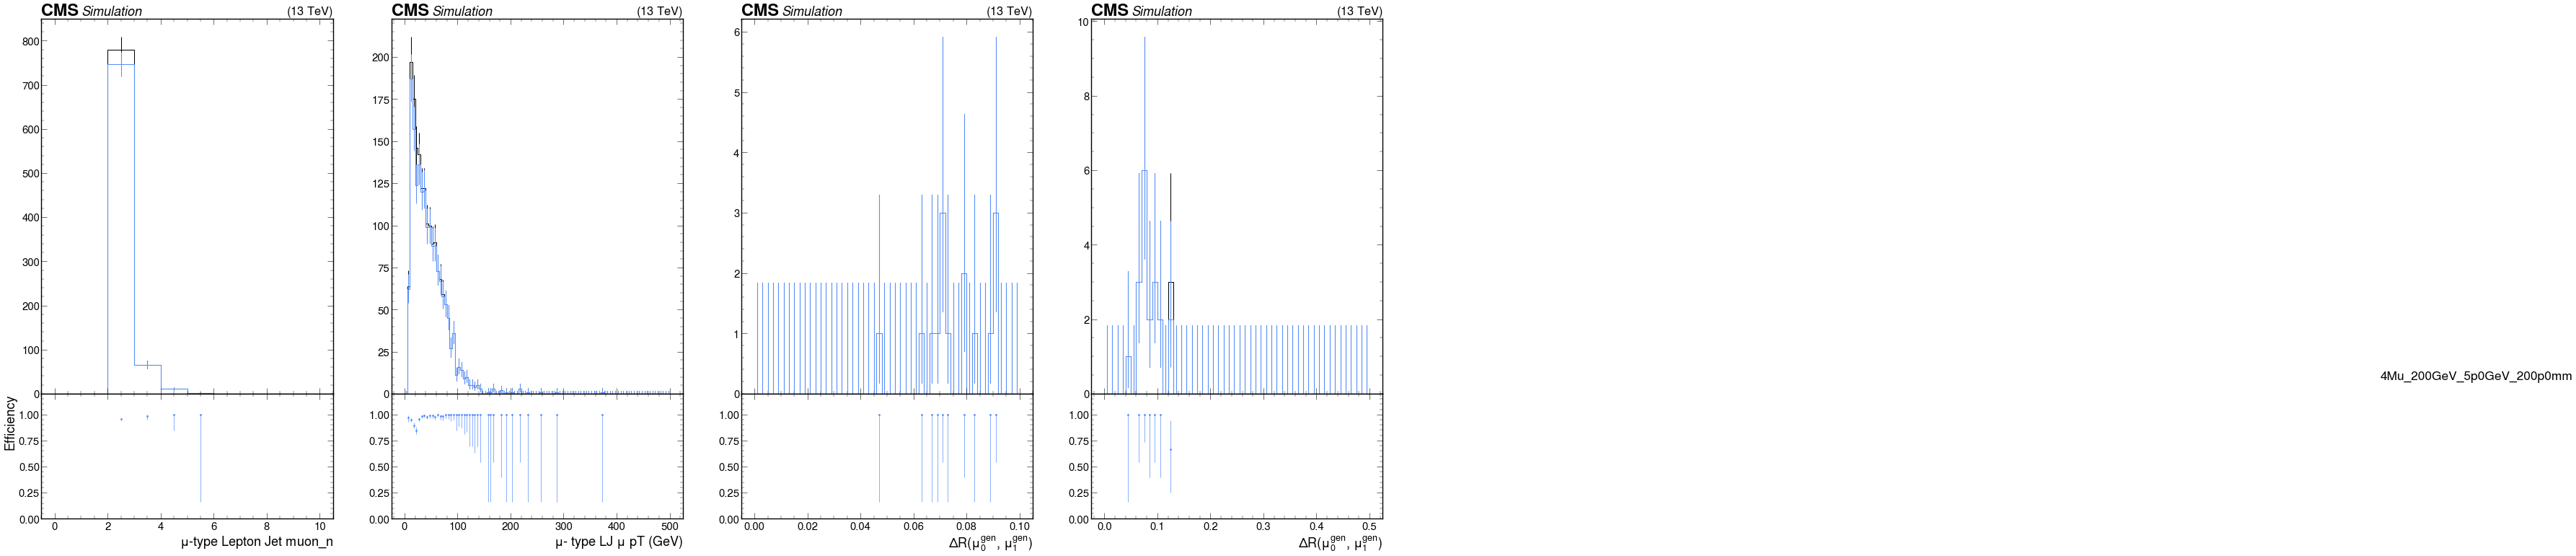

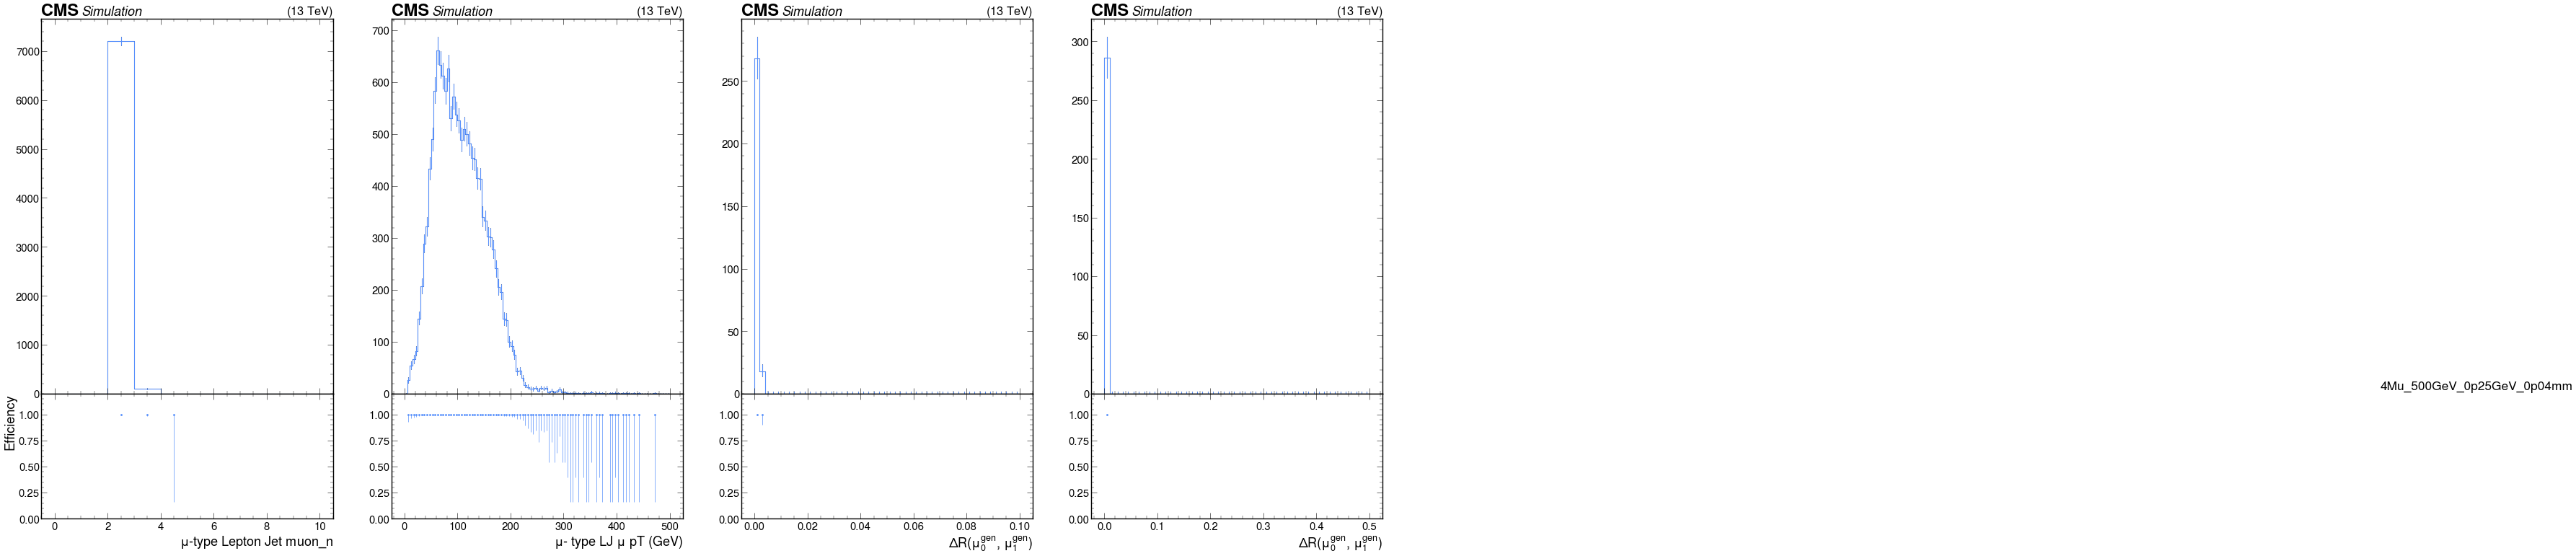

In [10]:
num_ch = "base"
denom_ch = "base_noMuPtCut"
plot_names = ["mu_lj_muonN","mu_lj_muon_pt","genMu_genMu_dR_XLowRange","genMu_genMu_dR_lowRange" ]
for sample in samples:
    nums = [out[sample]["hists"][plot_name][ num_ch, :] for plot_name in plot_names]
    denoms = [out[sample]["hists"][plot_name][ denom_ch, :] for plot_name in plot_names]

    plot_ratio_row(nums,denoms,sample)


The dR plots are the interesting ones here. For the cases where there is some dR spread, the efficiency is worse for higher dR since high dR -> lower boost -> lower pt

## Check if muon pt cut sculpts the gen pt or lxy distributions

Conclusions that you can check in the plots below: 
- efficiency vs gen pt matches the trends discussed above for lepton jet pt
- I don't observe strong trends vs gen lxy like I might have expected. For one sample, efficiency seems to fall off with increasing lxy (opposite what I expected) but that's not really supported by the rest of the plots

/tmp/ipykernel_3113/3524104532.py:89: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


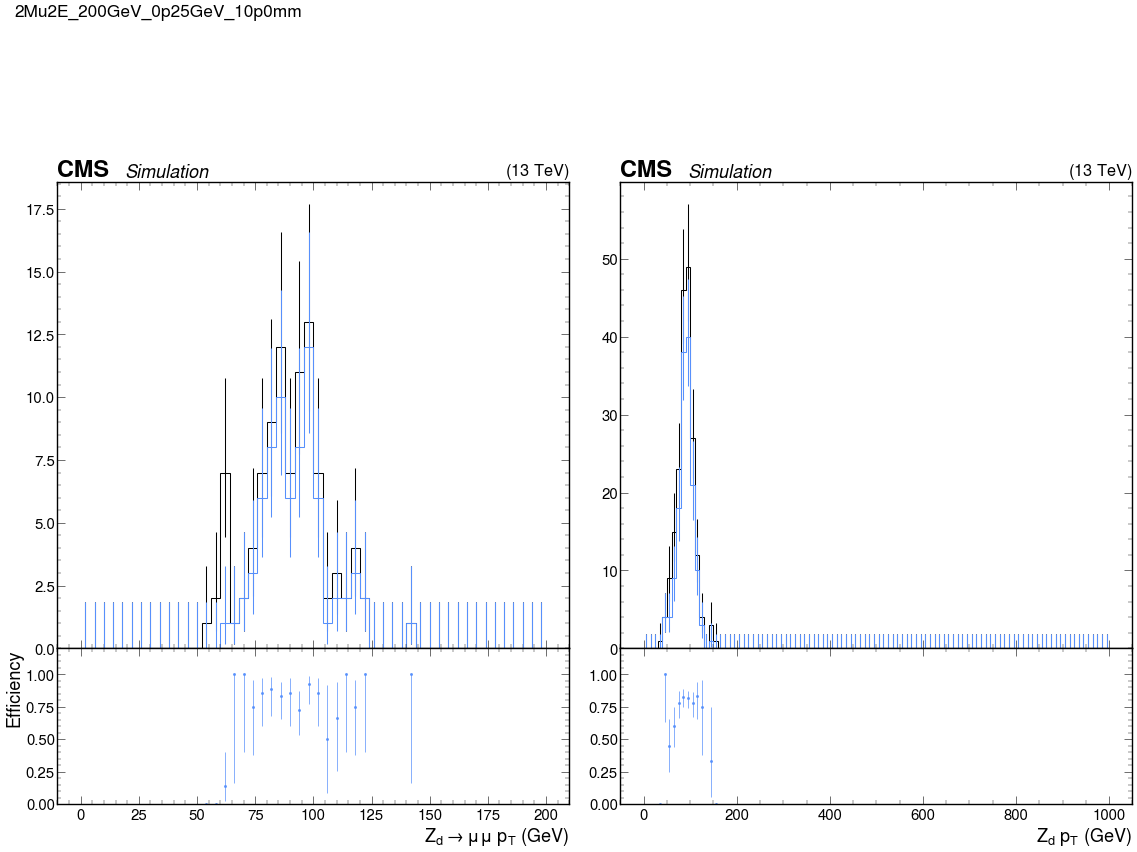

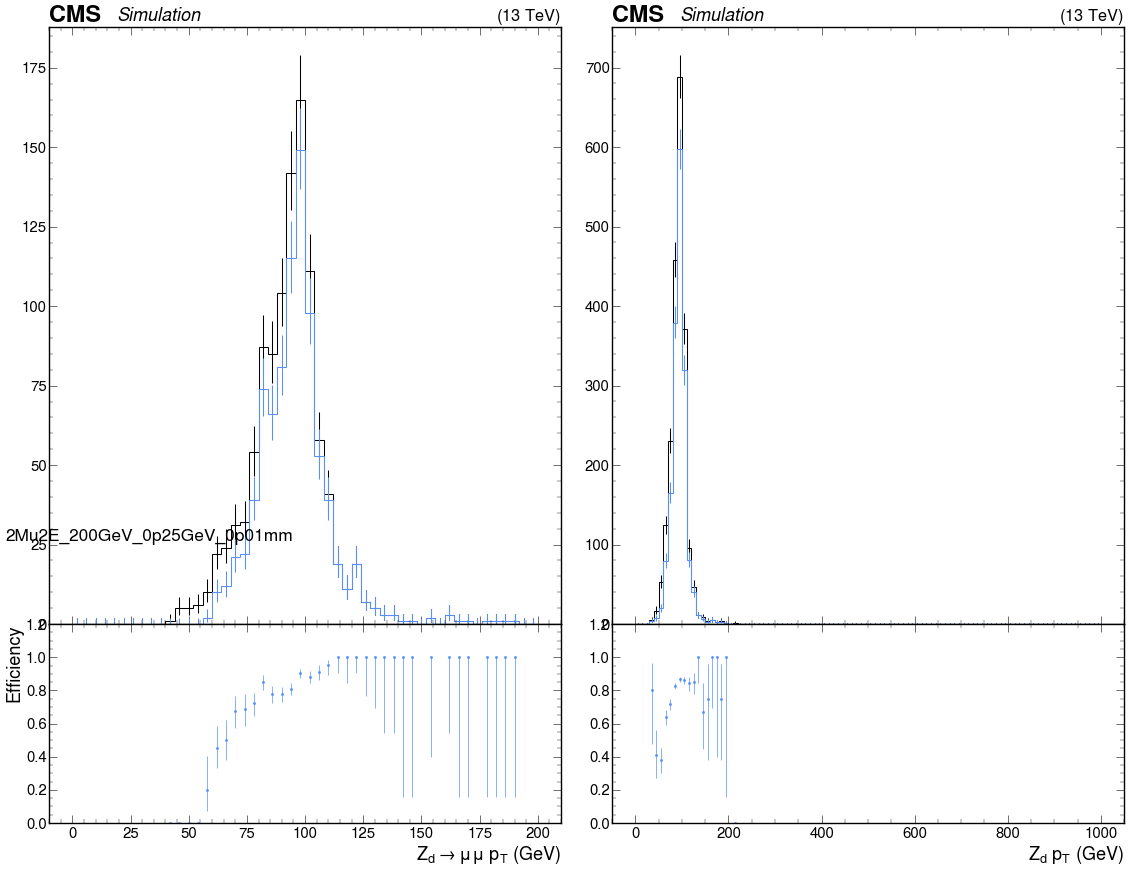

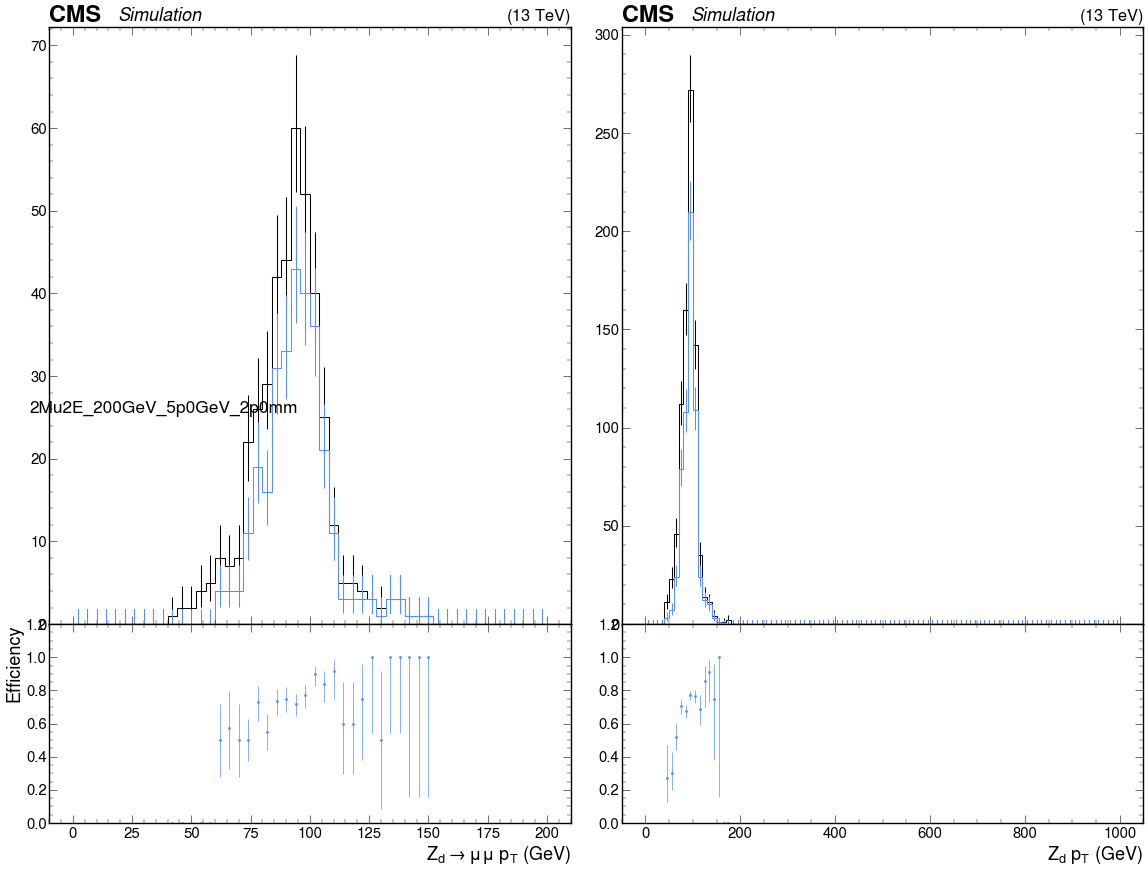

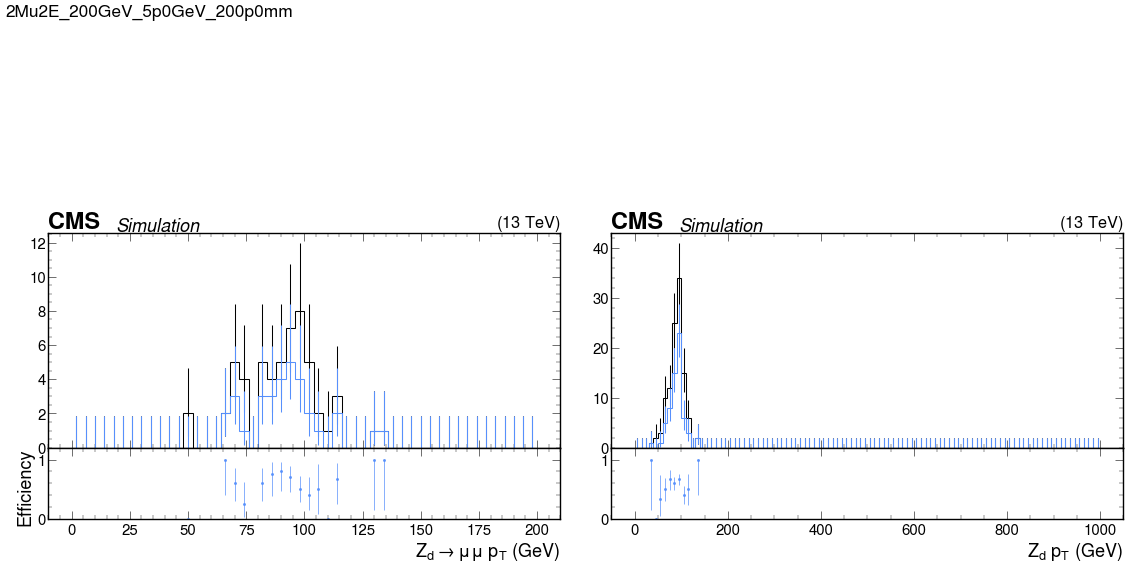

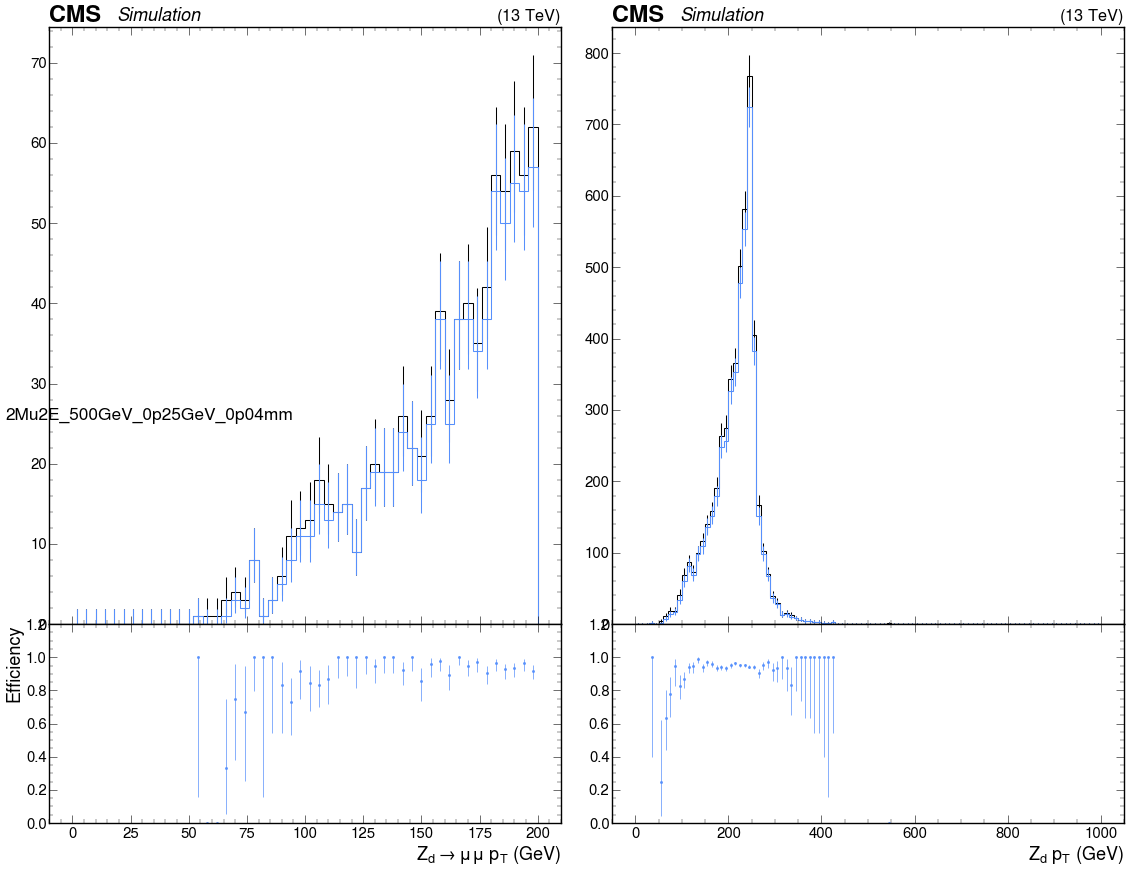

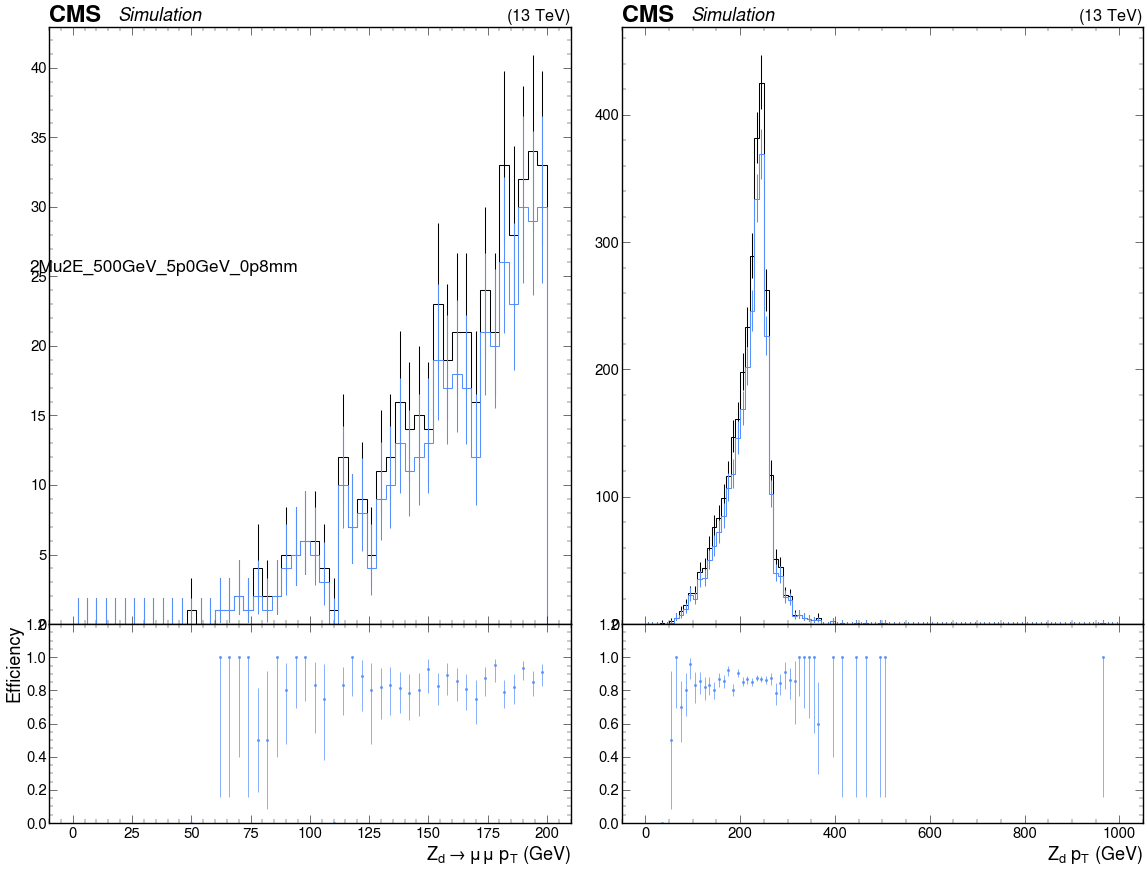

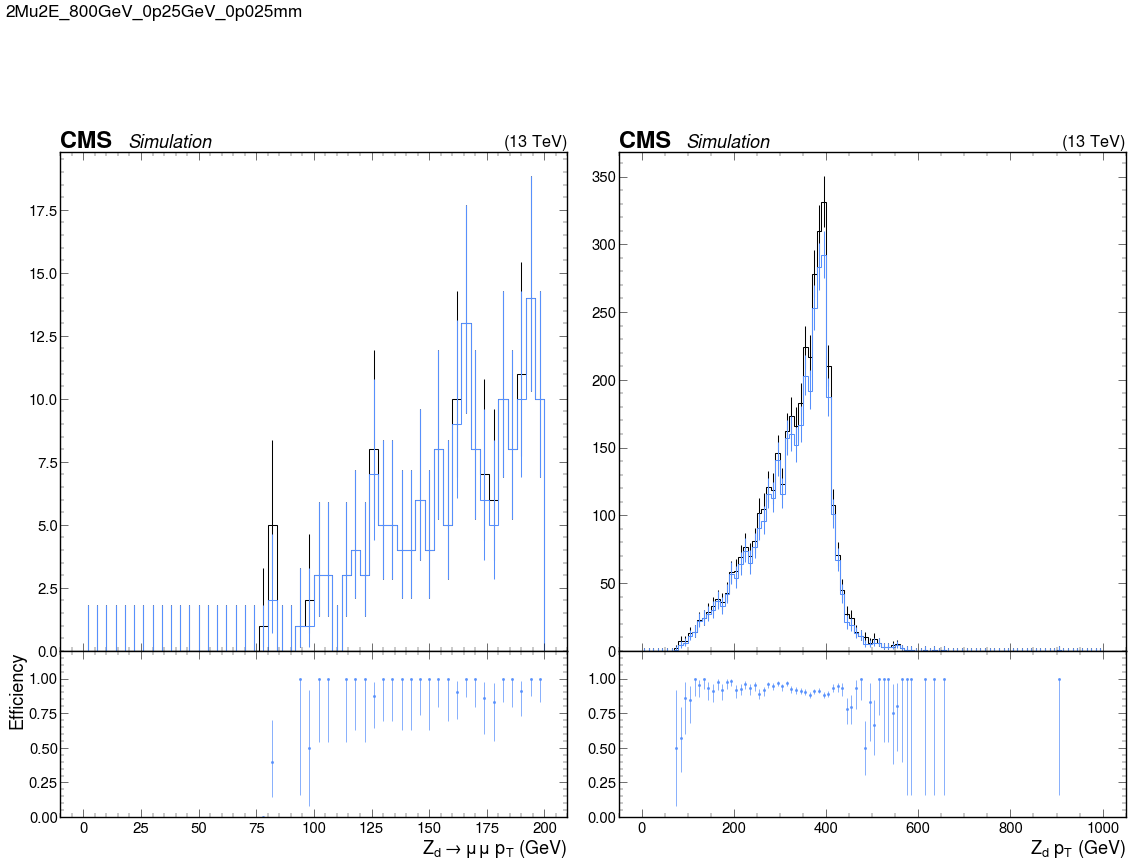

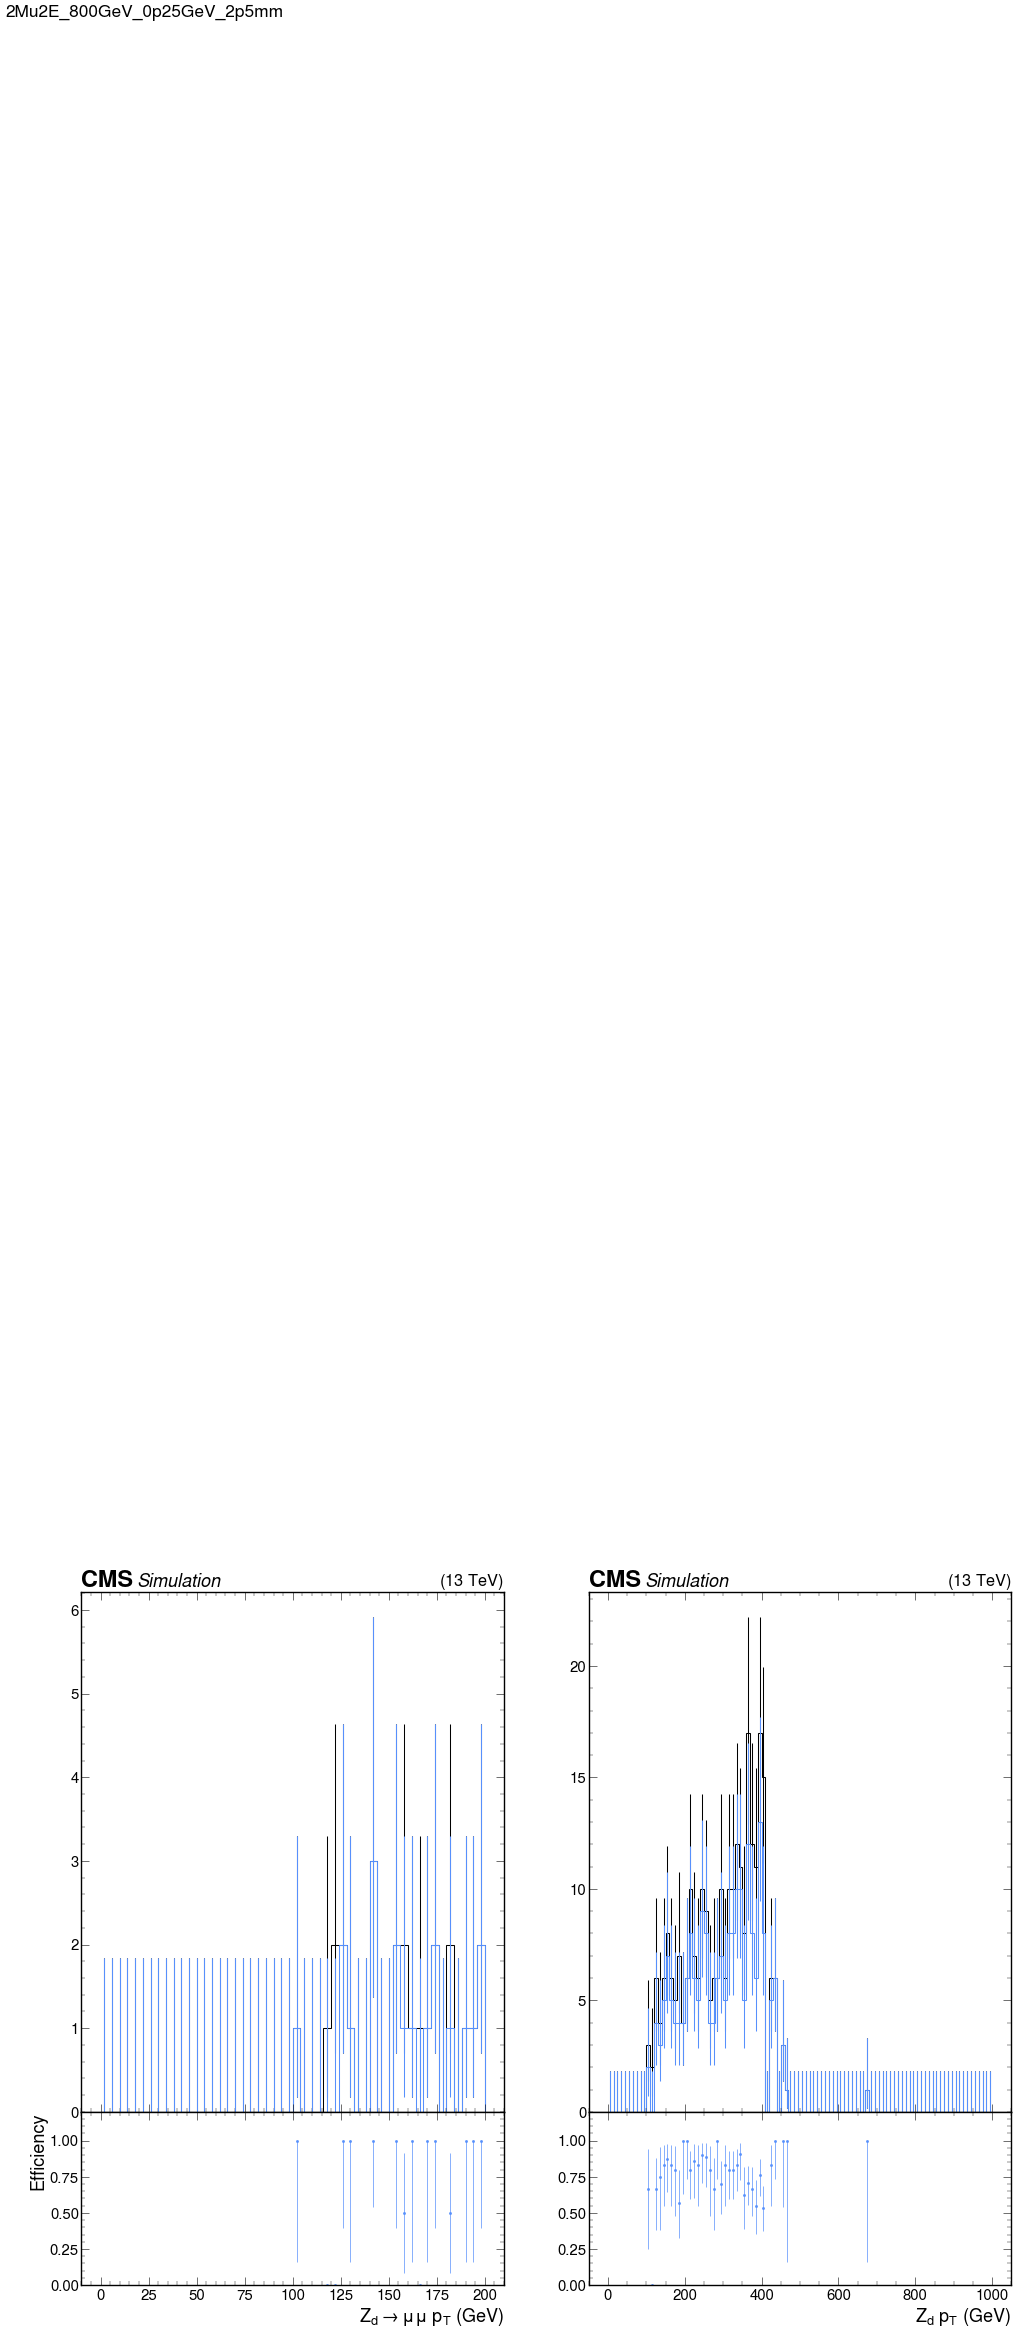

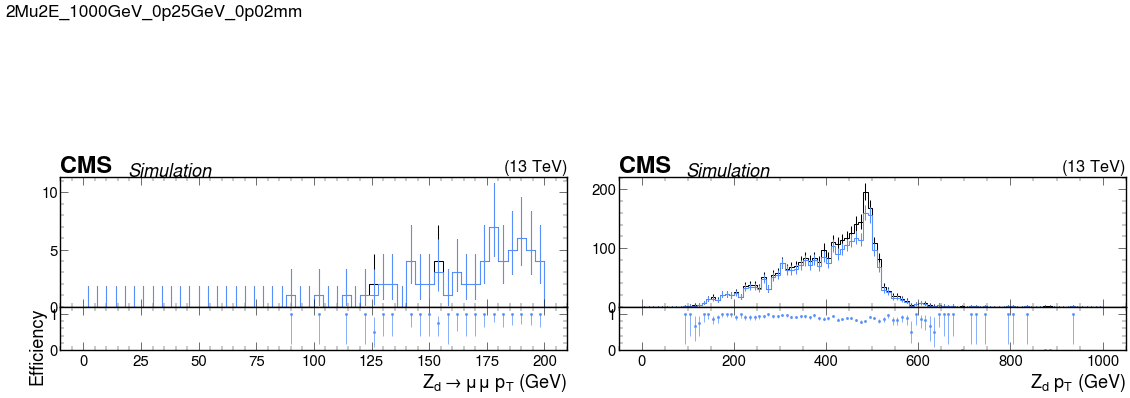

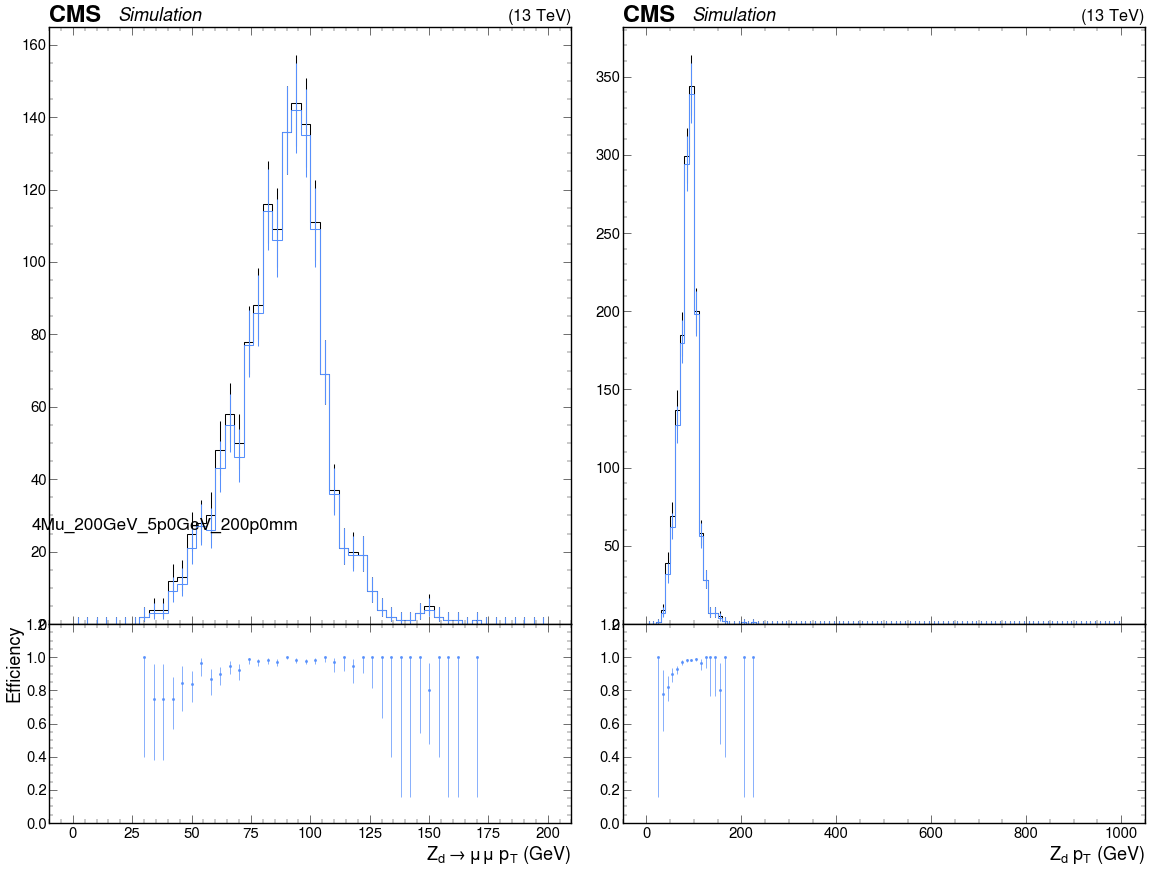

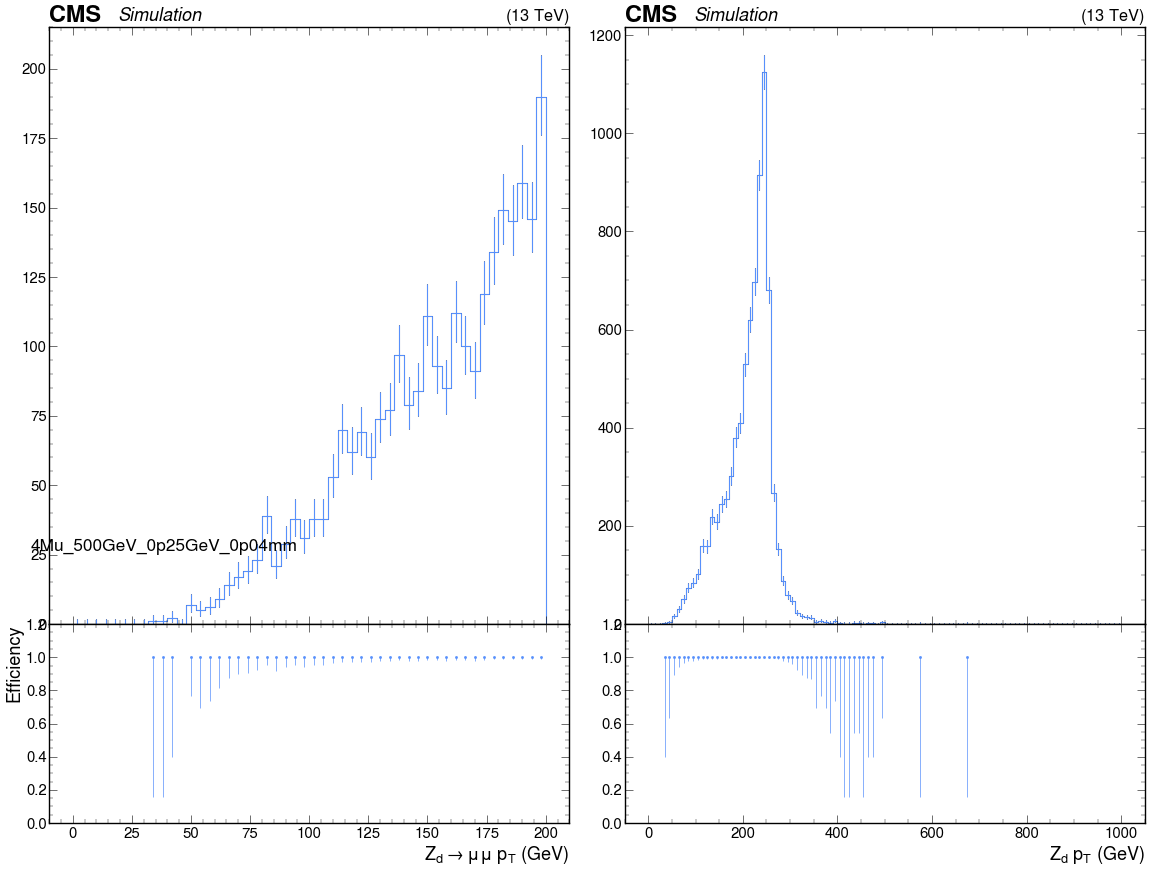

In [11]:
num_ch = "base"
denom_ch = "base_noMuPtCut"
plot_names = ["genAs_toMu_pt","genAs_pt"]
#plot_names = ["genAs_toMu_pt","genAs_pt","genAs_toMu_lxy","genAs_lxy","genAs_toMu_lxy_lowRange","genAs_lxy_lowRange" ]
for sample in samples:
    nums = [out[sample]["hists"][plot_name][ num_ch, :] for plot_name in plot_names]
    denoms = [out[sample]["hists"][plot_name][ denom_ch, :] for plot_name in plot_names]

    plot_ratio_row(nums,denoms,sample)


/tmp/ipykernel_3113/3524104532.py:89: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


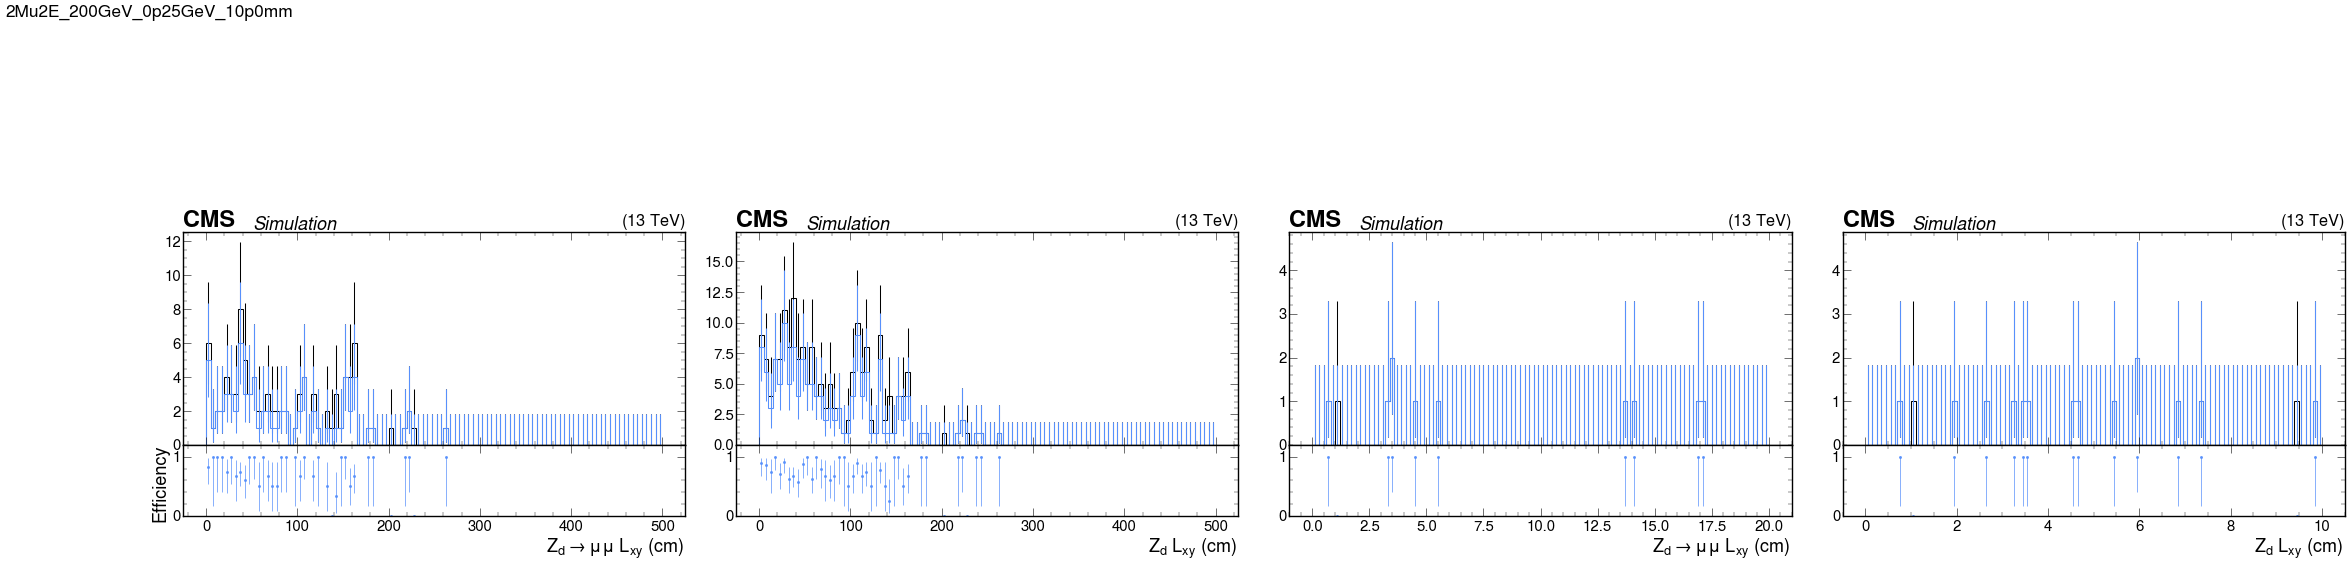

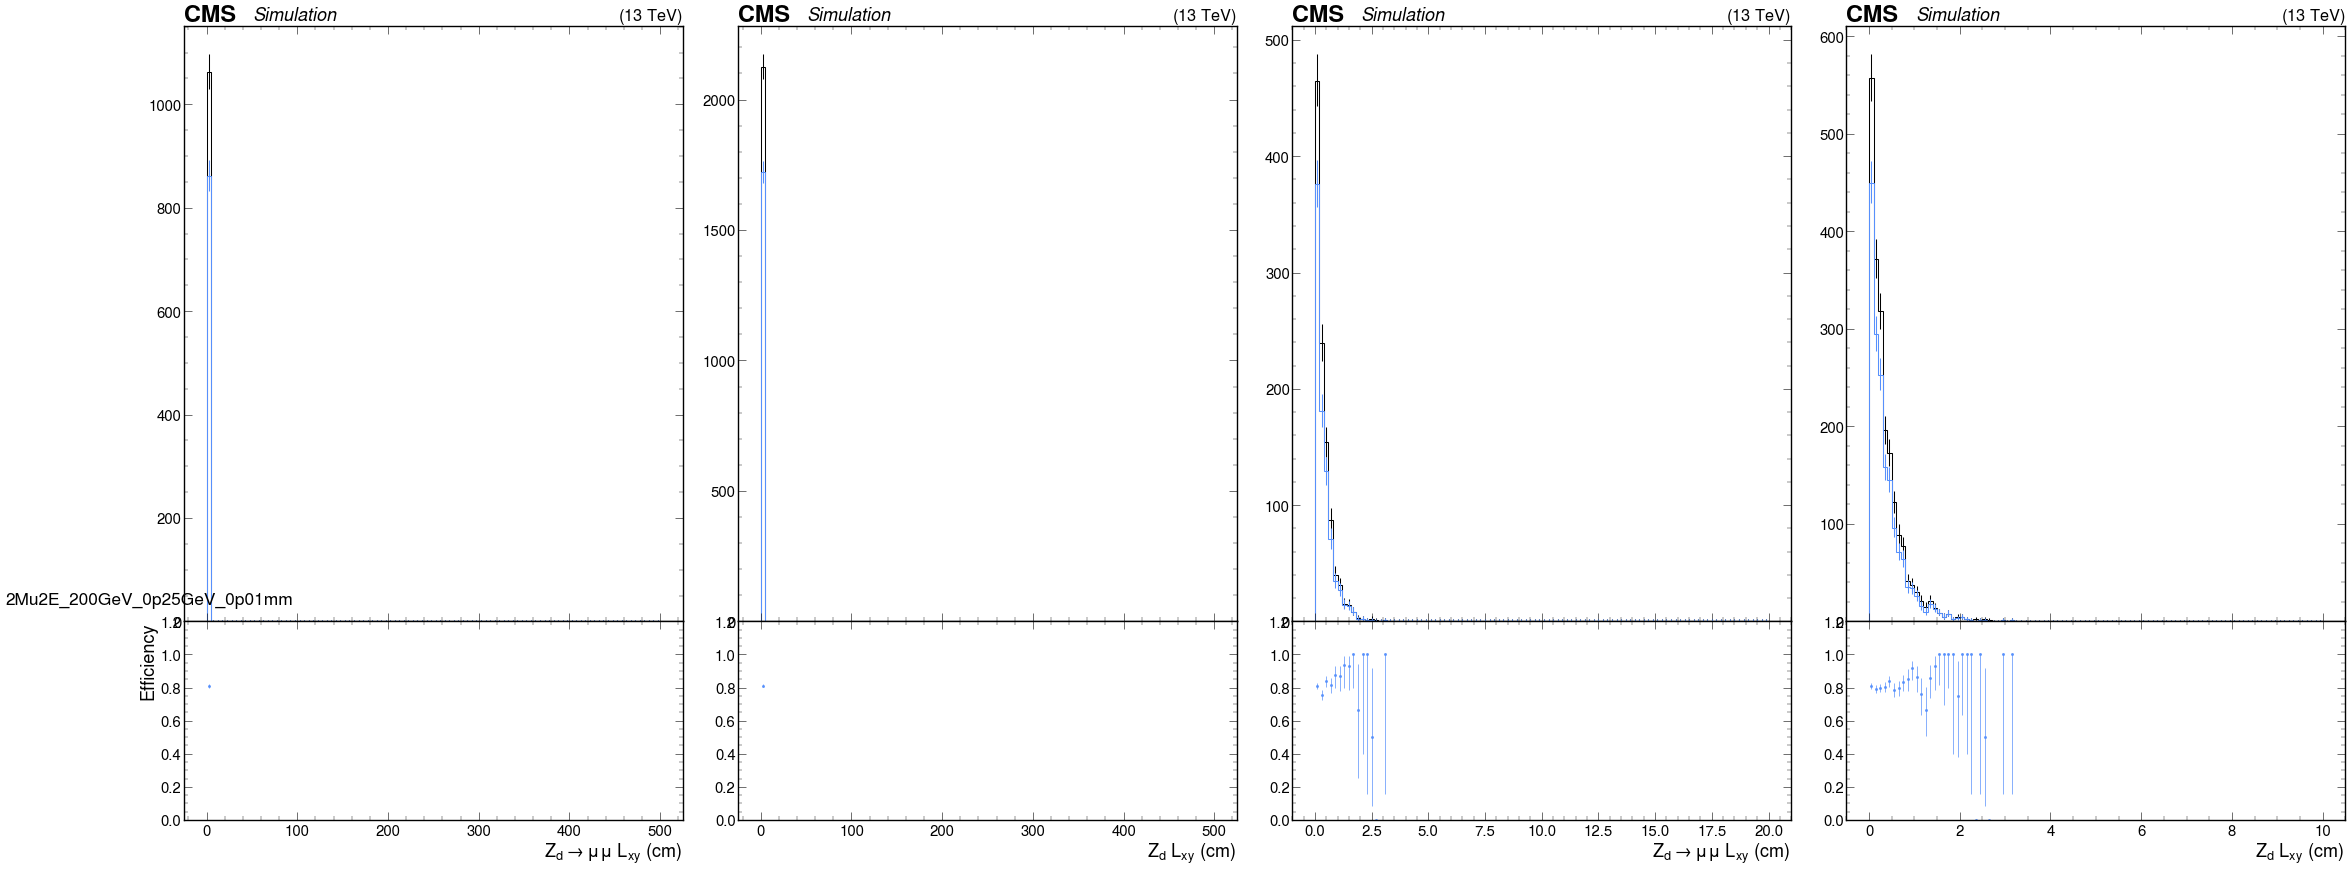

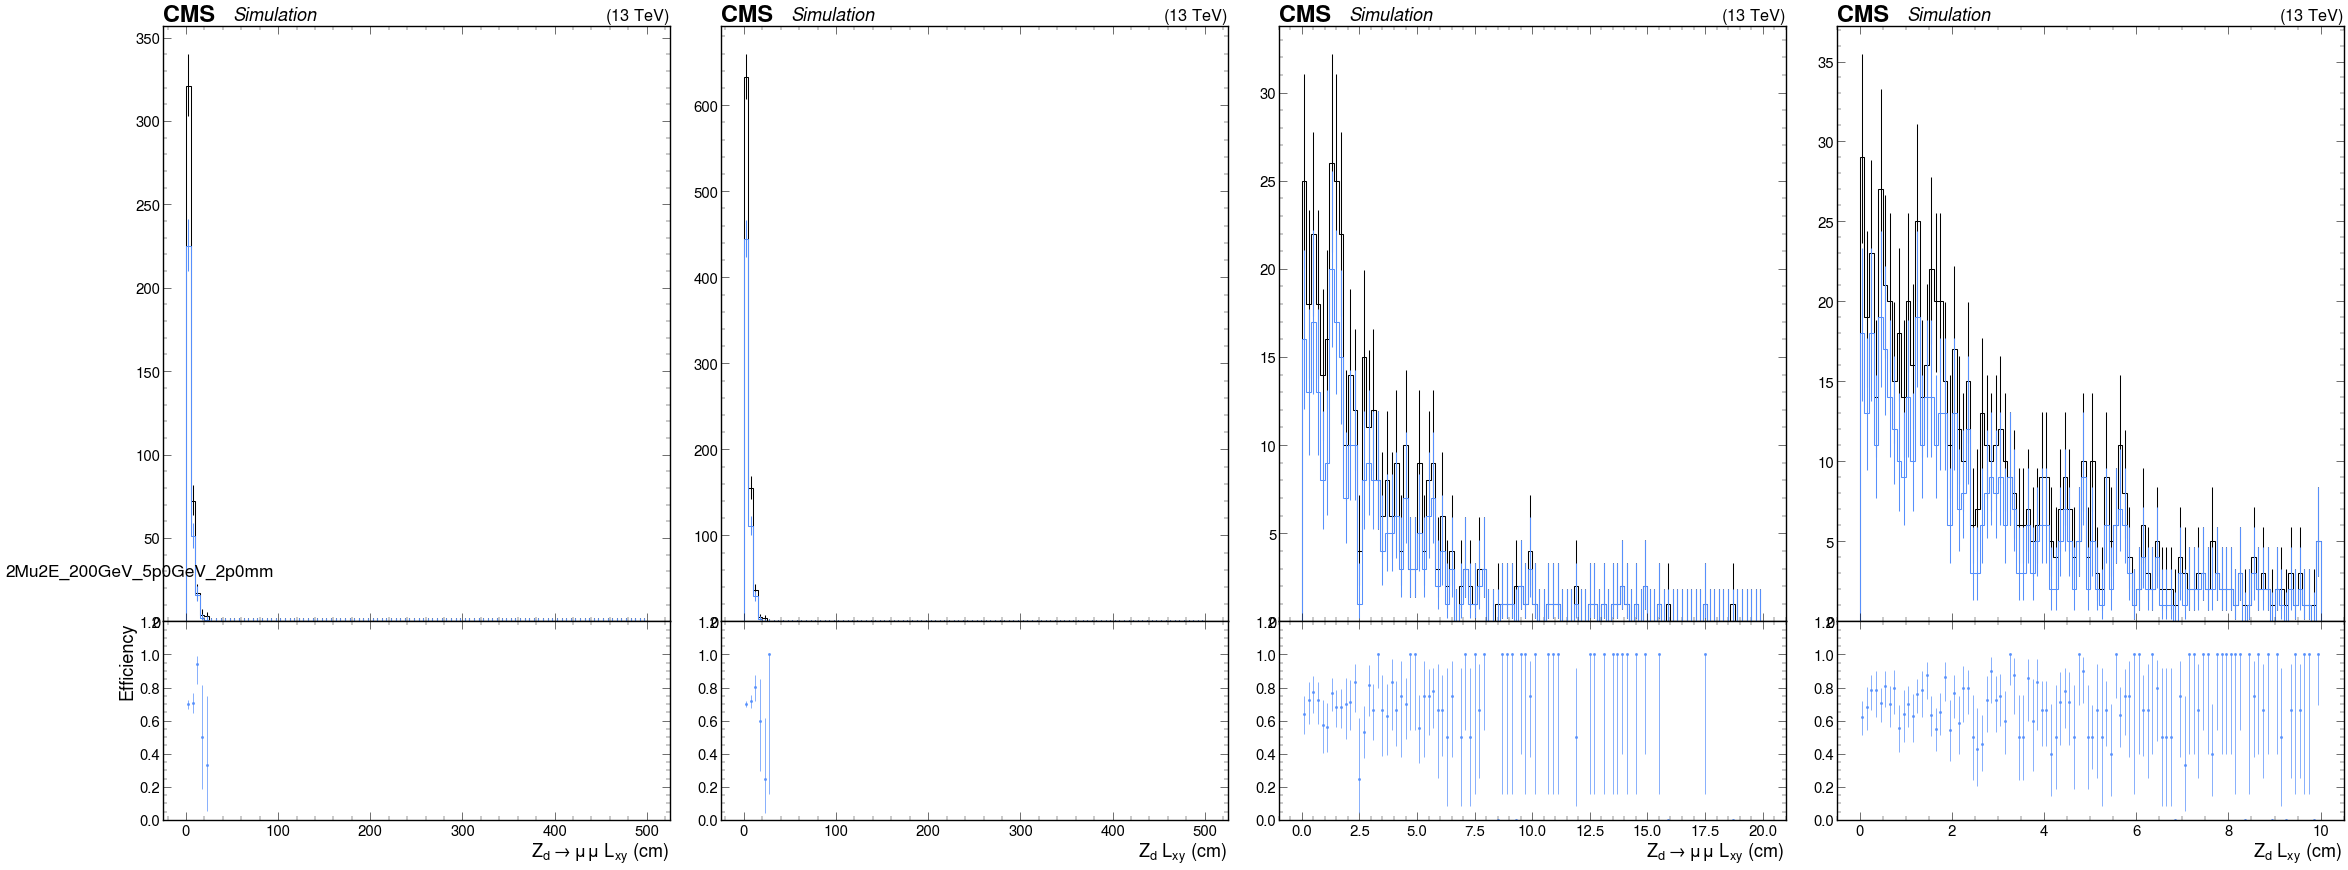

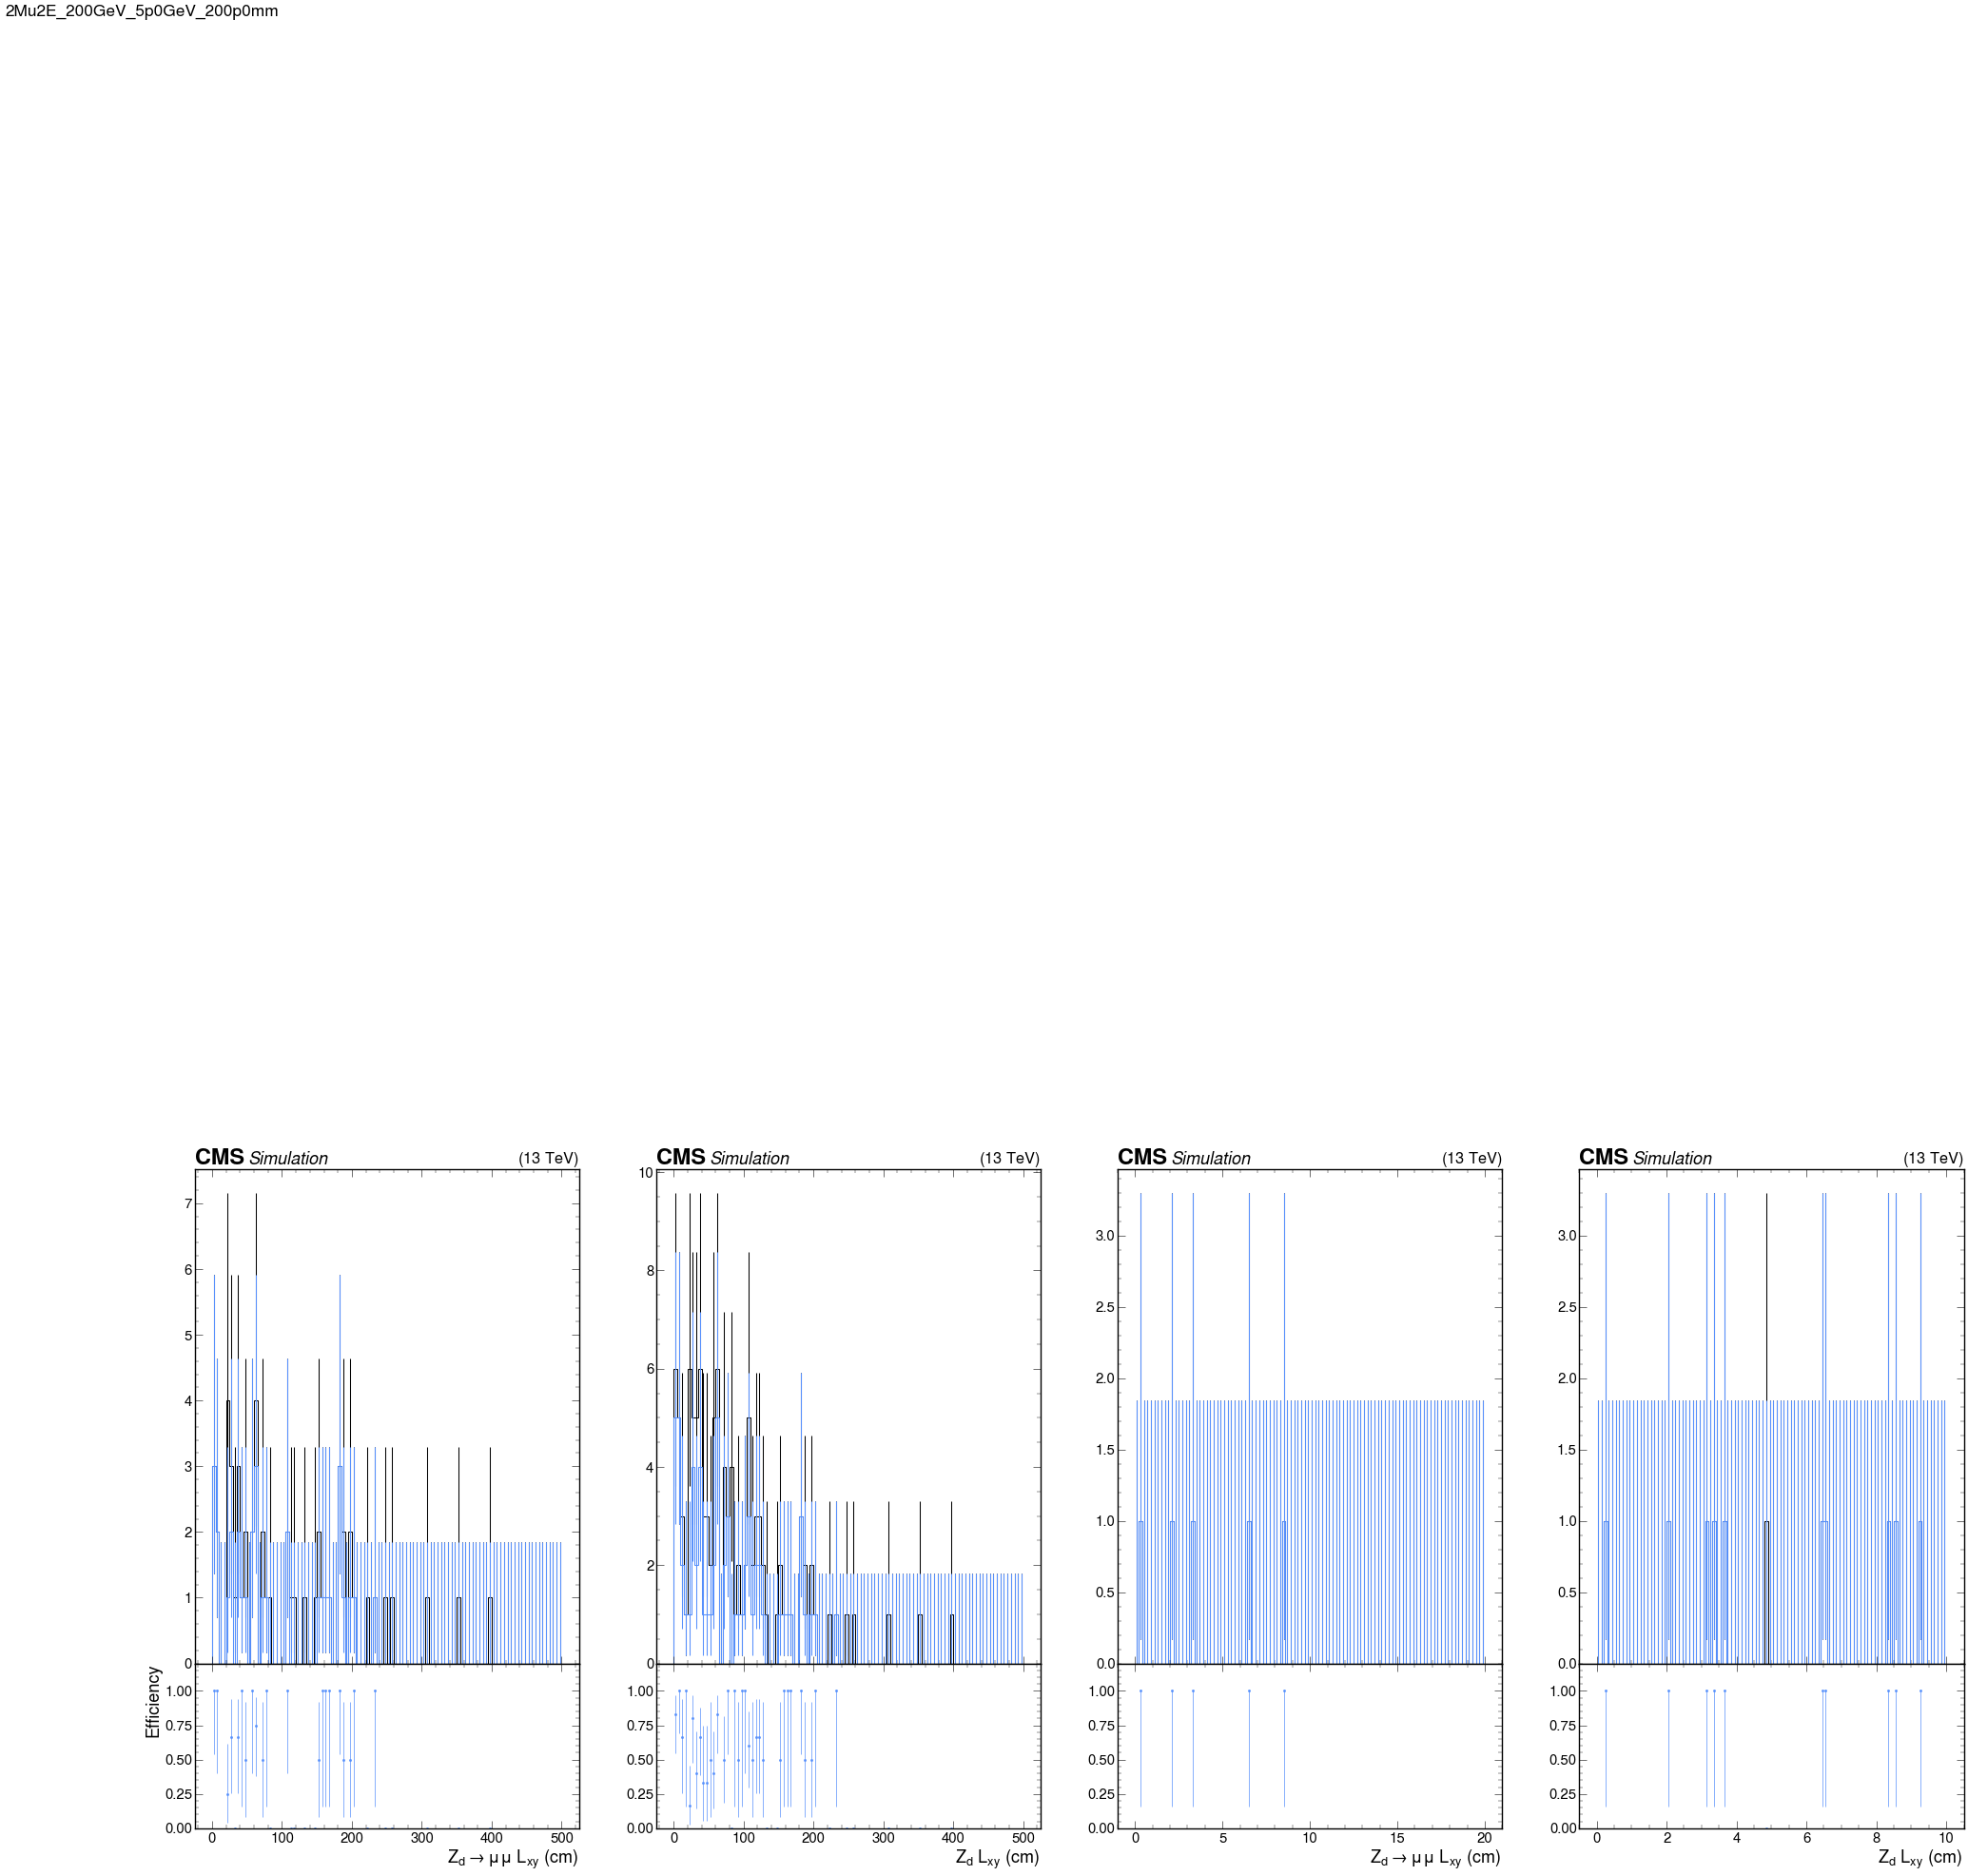

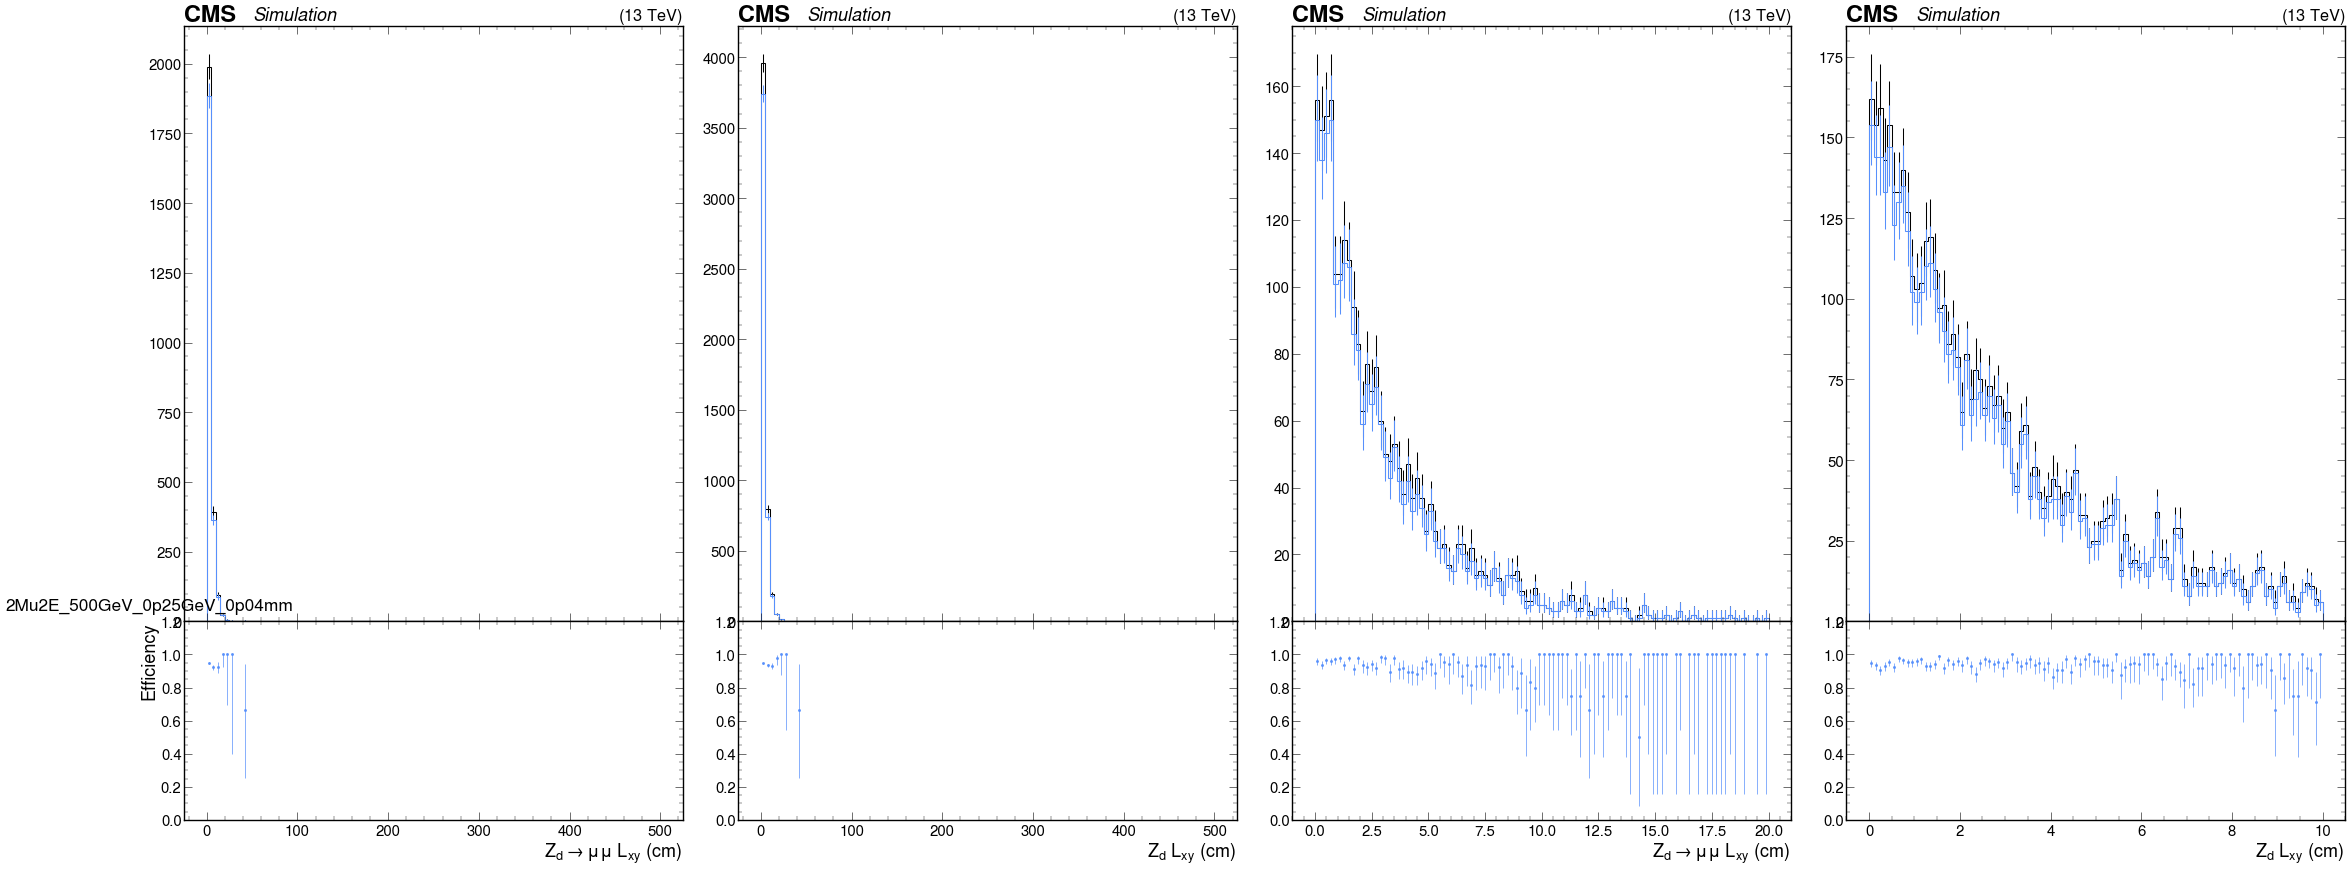

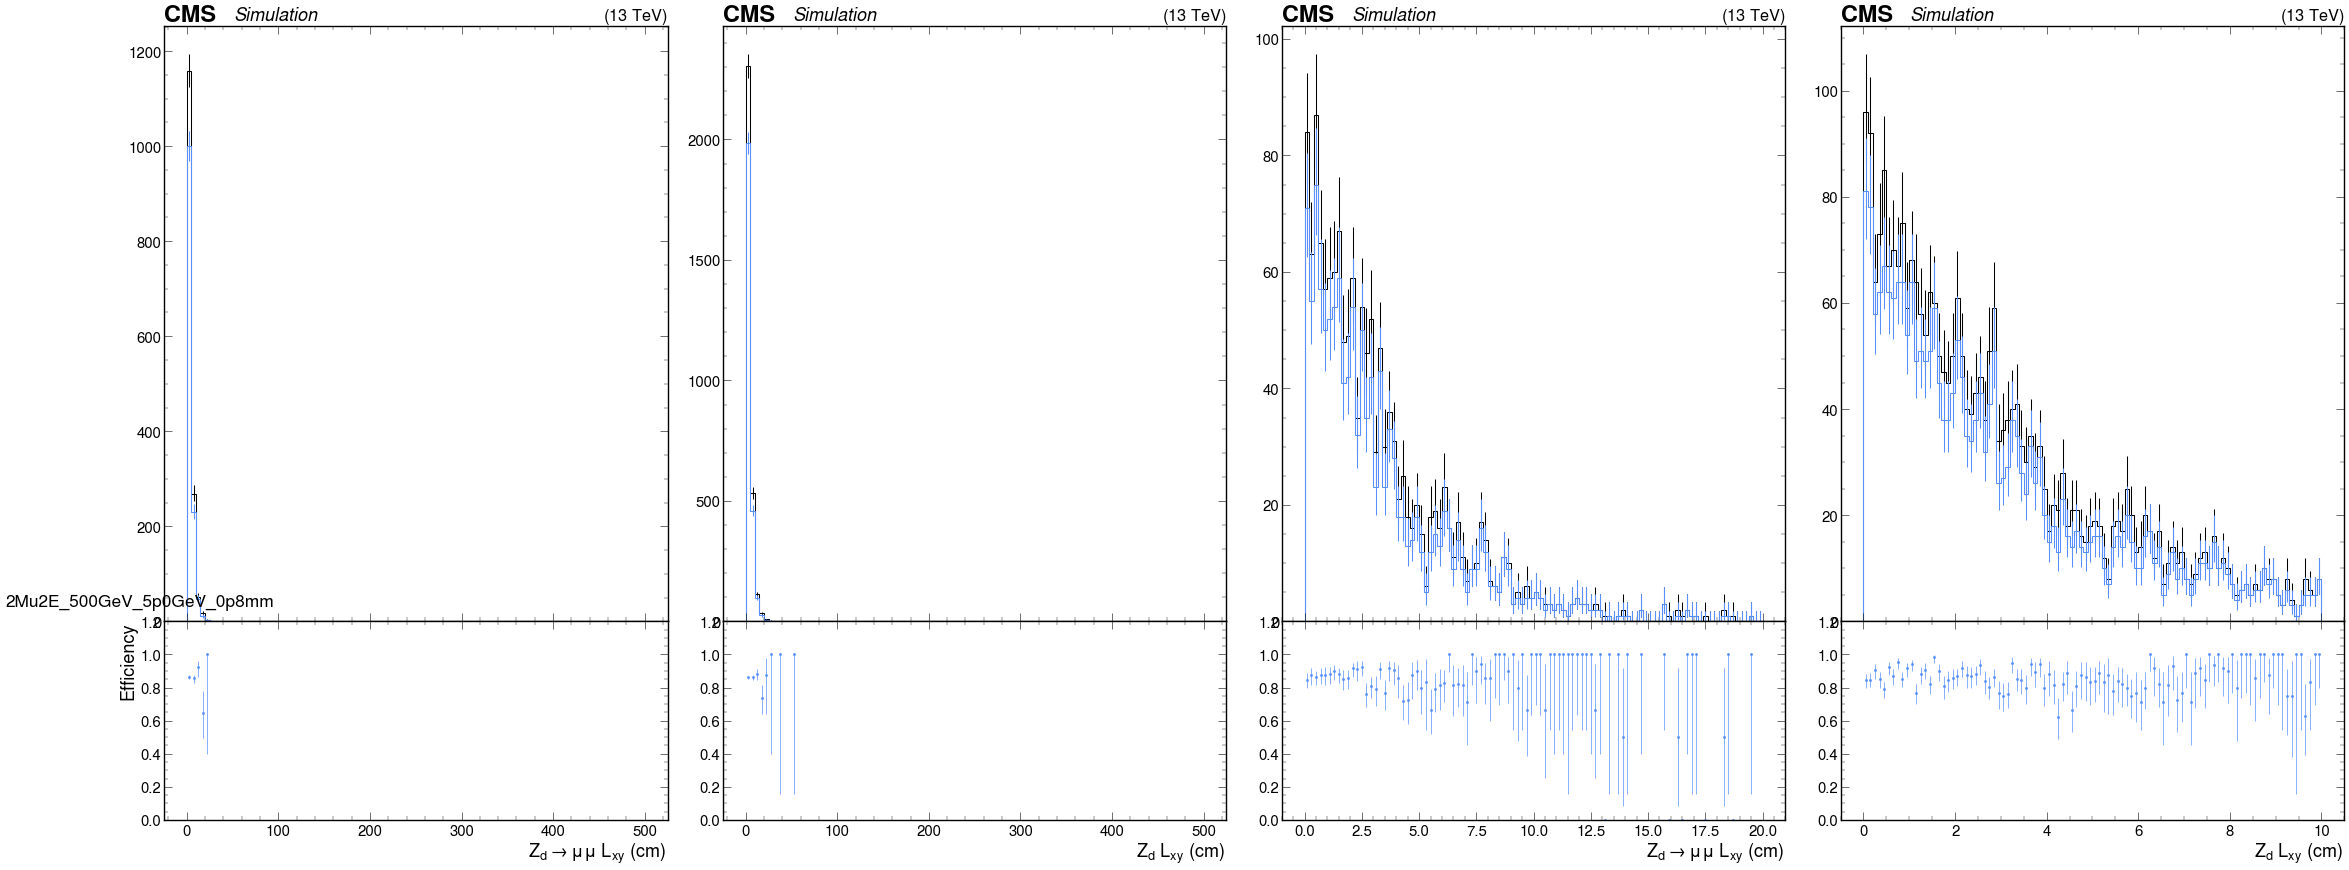

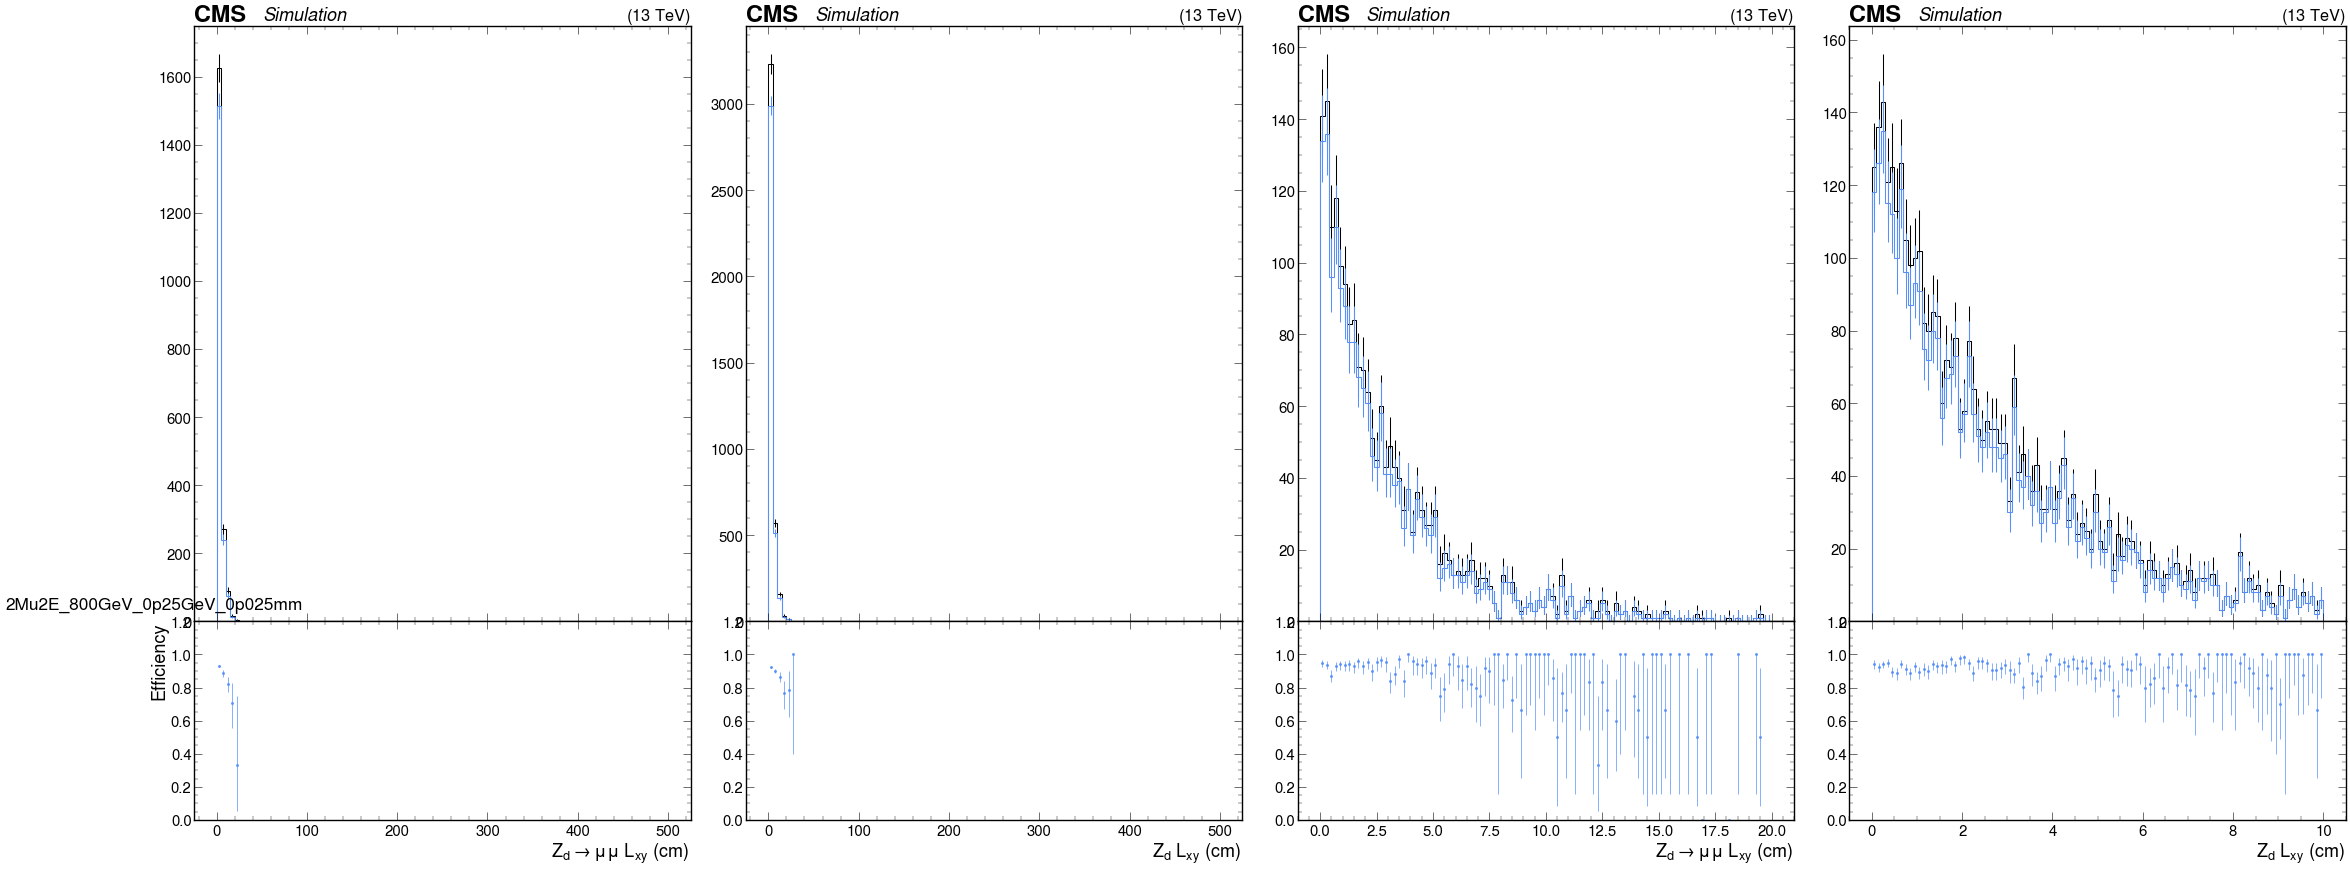

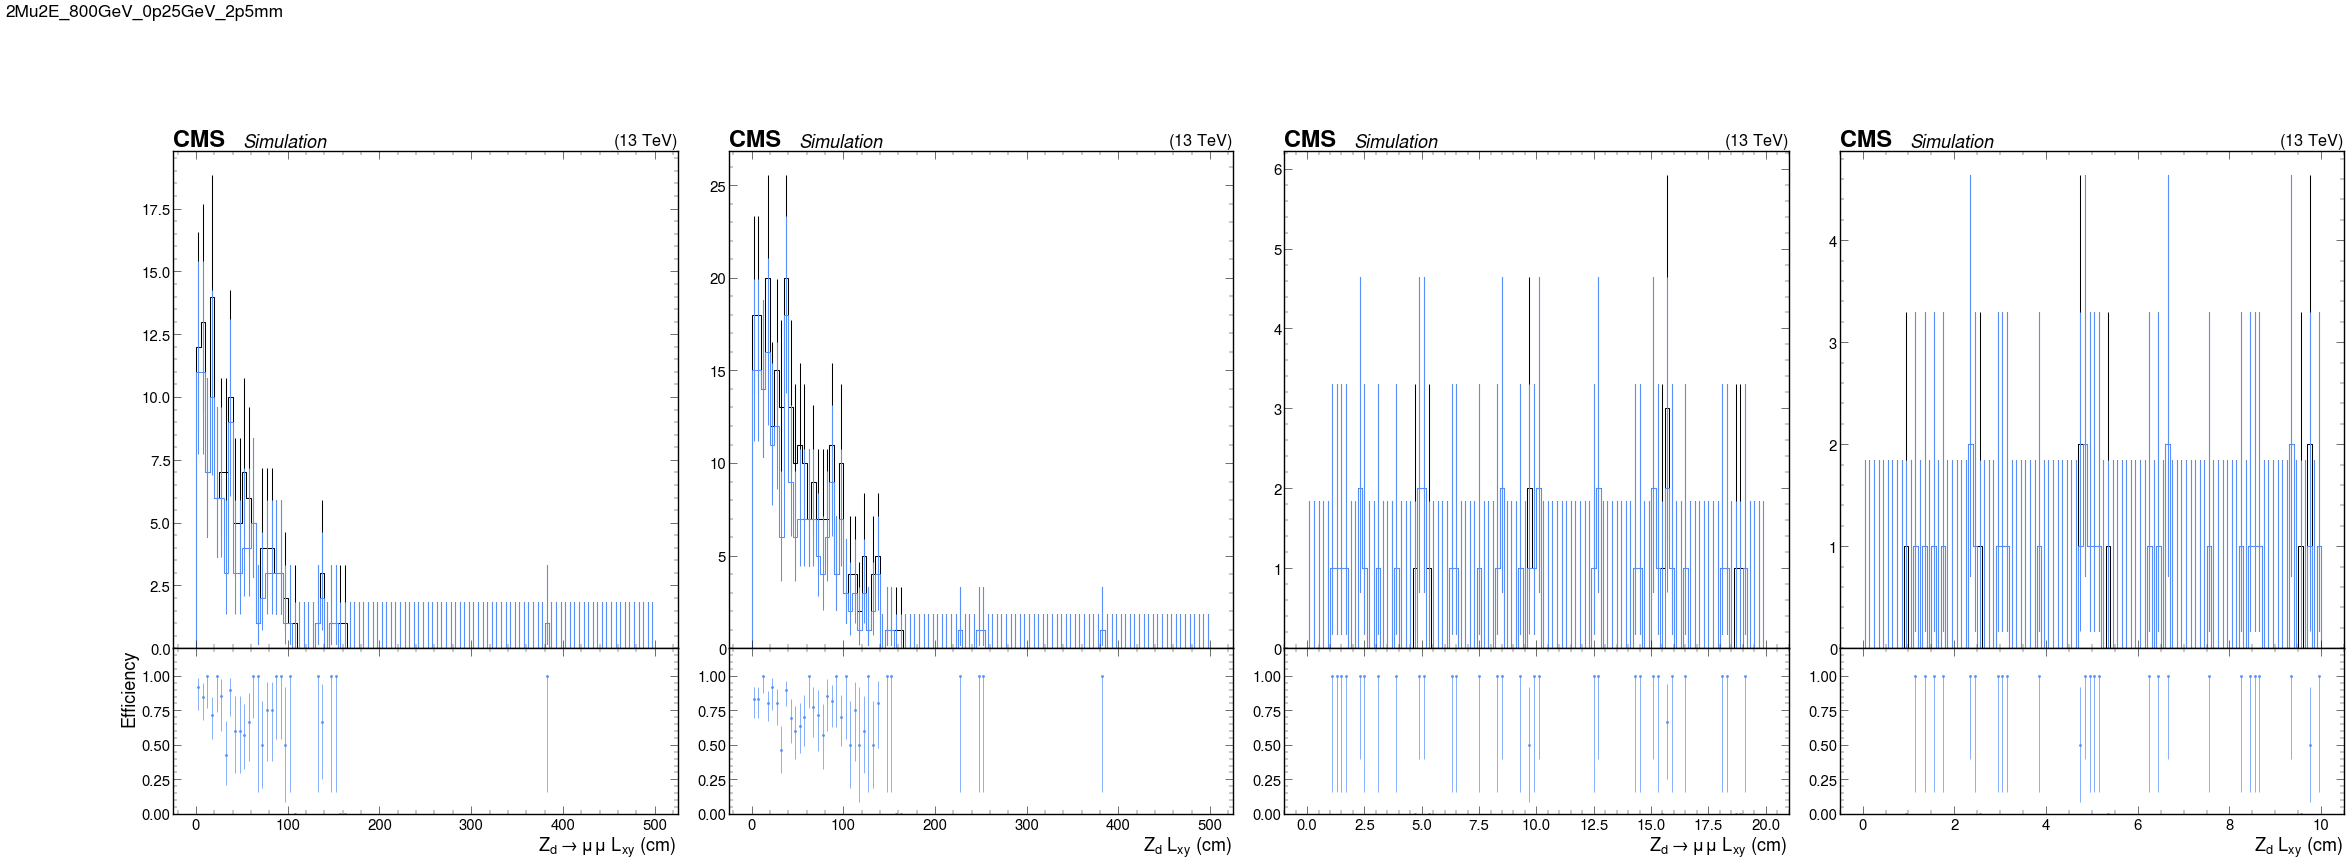

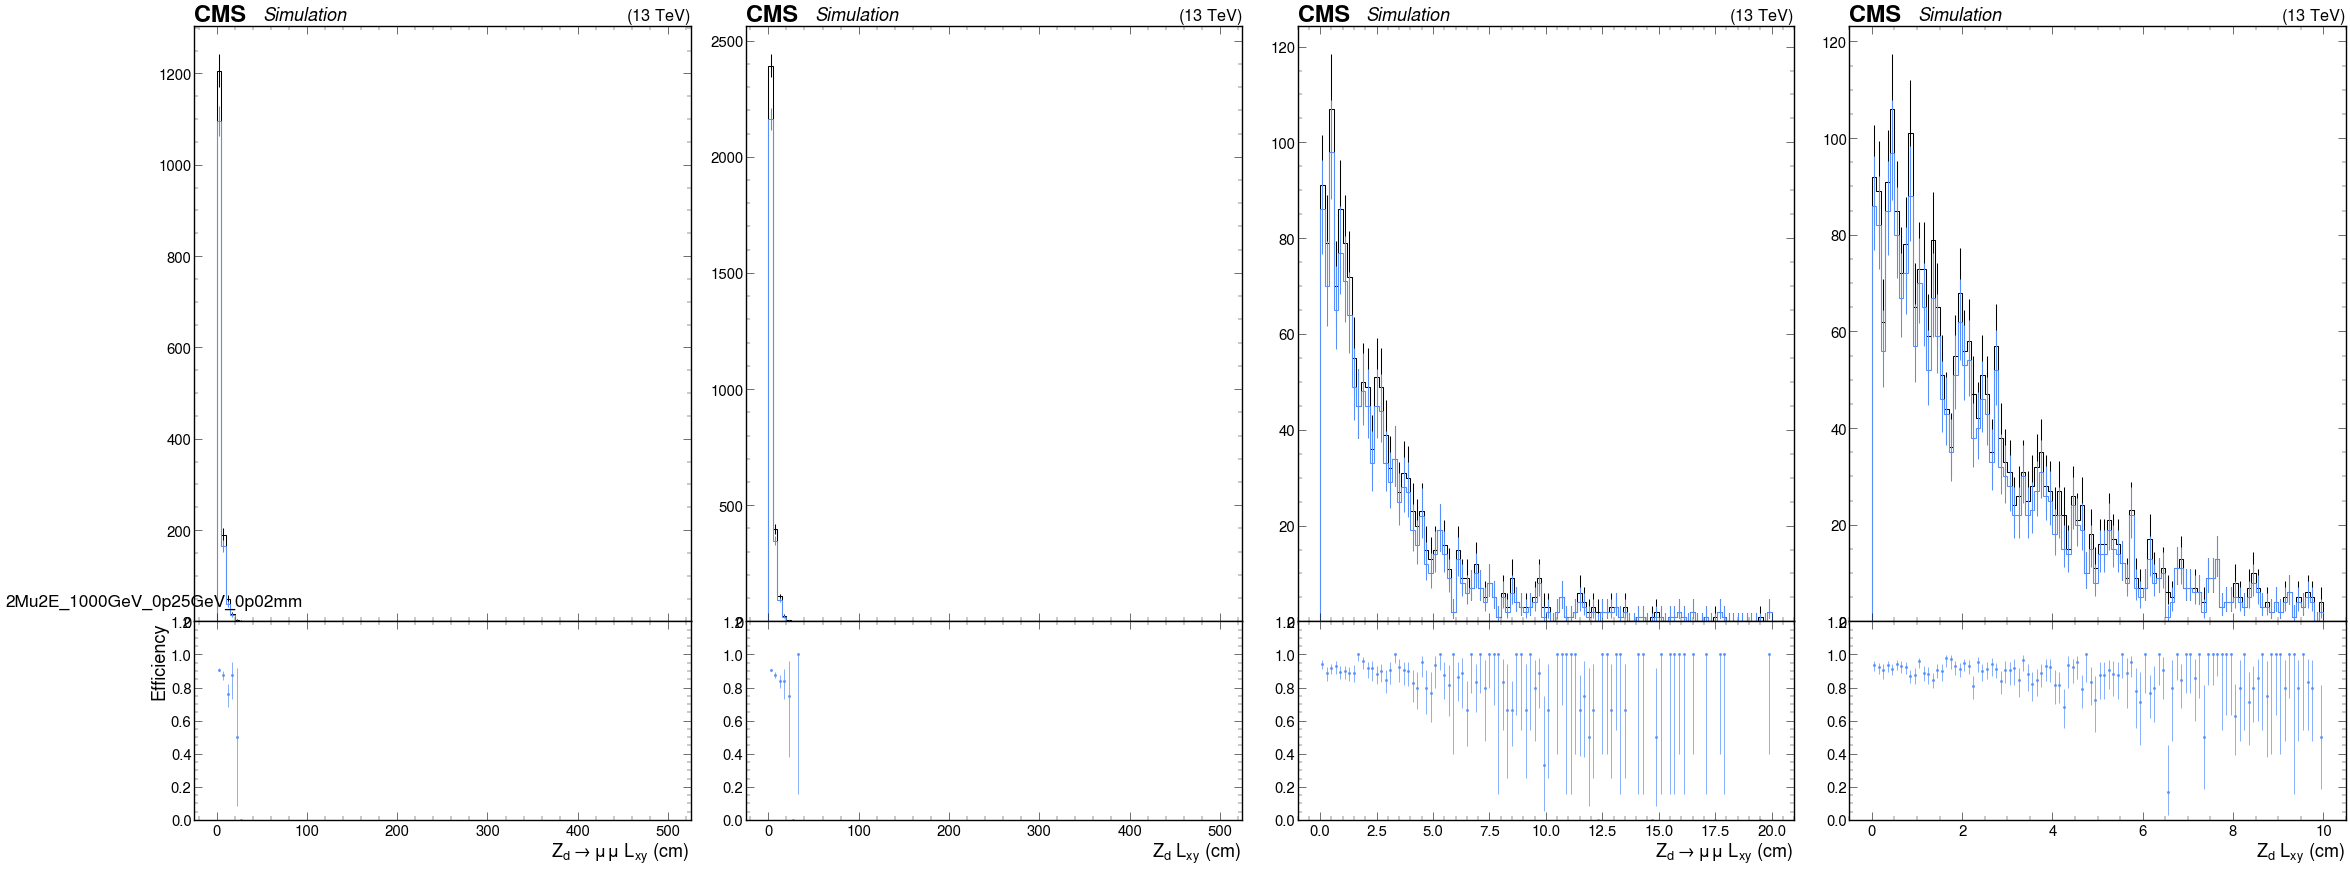

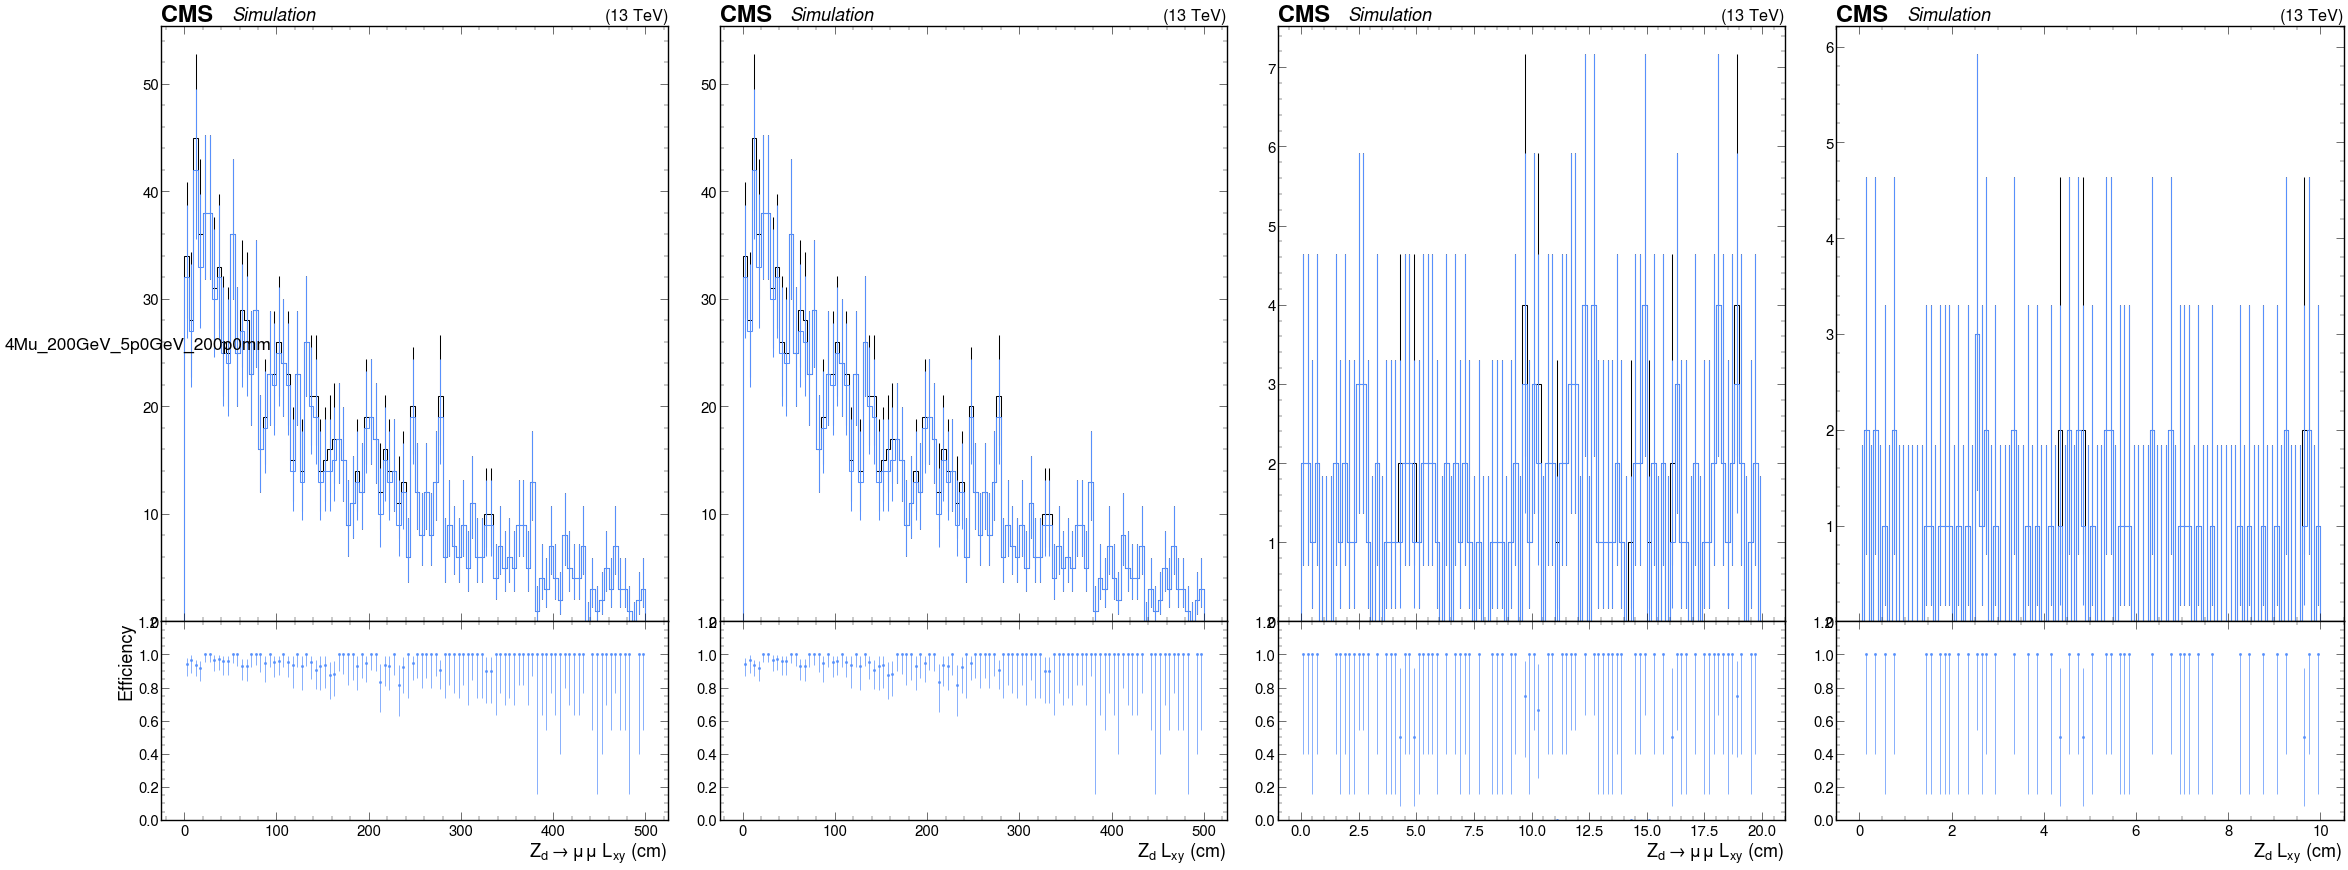

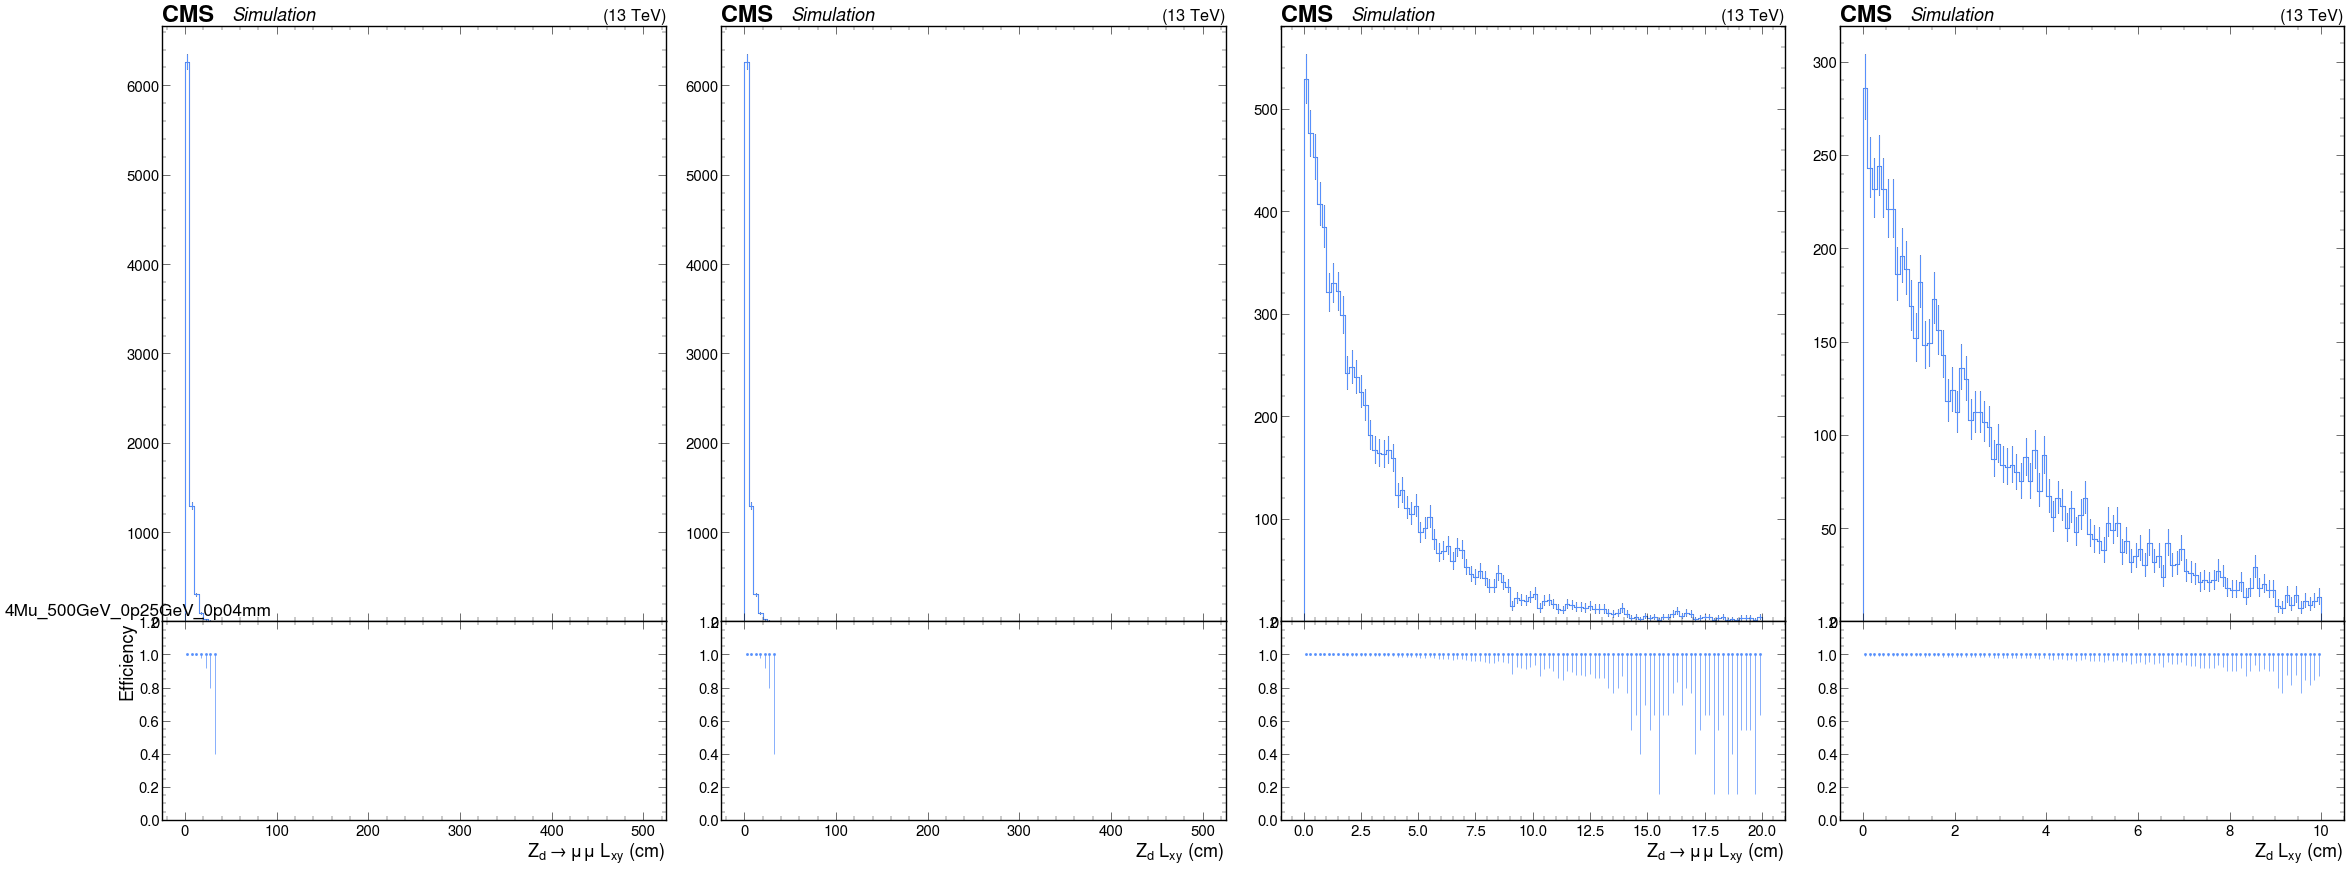

In [12]:
num_ch = "base"
denom_ch = "base_noMuPtCut"
plot_names = ["genAs_toMu_lxy","genAs_lxy","genAs_toMu_lxy_lowRange","genAs_lxy_lowRange" ]
for sample in samples:
    nums = [out[sample]["hists"][plot_name][ num_ch, :] for plot_name in plot_names]
    denoms = [out[sample]["hists"][plot_name][ denom_ch, :] for plot_name in plot_names]

    plot_ratio_row(nums,denoms,sample)

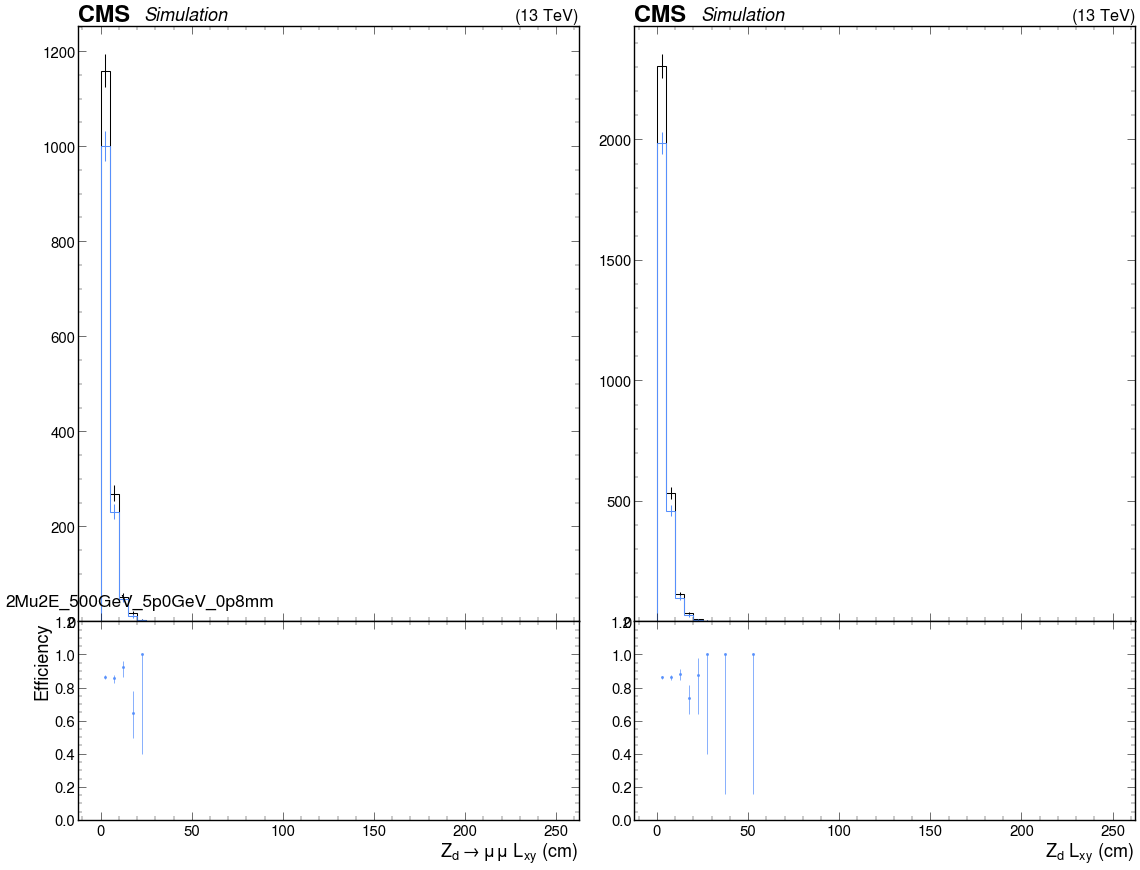

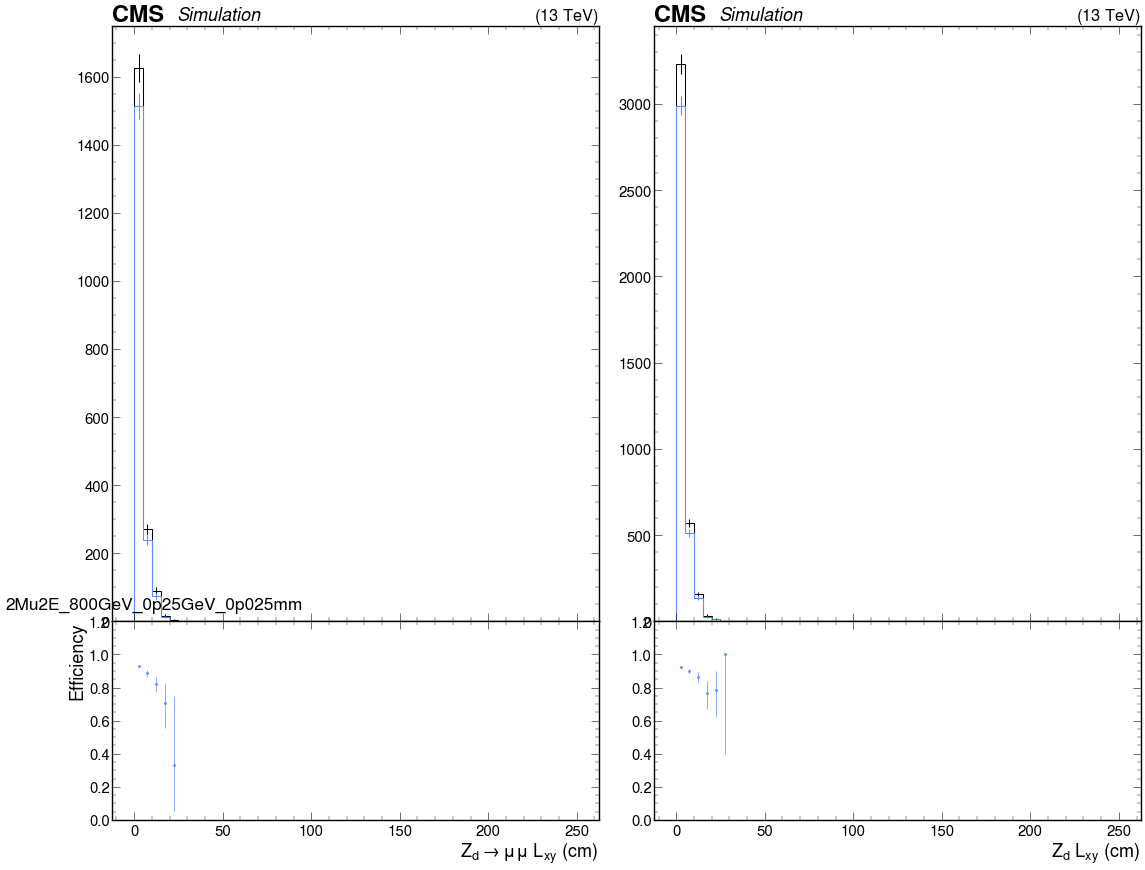

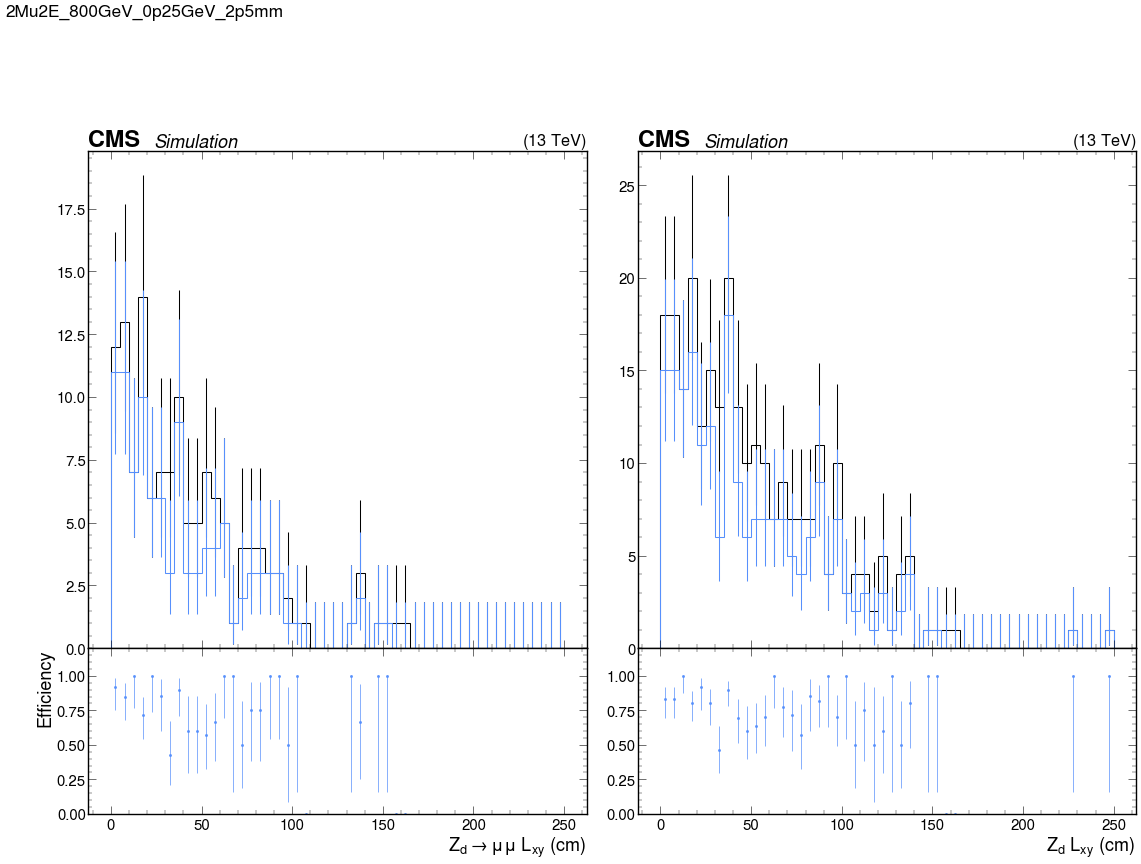

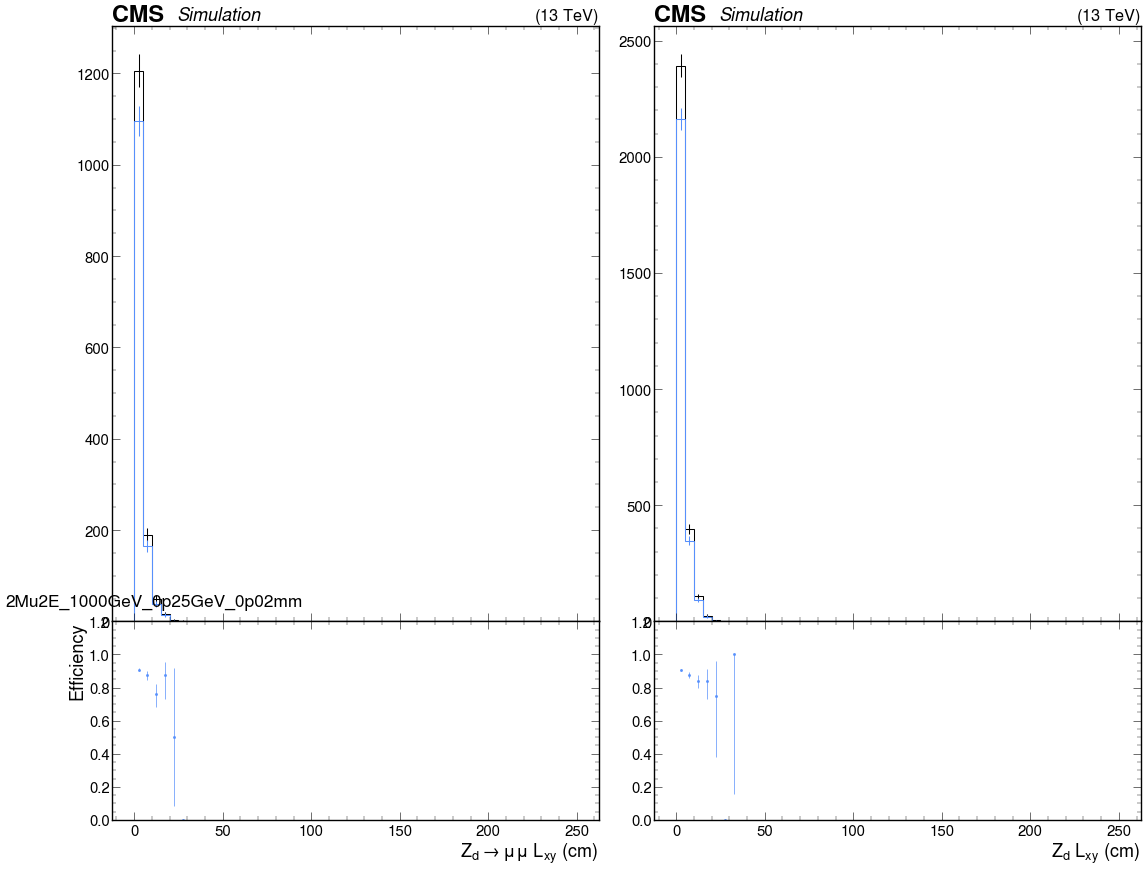

In [13]:
num_ch = "base"
denom_ch = "base_noMuPtCut"
plot_names = ["genAs_toMu_lxy","genAs_lxy" ]
sample2 = [    '2Mu2E_500GeV_5p0GeV_0p8mm',
    '2Mu2E_800GeV_0p25GeV_0p025mm',
    '2Mu2E_800GeV_0p25GeV_2p5mm',
    '2Mu2E_1000GeV_0p25GeV_0p02mm']
for sample in sample2:
    nums = [out[sample]["hists"][plot_name][ num_ch, :50] for plot_name in plot_names]
    denoms = [out[sample]["hists"][plot_name][ denom_ch, :50] for plot_name in plot_names]

    plot_ratio_row(nums,denoms,sample)

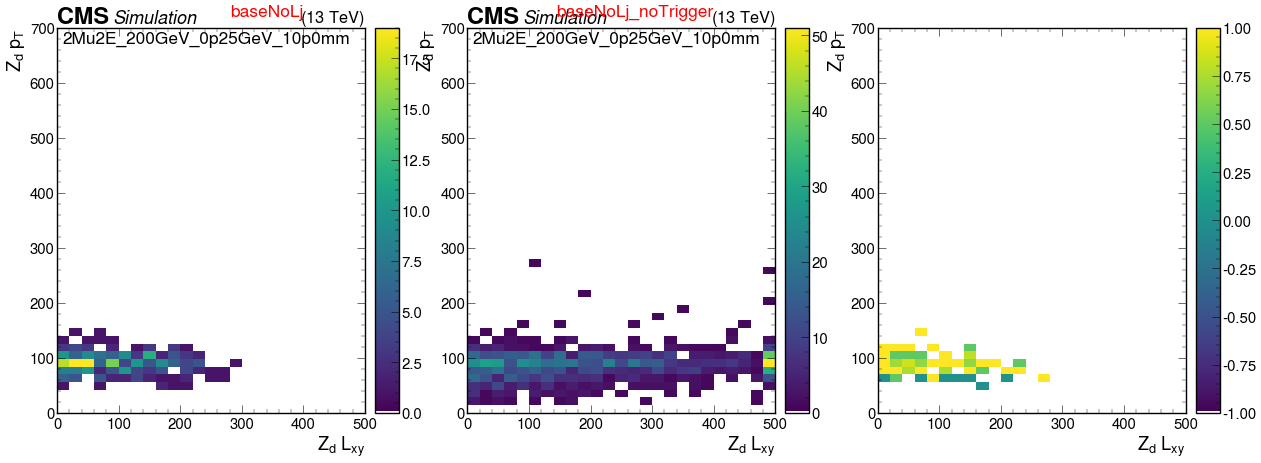

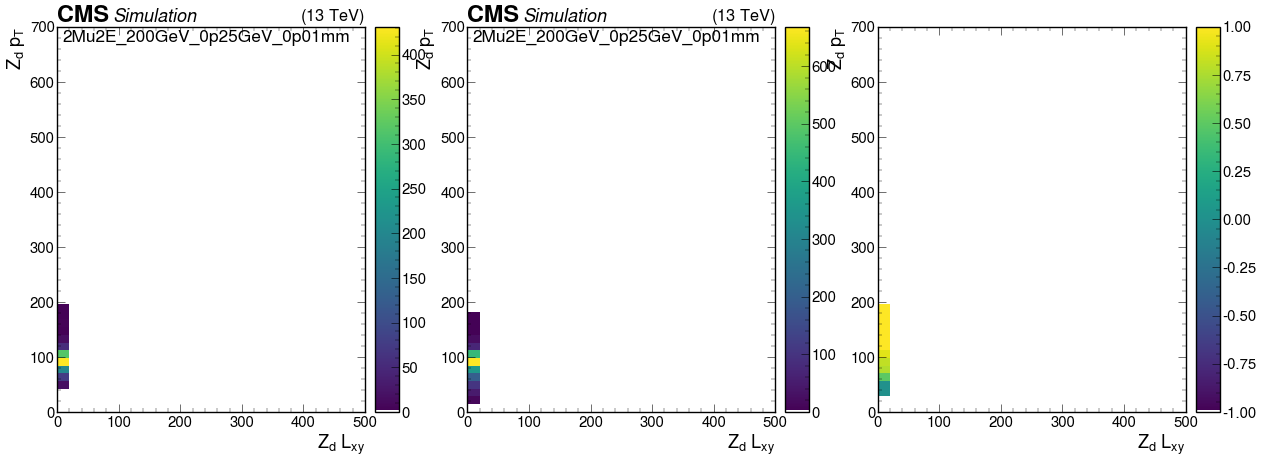

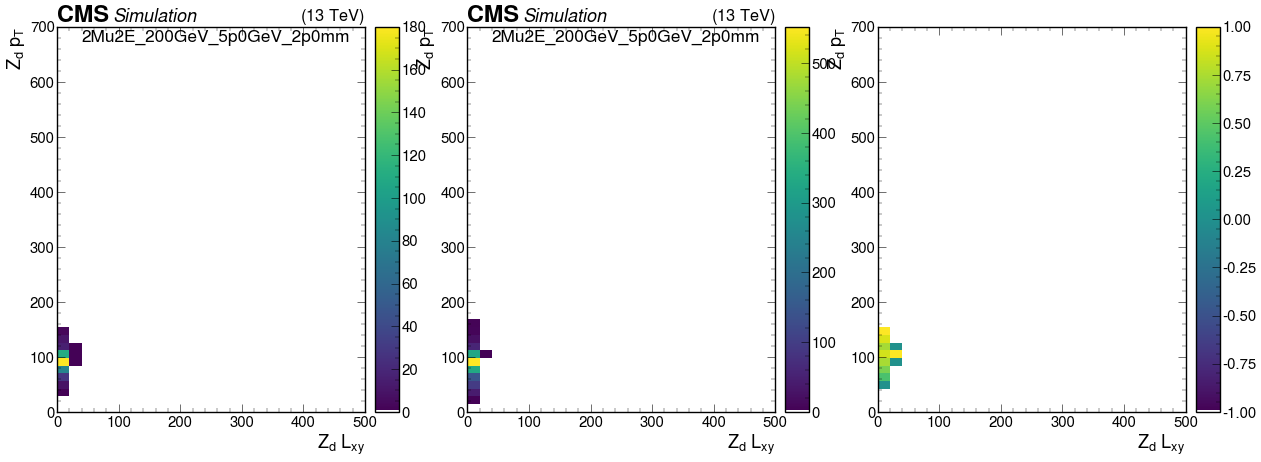

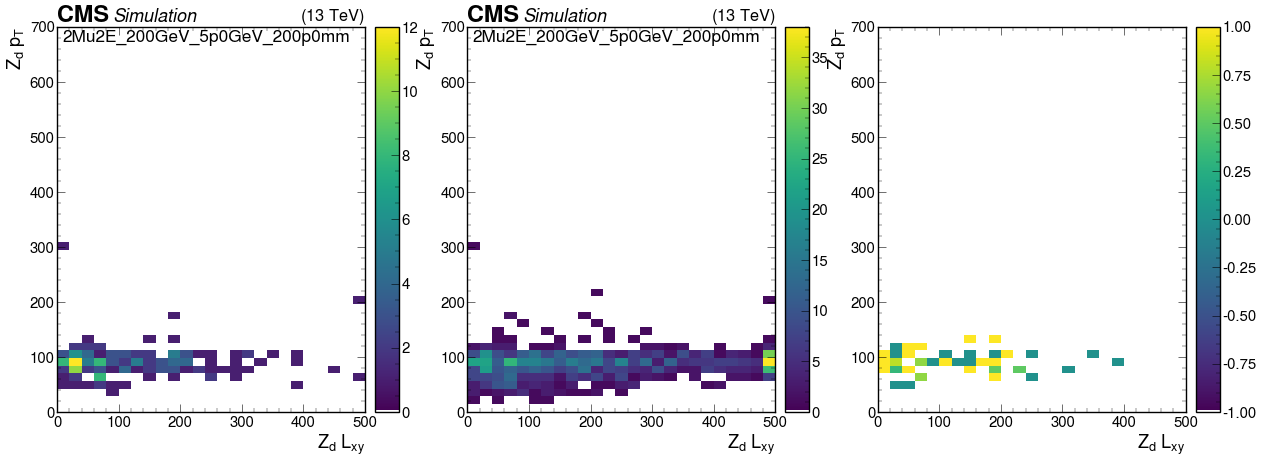

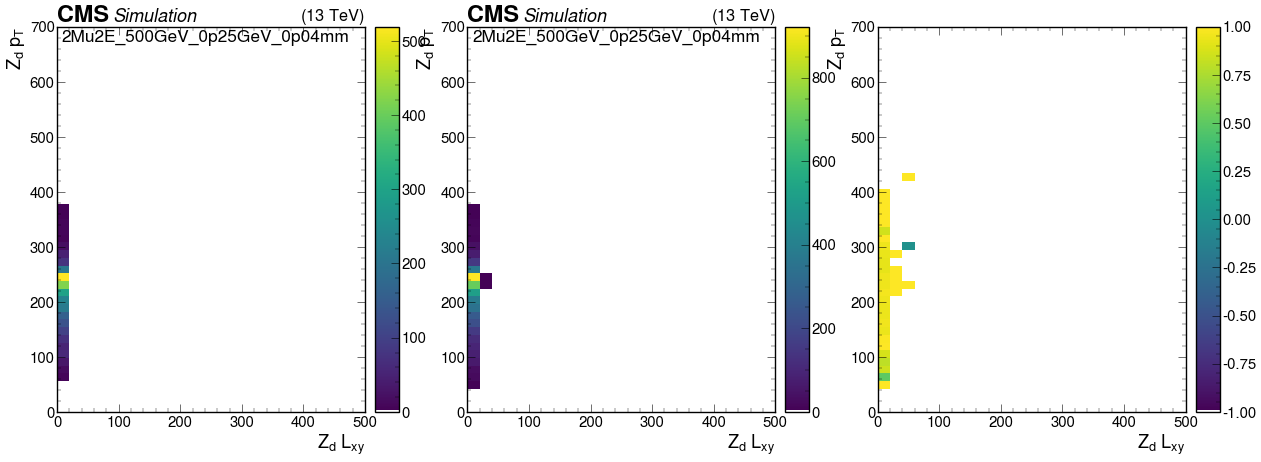

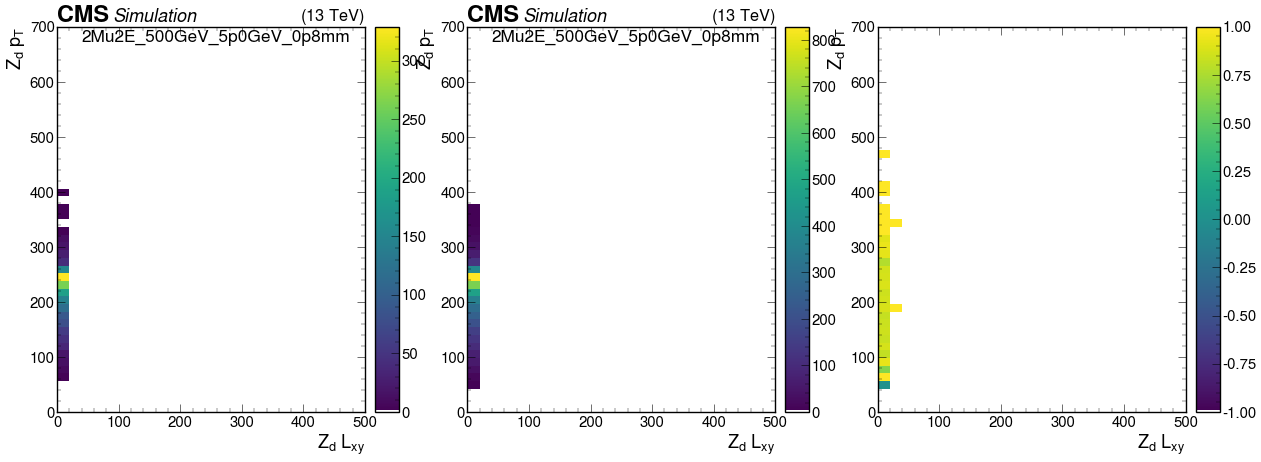

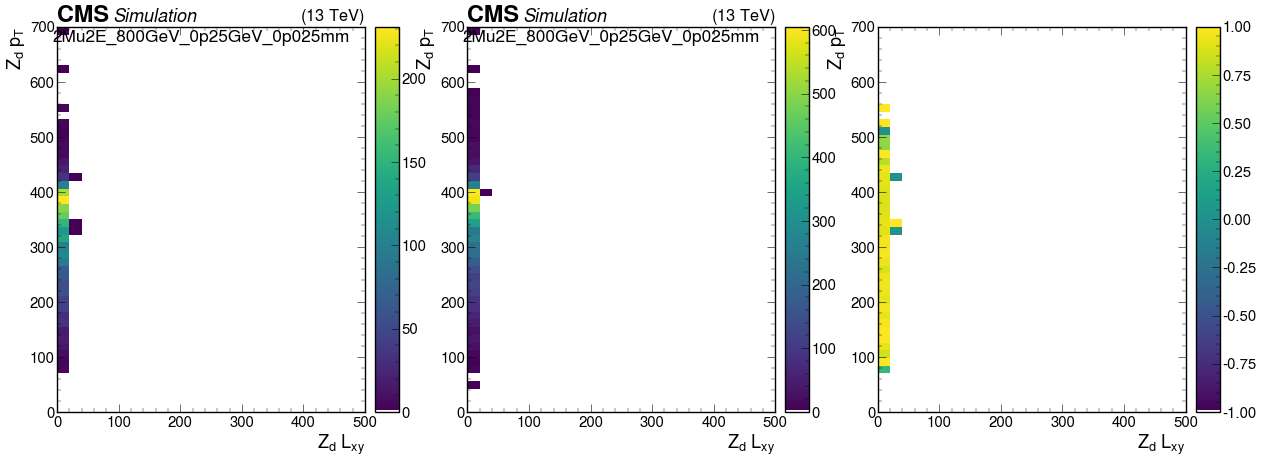

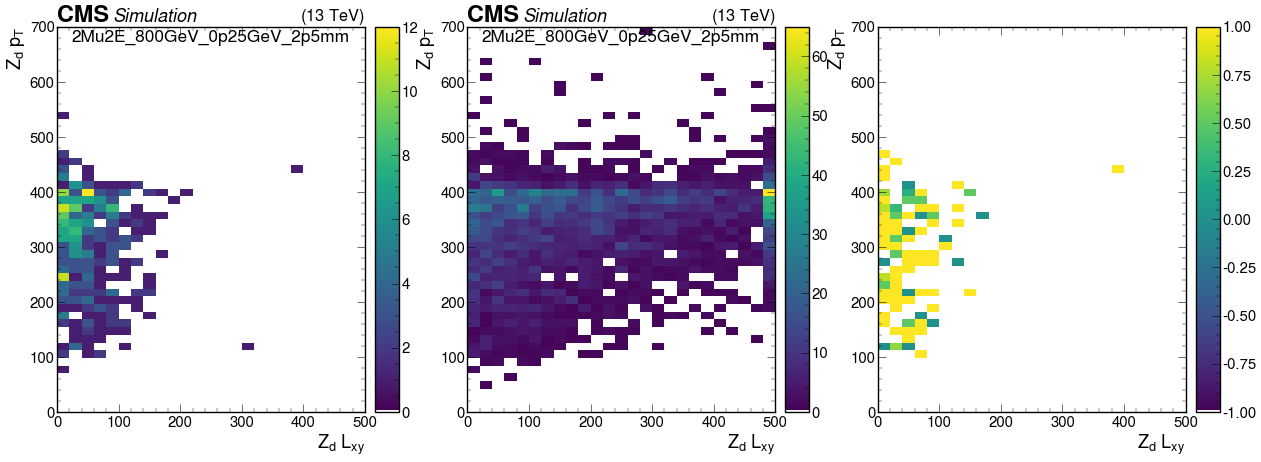

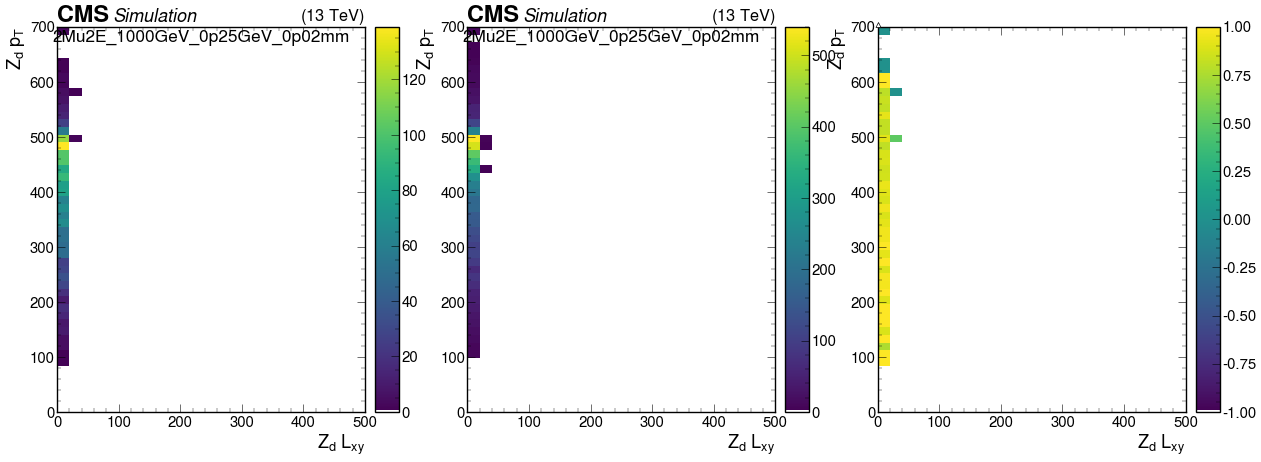

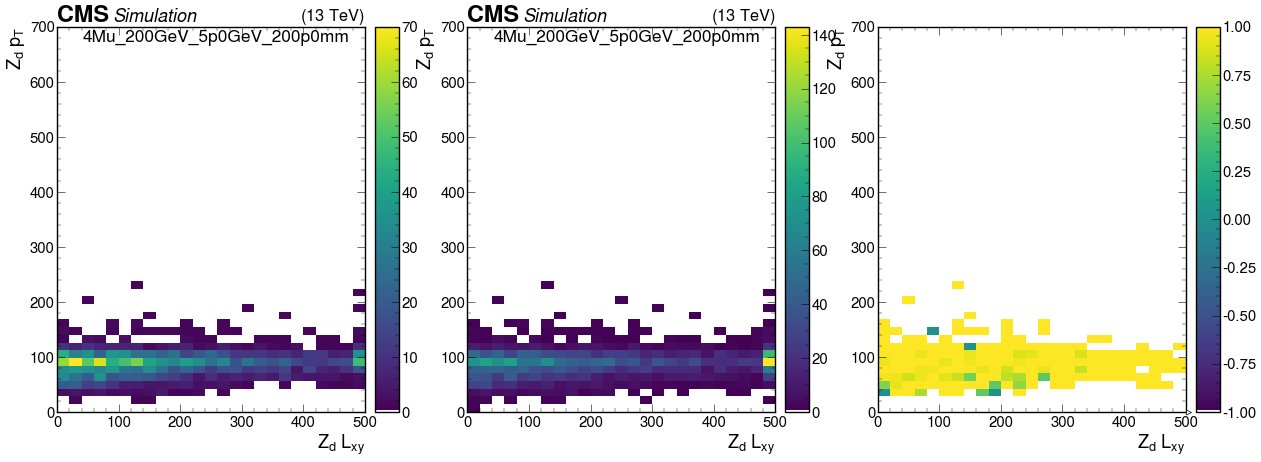

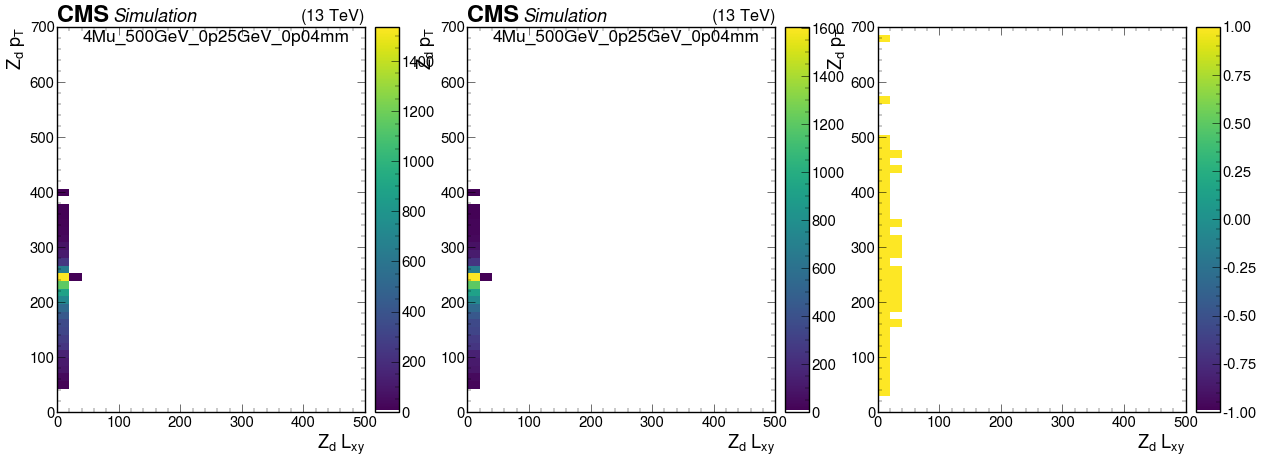

In [14]:
#Define custom color map
base_cmap = plt.get_cmap("viridis")
cmap_colors = base_cmap(np.linspace(0, 1, 256))

# Force the very bottom of the scale to pure white (RGBA)
cmap_colors[0] = [1.0, 1.0, 1.0, 1.0]
custom_cmap = mcolors.ListedColormap(cmap_colors)

#Define grid
ns = len(samples)
nc = 2 #len(channels)

first = True

num_ch = "base"
denom_ch = "base_noMuPtCut"

plot_name = "genAs_toMu_pt_lxy"

#Plot one row at a time (to avoid weird scaling effects)
for sample in samples:
    fig, axes = plt.subplots(1, nc+1, figsize=(nc * 15, 10)) 

    for i, ch in enumerate(channels):
        if i < nc:
        #plt.subplot(1, nc+1, i+1)
        
        #utilities.plot(out[sample]["hists"][plot_name][ch, :,:],cmap=custom_cmap)

        #ax = axes[i]

            ax = axes[i]
            utilities.plot(out[sample]["hists"][plot_name][ch, :,:], cmap=custom_cmap, ax=ax)
    
            ax.text(0.95, 0.95, sample, 
                    transform=ax.transAxes, 
                    fontsize=25, 
                    color='black',
                    ha='right', 
                    va='bottom')
            if first:
                ax.text(0.8, 1.02, ch, 
                    transform=ax.transAxes, 
                    fontsize=25, 
                    color='red',
                    ha='right', 
                    va='bottom')
    #i=i+1
    #plt.subplot(1, nc+1, i+1)
    ax_ratio = axes[nc]

    num  =  out[sample]["hists"][plot_name][num_ch,   :,:]
    denom = out[sample]["hists"][plot_name][denom_ch, :,:]

    ratio = num.copy()
    ratio.view().value = np.divide(num.values(), denom.values(), out=-1*np.ones_like(num.values()), where=denom.values()!=0)
    ratio.view().value[ratio.values() > 1.0] = np.nan

    ratio.plot2d(cmap=custom_cmap, ax=ax_ratio)
    
    #ratio.plot2d(cmap=custom_cmap)
    #utilities.plot(ratio,cmap=custom_cmap)
    #ax = plt.gca()
    #ax_ratio.set_xlim([0,98])
    #ax_ratio.set_ylim([0,98])

    first = False
        
    plt.show()

# Let's see if we can quantify what's happening in the 4mu case

First run over more samples.

I defined a moun pt "score" per lepton jet. The score is 1.5 if both muons satisfy pt > 26 GeV, 1 if only the leading muon satisfies it, and 0 if no muons satisfy the pt cut. Then we can look at the score sum for the two lepton jets to quantify what is happening. 

In [15]:
samples_4mu = [
    '4Mu_100GeV_0p25GeV_0p02mm',
    '4Mu_200GeV_0p25GeV_0p01mm',
     '4Mu_200GeV_0p25GeV_10p0mm',
    '4Mu_200GeV_5p0GeV_2p0mm',    
    '4Mu_200GeV_5p0GeV_200p0mm',
    '4Mu_500GeV_0p25GeV_0p004mm'
]
fileset_4mu = utilities.make_fileset(samples_4mu, "llpNanoAOD_v2", max_files=1, location_cfg="signal_4mu_v10.yaml", replace_xcache=running_on_swan)

samples = samples_4mu
fileset = fileset_4mu

In [16]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.FuturesExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    maxchunks=1,
    skipbadfiles=True
)

channels = [
    "baseNoLj",
    "baseNoLj_noTrigger",
    "base_noMuPtCut",
    "base",
]
p = sidm_processor.SidmProcessor(
    channels,
    ["lj_base","mu_lj_base", "trig_base","genMu_base","genA_toMu_base","genA_base"],
    #verbose=True,
    unweighted_hist=True,
)

output2 = runner.run(fileset, treename='Events', processor_instance=p)
out2 = output2["out"]

/home/sabbott/SIDM_env/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/sabbott/SIDM_env/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: 
Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/home/sabbott/SIDM_env/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: 
Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: a histogram with the name genAs_toMu_pt_MuMudR_lowRange could not be filled and will be skipped

...

Warning: a histogram with the name genAs_toMu_lxy_MuMudR_XLowRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_lxy_MuMudR_XXLowRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_pt_MuMudR_highRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_pt_highRange_MuMudR_lowRange could not be filled and will be skipped

4Mu_500GeV_0p25GeV_0p004mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_200GeV_5p0GeV_200p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_200GeV_5p0GeV_2p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_200GeV_0p25GeV_10p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_200GeV_0p25GeV_0p01mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_100GeV_0p25GeV_0p02mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


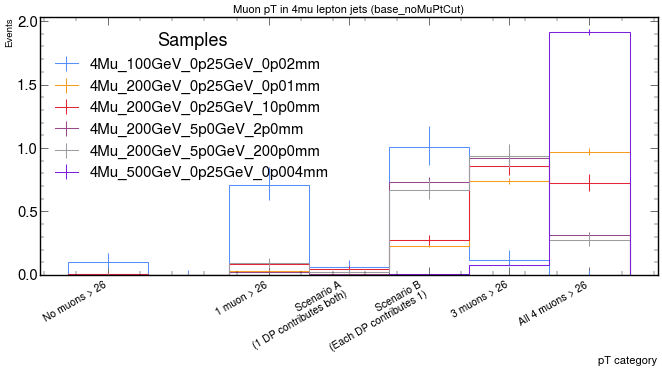

In [17]:
import matplotlib.pyplot as plt
import mplhep as hep

# Define your target channel and histogram
channel = "base_noMuPtCut"  
hist_name = "mu_lj_sum_pt_score"

# Initialize the plot
fig, ax = plt.subplots(figsize=(14, 8))


# Loop through and overlay each sample
for sample in samples_4mu:
    # Extract the 1D histogram. Adjust the dictionary indexing if your framework uses a different key structure!
    h1d = out2[sample]["hists"][hist_name][channel, :]
    
    # Plot using mplhep (flow="none" prevents the under/overflow bins from displaying)
    hep.histplot(h1d, ax=ax, label=sample, flow="none",density=True)

# --- Custom X-Axis Formatting ---

# The bin edges are [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
# Therefore, the bin centers are [0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25]
# Note: 0.75 is skipped because a score of 0.5 is mathematically impossible in your setup!
tick_positions = [0.25, 1.25, 1.75, 2.25, 2.75, 3.25]

tick_labels = [
    "No muons > 26",
    "1 muon > 26",
    "Scenario A\n(1 DP contributes both)",
    "Scenario B\n(Each DP contributes 1)",
    "3 muons > 26",
    "All 4 muons > 26"
]

# Apply the custom ticks and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=15)

# Add standard styling
ax.set_xlabel("pT category", fontsize=16)
ax.set_ylabel("Events", fontsize=14)
ax.set_title(f"Muon pT in 4mu lepton jets ({channel})", fontsize=16)
ax.legend(title="Samples")

# Adjust layout so the angled labels don't get cut off
plt.tight_layout()
plt.show()

Conclusions: 
- In most cases, either we have 3 or 4 muons satisfying the pt cut.
- If we only have 2 muons, it’s almost always one muon from each dark photon
- The displacement doesn't really change these conclusions

# Explore effect on data
One proposal for a simple skim of the data ntuples is to apply the triggers and the new two high-pt muon cut. Let's check how much that would reduce the number of events.

In [18]:
# python
import sys
import importlib
# columnar analysis
from coffea import processor
# local
from sidm.tools import sidm_processor, llpnanoaodschema, utilities
importlib.reload(sidm_processor)
importlib.reload(llpnanoaodschema)
importlib.reload(utilities)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()

In [19]:
samples = ["DoubleMuon_2018C"]

fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1, location_cfg="data.yaml", replace_xcache=running_on_swan)

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    maxchunks=1,
    skipbadfiles=True,
    chunksize=10_000,
)

channels = [
    "base", "2mu2e","trigger_muPtCut", "trigger_muPtCut_muID"
]
p = sidm_processor.SidmProcessor(
    channels,
    ["base"],
    verbose=False,
)

output = runner.run(fileset, treename='Events', processor_instance=p)
out = output["out"]

/home/sabbott/SIDM_env/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/sabbott/SIDM_env/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: 
Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/home/sabbott/SIDM_env/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: 
Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

Warning: weight not found in this sample. Skipping.

Warning: gens not found in this sample. Skipping.

...

Warning: cannot fill counter Gen As to muons. Skipping.

Warning: cannot fill counter Gen As to electrons. Skipping.

Warning: cannot fill counter Matched gen As to muons. Skipping.

Warning: cannot fill counter Matched gen As to electrons. Skipping.

DoubleMuon_2018C is data. Not scaling histograms or cutflows.


In [20]:
for channel in channels:
    print(channel)
    out[samples[0]]["cutflow"][channel].print_table()
    print()

base
cut name                             raw N    weighted N    weighted %
---------------------------------  -------  ------------  ------------
None                               10982.0       10982.0         100.0
pass triggers                       3078.0        3078.0          28.0
PV filter                           3076.0        3076.0          28.0
>=2 LJs                             1195.0        1195.0          10.9
>=2 muons (pf or dsa) pT > 26 GeV   1186.0        1186.0          10.8

2mu2e
cut name                             raw N    weighted N    weighted %
---------------------------------  -------  ------------  ------------
None                               10982.0       10982.0         100.0
pass triggers                       3078.0        3078.0          28.0
PV filter                           3076.0        3076.0          28.0
>=2 LJs                             1195.0        1195.0          10.9
>=2 muons (pf or dsa) pT > 26 GeV   1186.0        1186.0         